<a href="https://colab.research.google.com/github/Knerdy-got-moves/Many-body-dynamics-in-Floquet-driven-systems/blob/main/Entanglement_entropy/OBC_Optimised_entanglement_entropy_in_large_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model: Kicked transverse field Ising model under periodic boundary conditions


Consider a transverse-field Ising chain of length $L$ with periodic boundary conditions (PBC), Pauli operators $\sigma_i^{x,y,z}$, and a weak transverse perturbation:
$$
H(t)=H_0(t)+H_1,
\qquad
H_0(t)=-J(t)\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z-h(t)\sum_{i=1}^{L}\sigma_i^z,
\qquad
H_1=-g\sum_{i=1}^{L}\sigma_i^x,\;\; |g|\ll \{|J_0|,|h_0|\},
$$
with periodic identification $\sigma_{L+1}^z\equiv\sigma_1^z$.
Both couplings follow the same symmetric square–wave of period $T$:
$$
J(t)=
\begin{cases}
+J_0,& 0\le t\le T/2,\\
-J_0,& T/2<t\le T,
\end{cases}
\qquad
h(t)=
\begin{cases}
+h_0,& 0\le t\le T/2,\\
-h_0,& T/2<t\le T.
\end{cases}
$$

For a Floquet period-$n$ state,
$$
|\psi(nT)\rangle = U_F^{\,n}\,|\psi(0)\rangle,
\qquad
U_F = e^{-i H_{+}\, T/2}\, e^{-i H_{-}\, T/2},
$$
where $H_{\pm}$ denote $H(t)$ with $(J,h)=(\pm J_0,\pm h_0)$ on the corresponding half-period.

Bipartition the ring into a contiguous block (A) of size $L_A$ and its complement (B) of size $L_B=L-L_A$.
The reduced density matrix of (A) at stroboscopic time $t=nT$ is
$$
\rho_A(nT)=\mathrm{Tr}_B\!\left[\,|\psi(nT)\rangle\langle\psi(nT)|\,\right],
$$
and the von Neumann entanglement entropy is
$$
S_A(nT)=-\mathrm{Tr}\!\big[\rho_A(nT)\,\ln\rho_A(nT)\big].
$$
With the Schmidt decomposition across the cut,
$$
|\psi(nT)\rangle=\sum_k s_k(nT)\,|k_A\rangle\otimes|k_B\rangle,
\qquad
p_k(nT)=\big(s_k(nT)\big)^2,
$$
the same entropy is
$$
S_A(nT)=-\sum_k p_k(nT)\,\ln p_k(nT).
$$

For the Page value at a half-chain cut, let
$$
L_A=\Big\lfloor \frac{L}{2}\Big\rfloor,\quad
L_B=L-L_A,\qquad
m=2^{L_A},\quad n=2^{L_B}.
$$
Then the average (Page) entanglement entropy is approximately
$$
S_{\text{Page}}\simeq \ln m-\frac{m}{2n}
= L_A\ln 2 - 2^{\,2L_A-L-1}.
$$
We plot the ratio
$$
\frac{S_A(nT)}{S_{\text{Page}}}\,.
$$



# Numerical Hamiltonian, Floquet unitary, Bipartite entanglement entropy

Here we define the couplings $J_0$, $h_0$ and the time period, $TP$. We compute the entanglement entropy for a random state and show that it saturates below the Eigenstate Thermalisation Hypothesis (ETH) value predicted vlaue, the Page value.

References for ETH:
1.   J. M. Deutsch, "Quantum statistical mechanics in a closed system," Phys. Rev. A 43, 2046-2049 (1991). doi: [10.1103/PhysRevA.43.2046](https://link.aps.org/doi/10.1103/PhysRevA.43.2046​).
2.   Mark Srednicki, "Chaos and quantum thermalization," Phys. Rev. E 50, 888-901 (1994). doi: [10.1103/PhysRevE.50.888](https://link.aps.org/doi/10.1103/PhysRevE.50.888​).
3.   Luca D'Alessio et al., "From quantum chaos and eigenstate thermalization to statistical mechanics and thermodynamics," Adv. Phys. 65, 239-362 (2016). doi: [10.1080/00018732.2016.1198134](https://doi.org/10.1080/00018732.2016.1198134).

References for Page value:


1.   Don N. Page, "Average entropy of a subsystem," Phys. Rev. Lett. 71, 1291-1294 (1993). doi: [10.1103/PhysRevLett.71.1291](https://doi.org/10.1103/PhysRevLett.71.1291).
2.   S. K. Foong and S. Kanno, "Proof of Page's conjecture on the average entropy of a subsystem," Phys. Rev. Lett. 72, 1148-1151 (1994). doi: [10.1103/PhysRevLett.72.1148](https://doi.org/10.1103/PhysRevLett.72.1148).
3.   L. Vidmar and M. Rigol, "Entanglement Entropy of Eigenstates of Quantum Chaotic Hamiltonians," Phys. Rev. Lett. 119, 220603 (2017). doi: [10.1103/PhysRevLett.119.220603](https://doi.org/10.1103/PhysRevLett.119.220603).











In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator


# ============================================================
# STANDALONE SPARSE HAMILTONIAN BUILDER — OPEN BC
# ============================================================

def build_H_floquet_obc(L, J0, h0, g, which):
    """
    Construct a Floquet half-period Hamiltonian for the **open** Ising chain.

    H_+ = -J0 Σ_{i=0}^{L-2} σ^z_i σ^z_{i+1}  - h0 Σ σ^z_i  - g Σ σ^x_i
    H_- = +J0 Σ_{i=0}^{L-2} σ^z_i σ^z_{i+1}  + h0 Σ σ^z_i  - g Σ σ^x_i

    Parameters
    ----------
    L : int
        Chain length (number of sites).  Must be >= 2.
    J0 : float
        Ising nearest-neighbour coupling amplitude.
    h0 : float
        Longitudinal field amplitude.
    g : float
        Transverse field strength.
    which : {"plus", "minus"}
        Selects the half-period Hamiltonian.

    Returns
    -------
    H : scipy.sparse.csr_matrix, shape (N, N), dtype np.float64
        The Hamiltonian in CSR canonical form.
        Each row has exactly (L + 1) stored entries
        (1 diagonal + L off-diagonal sigma^x flips).
        Total nnz = N * (L + 1), where N = 2^L.

    Notes
    -----
    OBC has L-1 ZZ bonds: i = 0, 1, ..., L-2.
    No wrap-around bond (site L-1, site 0).
    In bit arithmetic:
        site i   → bit position (L - 1 - i)
        site i+1 → bit position (L - 2 - i)
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")
    if which not in ("plus", "minus"):
        raise ValueError(f"which must be 'plus' or 'minus', got '{which}'")

    N = 1 << L

    if which == "plus":
        signJ, signh = -1.0, -1.0
    else:
        signJ, signh = +1.0, +1.0

    states = np.arange(N, dtype=np.int64)

    # ---- Diagonal: ZZ (OBC: L-1 bonds) + Z contributions ----
    diag = np.zeros(N, dtype=np.float64)

    # ZZ interaction: L-1 bonds, NO wrap-around
    coeff_zz = signJ * J0
    for i in range(L - 1):                          # <--- KEY CHANGE: L → L-1
        pi  = L - 1 - i                             # bit position of site i
        pi1 = L - 1 - (i + 1)                       # bit position of site i+1
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += coeff_zz * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms (same as PBC)
    coeff_z = signh * h0
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag += coeff_z * (1.0 - 2.0 * ci.astype(np.float64))

    # ---- Off-diagonal: σ^x flips (identical to PBC) ----
    all_cols = np.empty((N, L + 1), dtype=np.int64)
    all_vals = np.empty((N, L + 1), dtype=np.float64)

    # Column 0 = diagonal
    all_cols[:, 0] = states
    all_vals[:, 0] = diag

    # Columns 1..L = σ^x bit-flips at each site
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        all_cols[:, 1 + i] = states ^ flip_mask
        all_vals[:, 1 + i] = -g

    # ---- Sort columns within each row (CSR canonical form) ----
    sort_idx = np.argsort(all_cols, axis=1, kind='stable')
    all_cols = np.take_along_axis(all_cols, sort_idx, axis=1)
    all_vals = np.take_along_axis(all_vals, sort_idx, axis=1)

    # ---- Assemble CSR matrix ----
    indptr  = np.arange(N + 1, dtype=np.int64) * (L + 1)
    indices = all_cols.ravel()
    data    = all_vals.ravel()

    H = csr_matrix((data, indices, indptr), shape=(N, N))
    H.has_sorted_indices = True

    return H


# ============================================================
# LIGHTWEIGHT BASIS DESCRIPTOR
# ============================================================

class _BasisInfo:
    """
    Drop-in for QuSpin's spin_basis_1d, exposing .Ns and .states.
    """
    __slots__ = ('L', 'Ns', 'states')

    def __init__(self, L):
        self.L = L
        self.Ns = 1 << L
        self.states = np.arange(1 << L, dtype=np.int64)

    def __repr__(self):
        return f"_BasisInfo(L={self.L}, Ns={self.Ns})"


# ============================================================
# OOP INTERFACE — OPEN BC
# ============================================================

class FloquetIsingChain:
    """
    Floquet-driven Ising chain with **open** boundary conditions.

    After calling build_hamiltonians(), the following are available:
        .H_plus_sparse   : csr_matrix  — H_+ (first half-period)
        .H_minus_sparse  : csr_matrix  — H_- (second half-period)
        .A_plus          : csr_matrix  — -i * H_+ * T/(2*hbar), complex128
        .A_minus         : csr_matrix  — -i * H_- * T/(2*hbar), complex128

    The cached A_plus / A_minus are the generators for expm_multiply:
        exp(A_plus) |ψ⟩ = exp(-i H_+ T/(2ℏ)) |ψ⟩
    """

    def __init__(self, L=8, J_0=4.0, h_0=8.0, g=1.0, TP=np.pi/4.0, hbar=1.0):
        self.L = L
        self.J_0 = J_0
        self.h_0 = h_0
        self.g = g
        self.hbar = hbar
        self.T = TP

        self.Ns = 1 << L
        self.basis = _BasisInfo(L)

        # Built on demand
        self._H_plus_sparse = None
        self._H_minus_sparse = None
        self._A_plus = None
        self._A_minus = None

        # Adaptive subdivision for Krylov (set in build_hamiltonians)
        self._A_plus_norm1 = None
        self._A_minus_norm1 = None
        self._K_plus = 1
        self._K_minus = 1
        self._A_plus_sub = None
        self._A_minus_sub = None

        print(f"System Parameters (OPEN BC):")
        print(f"  Chain length L = {self.L}")
        print(f"  J_0 = {self.J_0}")
        print(f"  h_0 = {self.h_0}")
        print(f"  g = {self.g}")
        print(f"  Period T = {self.T:.6f}")
        print(f"  Hilbert space dimension = {self.Ns}")

    # --------------------------------------------------------
    # Hamiltonian construction
    # --------------------------------------------------------

    def build_hamiltonians(self):
        """
        Build H_+ and H_- (OBC) and cache Krylov generators A_±.

        Returns
        -------
        H_plus_sparse  : csr_matrix, shape (Ns, Ns), float64
        H_minus_sparse : csr_matrix, shape (Ns, Ns), float64
        """
        self._H_plus_sparse = build_H_floquet_obc(
            self.L, self.J_0, self.h_0, self.g, "plus"
        )
        self._H_minus_sparse = build_H_floquet_obc(
            self.L, self.J_0, self.h_0, self.g, "minus"
        )

        # --- Cache Krylov generators: A = -i * H * T/(2*hbar) ---
        scale = -1j * self.T / (2.0 * self.hbar)
        self._A_plus  = (scale * self._H_plus_sparse).tocsr()
        self._A_minus = (scale * self._H_minus_sparse).tocsr()

        # --- Adaptive subdivision for large spectral norms ---
        from scipy.sparse.linalg import norm as sp_norm
        NORM_THRESHOLD = 5.0

        self._A_plus_norm1  = sp_norm(self._A_plus, ord=1)
        self._A_minus_norm1 = sp_norm(self._A_minus, ord=1)

        self._K_plus  = max(1, int(np.ceil(self._A_plus_norm1 / NORM_THRESHOLD)))
        self._K_minus = max(1, int(np.ceil(self._A_minus_norm1 / NORM_THRESHOLD)))

        if self._K_plus == 1:
            self._A_plus_sub = self._A_plus
        else:
            self._A_plus_sub = (self._A_plus / self._K_plus).tocsr()

        if self._K_minus == 1:
            self._A_minus_sub = self._A_minus
        else:
            self._A_minus_sub = (self._A_minus / self._K_minus).tocsr()

        # --- Validation ---
        assert self._H_plus_sparse.shape == (self.Ns, self.Ns)
        assert self._H_minus_sparse.shape == (self.Ns, self.Ns)

        nnz_expected = self.Ns * (self.L + 1)
        nnz_actual = self._H_plus_sparse.nnz
        assert nnz_actual == nnz_expected, \
            f"nnz mismatch: got {nnz_actual}, expected {nnz_expected}"

        density = nnz_actual / (self.Ns ** 2)

        print(f"\nHamiltonians constructed successfully (OPEN BC)!")
        print(f"  H+ shape: {self._H_plus_sparse.shape}, nnz = {nnz_actual}")
        print(f"  Number of ZZ bonds: {self.L - 1} (open chain)")
        print(f"  Density: {density:.2e}")
        print(f"  Memory per H matrix: ~{self._estimate_sparse_memory():.2f} MB")
        print(f"  A_plus dtype: {self._A_plus.dtype}  (Krylov generator cached)")
        print(f"  ||A+||_1 = {self._A_plus_norm1:.2f}, "
              f"||A-||_1 = {self._A_minus_norm1:.2f}")
        print(f"  Krylov sub-steps: K+ = {self._K_plus}, K- = {self._K_minus}"
              f"{'  (no subdivision needed)' if self._K_plus == 1 and self._K_minus == 1 else ''}")

        self._verify_hermiticity()

        return self._H_plus_sparse, self._H_minus_sparse

    # --------------------------------------------------------
    # Hermiticity verification
    # --------------------------------------------------------

    def _verify_hermiticity(self, n_samples=5):
        """Verify ⟨v|H|w⟩ = ⟨w|H|v⟩* via random complex vectors."""
        if self._H_plus_sparse is None:
            return

        rng = np.random.RandomState(42)
        max_diff_p = 0.0
        max_diff_m = 0.0

        for _ in range(n_samples):
            v = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)
            w = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)

            vHw = np.vdot(v, self._H_plus_sparse @ w)
            wHv = np.vdot(w, self._H_plus_sparse @ v)
            max_diff_p = max(max_diff_p, abs(vHw - np.conj(wHv)))

            vHw = np.vdot(v, self._H_minus_sparse @ w)
            wHv = np.vdot(w, self._H_minus_sparse @ v)
            max_diff_m = max(max_diff_m, abs(vHw - np.conj(wHv)))

        print(f"  Hermiticity check (H+): max err = {max_diff_p:.2e}")
        print(f"  Hermiticity check (H-): max err = {max_diff_m:.2e}")
        assert max_diff_p < 1e-9, f"H+ hermiticity violated: {max_diff_p}"
        assert max_diff_m < 1e-9, f"H- hermiticity violated: {max_diff_m}"

    # --------------------------------------------------------
    # Memory estimation
    # --------------------------------------------------------

    def _estimate_sparse_memory(self):
        """Estimate CSR memory for one Hamiltonian in MB."""
        nnz = self.Ns * (self.L + 1)
        bytes_data    = nnz * 8
        bytes_indices = nnz * 8
        bytes_indptr  = (self.Ns + 1) * 8
        return (bytes_data + bytes_indices + bytes_indptr) / (1024 ** 2)

    # --------------------------------------------------------
    # Properties
    # --------------------------------------------------------

    @property
    def H_plus_sparse(self):
        if self._H_plus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_plus_sparse

    @property
    def H_minus_sparse(self):
        if self._H_minus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_minus_sparse

    @property
    def A_plus(self):
        if self._A_plus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus

    @property
    def A_minus(self):
        if self._A_minus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus

    @property
    def A_plus_sub(self):
        if self._A_plus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus_sub

    @property
    def A_minus_sub(self):
        if self._A_minus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus_sub

    @property
    def K_plus(self):
        return self._K_plus

    @property
    def K_minus(self):
        return self._K_minus

    # --------------------------------------------------------
    # LinearOperator fallbacks
    # --------------------------------------------------------

    def get_H_plus_linop(self):
        H = self.H_plus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,
            dtype=np.complex128
        )

    def get_H_minus_linop(self):
        H = self.H_minus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,
            dtype=np.complex128
        )


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 1: Sparse OBC Hamiltonian Builder — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Basic construction and shape
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Basic construction at L=8")
    print("-" * 72)

    L = 8
    ising = FloquetIsingChain(L=L, J_0=4.0, h_0=8.0, g=1.0,
                              TP=np.pi/4.0, hbar=1.0)
    H_plus, H_minus = ising.build_hamiltonians()

    Ns = 2**L
    assert H_plus.shape == (Ns, Ns), f"Shape mismatch: {H_plus.shape}"
    assert H_minus.shape == (Ns, Ns), f"Shape mismatch: {H_minus.shape}"
    assert H_plus.nnz == Ns * (L + 1), f"nnz mismatch: {H_plus.nnz}"
    print("  PASS: shapes and nnz correct")

    # ----------------------------------------------------------
    # TEST 2: Real symmetry (H = H^T since H is real)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Real symmetry H = H^T")
    print("-" * 72)

    for label, H in [("H+", H_plus), ("H-", H_minus)]:
        diff = (H - H.T).data
        max_asym = np.max(np.abs(diff)) if len(diff) > 0 else 0.0
        print(f"  {label}: max|H - H^T| = {max_asym:.2e}")
        assert max_asym < 1e-12, f"{label} not symmetric!"
    print("  PASS: both Hamiltonians are exactly symmetric")

    # ----------------------------------------------------------
    # TEST 3: H_+ + H_- = -2g Σ σ^x_i
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: H_+ + H_- = -2g Σ σ^x_i")
    print("-" * 72)

    H_sum = H_plus + H_minus
    H_sum_dense = H_sum.toarray()

    g_val = 1.0
    expected = np.zeros((Ns, Ns), dtype=np.float64)
    states = np.arange(Ns, dtype=np.int64)
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        for s in range(Ns):
            s_flip = int(s ^ flip_mask)
            expected[s, s_flip] += -2.0 * g_val

    max_diff = np.max(np.abs(H_sum_dense - expected))
    print(f"  max|H_+ + H_- - (-2g Σσ^x)| = {max_diff:.2e}")
    assert max_diff < 1e-12, f"H_+/H_- relationship broken: {max_diff}"
    print("  PASS: H_+ + H_- identity verified")

    # ----------------------------------------------------------
    # TEST 4: OBC — verify wrap-around bond is ABSENT
    #   Compare OBC diagonal vs PBC diagonal at L=4.
    #   PBC should have one extra ZZ bond; OBC should not.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: OBC wrap-around bond ABSENT (L=4)")
    print("-" * 72)

    L_test = 4
    J0_test, h0_test, g_test = 4.0, 8.0, 1.0
    N_test = 2**L_test
    states_test = np.arange(N_test, dtype=np.int64)

    H_obc = build_H_floquet_obc(L_test, J0_test, h0_test, g_test, "plus")
    H_obc_dense = H_obc.toarray()

    # Build OBC diagonal manually: L-1 = 3 bonds
    diag_obc_manual = np.zeros(N_test, dtype=np.float64)
    for i in range(L_test - 1):
        pi  = L_test - 1 - i
        pi1 = L_test - 1 - (i + 1)
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_obc_manual += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Add Z field
    for i in range(L_test):
        pi = L_test - 1 - i
        ci = (states_test >> pi) & 1
        diag_obc_manual += (-h0_test) * (1.0 - 2.0 * ci.astype(np.float64))

    diag_from_sparse = np.array(H_obc_dense.diagonal())
    max_diag_err = np.max(np.abs(diag_from_sparse - diag_obc_manual))
    print(f"  max|diag_sparse - diag_manual| = {max_diag_err:.2e}")
    assert max_diag_err < 1e-12, f"OBC diagonal mismatch: {max_diag_err}"

    # Now build PBC diagonal for comparison
    diag_pbc_manual = np.zeros(N_test, dtype=np.float64)
    for i in range(L_test):                         # L bonds for PBC
        pi  = L_test - 1 - i
        pi1 = L_test - 1 - ((i + 1) % L_test)
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_pbc_manual += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))
    for i in range(L_test):
        pi = L_test - 1 - i
        ci = (states_test >> pi) & 1
        diag_pbc_manual += (-h0_test) * (1.0 - 2.0 * ci.astype(np.float64))

    diff_pbc_obc = diag_pbc_manual - diag_obc_manual
    n_nonzero = np.count_nonzero(np.abs(diff_pbc_obc) > 1e-12)
    print(f"  PBC - OBC diagonal: {n_nonzero}/{N_test} entries differ "
          f"(wrap-around bond contribution)")
    assert n_nonzero > 0, "PBC and OBC diagonals identical — something is wrong"
    print("  PASS: OBC correctly omits wrap-around bond")

    # ----------------------------------------------------------
    # TEST 5: Krylov generator A = -i·H·T/(2ℏ) caching
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov generator A = -i·H·T/(2ℏ) caching")
    print("-" * 72)

    L_test = 6
    T_test = np.pi / 10.0
    hbar_test = 1.0
    ising_test = FloquetIsingChain(L=L_test, J_0=10.0, h_0=20.0, g=1.0,
                                    TP=T_test, hbar=hbar_test)
    ising_test.build_hamiltonians()

    scale = -1j * T_test / (2.0 * hbar_test)
    A_expected = (scale * ising_test.H_plus_sparse).toarray()
    A_actual = ising_test.A_plus.toarray()
    max_err = np.max(np.abs(A_actual - A_expected))
    print(f"  max|A_plus - (-i·H+·T/2)| = {max_err:.2e}")
    assert max_err < 1e-14, f"Generator caching error: {max_err}"
    assert ising_test.A_plus.dtype == np.complex128
    print(f"  A_plus dtype: {ising_test.A_plus.dtype}")
    print("  PASS: Krylov generators correctly cached")

    # ----------------------------------------------------------
    # TEST 6: Analytical check — L=2 OBC
    #   OBC: 1 ZZ bond (site 0 ↔ site 1), not doubled.
    #
    #   H_+ = -J0 σ^z_0 σ^z_1 - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #
    #   Basis: |00⟩=0, |01⟩=1, |10⟩=2, |11⟩=3
    #   Bit convention: site 0 → bit 1, site 1 → bit 0
    #     |00⟩: σz0=+1, σz1=+1 → ZZ=+1, Z_sum=+2
    #     |01⟩: σz0=+1, σz1=-1 → ZZ=-1, Z_sum= 0
    #     |10⟩: σz0=-1, σz1=+1 → ZZ=-1, Z_sum= 0
    #     |11⟩: σz0=-1, σz1=-1 → ZZ=+1, Z_sum=-2
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Analytical L=2 OBC (single ZZ bond)")
    print("-" * 72)

    L2 = 2
    J0_2, h0_2, g_2 = 1.0, 0.5, 0.3
    H2 = build_H_floquet_obc(L2, J0_2, h0_2, g_2, "plus")
    H2_dense = H2.toarray()

    # Analytical H_+ for L=2, OBC:
    # H_+ = -J0 σ^z_0 σ^z_1 - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #
    # Diagonal: -J0*ZZ - h0*Z_sum
    #   |00⟩: -J0*(+1) - h0*(+2) = -J0 - 2*h0
    #   |01⟩: -J0*(-1) - h0*( 0) = +J0
    #   |10⟩: -J0*(-1) - h0*( 0) = +J0
    #   |11⟩: -J0*(+1) - h0*(-2) = -J0 + 2*h0
    H2_expected = np.array([
        [-J0_2 - h0_2*2,   -g_2,            -g_2,             0           ],
        [-g_2,              +J0_2,            0,              -g_2         ],
        [-g_2,               0,              +J0_2,           -g_2         ],
        [ 0,               -g_2,            -g_2,            -J0_2 + h0_2*2]
    ], dtype=np.float64)

    max_err = np.max(np.abs(H2_dense - H2_expected))
    print(f"  max|H_sparse - H_analytical| = {max_err:.2e}")
    if max_err > 1e-12:
        print(f"\n  H_sparse:\n{H2_dense}")
        print(f"\n  H_expected:\n{H2_expected}")
    assert max_err < 1e-12, f"L=2 analytical check failed: {max_err}"
    print("  PASS: L=2 OBC analytical result matches exactly")

    # ----------------------------------------------------------
    # TEST 7: Cross-check PBC vs OBC at L=4
    #   Off-diagonals should be identical (σ^x doesn't care about BC).
    #   Diagonals differ by exactly the wrap-around ZZ bond.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: PBC vs OBC off-diagonal identity (L=4)")
    print("-" * 72)

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 1 (OBC) SELF-TESTS PASSED")
    print("=" * 72)

PROMPT 1: Sparse OBC Hamiltonian Builder — Self-Tests

------------------------------------------------------------------------
TEST 1: Basic construction at L=8
------------------------------------------------------------------------
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 4.0
  h_0 = 8.0
  g = 1.0
  Period T = 0.785398
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 39.27, ||A-||_1 = 39.27
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 4.10e-13
  Hermiticity check (H-): max err = 5.36e-13
  PASS: shapes and nnz correct

------------------------------------------------------------------------
TEST 2: Real symmetry H = H^T
------------------------------------------------------------------------
  H+: max|H - H^T| = 0.00e+00

## Time evolution operators over a period, T
The exact time evolution  operator can be written as $U^{s}(T, 0) = e^{-iH_{-}T/2\hbar}e^{-iH_{+}T/2\hbar}$ where $H_{+}$ is the hamiltonian for the first half of the cycle and $H_{-}$ is the Hamiltonian for the $T/2<t\le T$.

The time period at which we see a violation of ETH is given by:
$$T=\frac{n\pi}{J_0},$$
where $n\in \mathrm{Z}$.

In [ ]:
"""Module: evolution
Provides: apply_floquet_step, build_floquet_operator, make_floquet_propagator,
          compute_diagonal_plus_pbc, compute_diagonal_plus_obc, warmup_jit
Depends on: hamiltonian

Split-operator 4th-order Suzuki-Trotter evolution for the Floquet Ising
chain with PERIODIC or OPEN boundary conditions.

Replaces Krylov (expm_multiply) with matrix-free phase kicks.

Structure exploited
-------------------
    H_± = ±D - g Σ_j σ^x_j

where the diagonal D(s) depends on boundary conditions:

    PBC:  D(s) = J₀ Σ_{i=0}^{L-1} z_i z_{(i+1)%L}  +  h₀ Σ_i z_i   (L bonds)
    OBC:  D(s) = J₀ Σ_{i=0}^{L-2} z_i z_{i+1}       +  h₀ Σ_i z_i   (L-1 bonds)

The σ^x terms factorise:
    exp(iθ Σ_j σ^x_j) = ∏_j exp(iθ σ^x_j)

Each single-site rotation acts on pairs (s, s ⊕ 2^k):
    ψ'_{s0} = cos(θ) ψ_{s0} + i sin(θ) ψ_{s1}
    ψ'_{s1} = i sin(θ) ψ_{s0} + cos(θ) ψ_{s1}

No sparse matrix needed.  No Krylov basis, no CSR, no Lanczos.

Splitting (Yoshida 1990)
------------------------
4th-order:  S4(dt) built from 5 Strang (S2) substeps with coefficients
    p = 1/(4 - 4^{1/3}),  q = 1 - 4p

Adjacent diagonal phases merge → 6 diagonal + 5 kick applications per S4.

Cost per Floquet period (one vector, n_sub substeps per half-step)
------------------------------------------------------------------
    2 × n_sub × (6 + 5L) phase/kick applications
    ≈ O(10 L N_s n_sub)

    Compare Krylov (m≈30 Lanczos vectors, K sub-steps):
    ≈ O(120 K nnz) = O(120 K (L+1) N_s)

    For J₀=10, n_sub=8: Trotter wins by ~10-30× for L≥10.

Symbols
-------
    L      : chain length
    N_s    : 2^L (Hilbert space dimension)
    J₀     : Ising coupling
    h₀     : longitudinal field  (= 2 J₀ in fragmentation regime)
    g      : transverse field (perturbation)
    T      : Floquet period
    dt_half: T / (2 ℏ)  (half-period propagation time)
    n_sub  : Suzuki-Trotter substeps per half-period
    D(s)   : diagonal energy of basis state |s⟩ under H_+
"""
import numpy as np
from numba import njit
from scipy.linalg import expm   # ONLY for build_floquet_operator (dense validation)

# ============================================================
# 0.  SUZUKI-TROTTER COEFFICIENTS  (Yoshida 4th-order)
# ============================================================

_FOURTH_ROOT = 4.0 ** (1.0 / 3.0)              # 4^{1/3} ≈ 1.5874
_P = 1.0 / (4.0 - _FOURTH_ROOT)                # ≈ 0.41449
_Q = 1.0 - 4.0 * _P                            # ≈ -0.65796

# Merged diagonal coefficients for one S4 step (6 phases)
# Layout: D X D X D X D X D X D
#         d0 x0 d1 x1 d2 x2 d3 x3 d4 x4 d5
S4_D = np.array([_P / 2, _P, (_P + _Q) / 2,
                 (_Q + _P) / 2, _P, _P / 2], dtype=np.float64)

# X-kick coefficients (5 kicks)
S4_X = np.array([_P, _P, _Q, _P, _P], dtype=np.float64)


# ============================================================
# 1.  DIAGONAL PRECOMPUTATION  (PBC and OBC)
# ============================================================

def compute_diagonal_plus_pbc(L, J_0, h_0):
    """Diagonal of H_+ in the computational basis (PBC).

    D_+(s) = -J₀ Σ_{i=0}^{L-1} z_i(s) z_{(i+1)%L}(s)
             -h₀ Σ_{i=0}^{L-1} z_i(s)

    where z_i(s) = 1 - 2·bit_i(s),  bit_i(s) = (s >> (L-1-i)) & 1.

    PBC: L bonds including wrap-around (i=L-1, i+1=0).

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling.
    h_0 : float
        Longitudinal field.

    Returns
    -------
    diag : float64[N_s]
        D_+(s) for each basis state s ∈ {0, ..., 2^L - 1}.
    """
    Ns = 1 << L
    states = np.arange(Ns, dtype=np.int64)
    diag = np.zeros(Ns, dtype=np.float64)

    # ZZ interaction: L bonds (PBC — includes wrap-around)
    for i in range(L):
        pi  = L - 1 - i                    # bit position of site i
        pi1 = L - 1 - ((i + 1) % L)        # bit position of site (i+1) mod L
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag -= J_0 * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag -= h_0 * (1.0 - 2.0 * ci.astype(np.float64))

    return diag


def compute_diagonal_plus_obc(L, J_0, h_0):
    """Diagonal of H_+ in the computational basis (OBC).

    D_+(s) = -J₀ Σ_{i=0}^{L-2} z_i(s) z_{i+1}(s)
             -h₀ Σ_{i=0}^{L-1} z_i(s)

    where z_i(s) = 1 - 2·bit_i(s),  bit_i(s) = (s >> (L-1-i)) & 1.

    OBC: L-1 bonds, NO wrap-around.

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling.
    h_0 : float
        Longitudinal field.

    Returns
    -------
    diag : float64[N_s]
        D_+(s) for each basis state s ∈ {0, ..., 2^L - 1}.
    """
    Ns = 1 << L
    states = np.arange(Ns, dtype=np.int64)
    diag = np.zeros(Ns, dtype=np.float64)

    # ZZ interaction: L-1 bonds (OBC — no wrap-around)
    for i in range(L - 1):
        pi  = L - 1 - i                    # bit position of site i
        pi1 = L - 1 - (i + 1)              # bit position of site i+1
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag -= J_0 * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms (same for OBC and PBC)
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag -= h_0 * (1.0 - 2.0 * ci.astype(np.float64))

    return diag


# ============================================================
# 2.  JIT KERNELS — SINGLE VECTOR  (N_s,)
# ============================================================

@njit(cache=True)
def _diag_phase_1d(psi_re, psi_im, diag, coeff):
    """In-place:  ψ[s] *= exp(-i · coeff · D[s])

    Using  exp(-iθ) = cos θ - i sin θ:
        ψ_re' =  cos(θ) ψ_re + sin(θ) ψ_im
        ψ_im' = -sin(θ) ψ_re + cos(θ) ψ_im
    where θ = coeff · diag[s].
    """
    for s in range(psi_re.shape[0]):
        th = coeff * diag[s]
        c = np.cos(th)
        sn = np.sin(th)
        r = psi_re[s]
        im = psi_im[s]
        psi_re[s] = c * r + sn * im
        psi_im[s] = c * im - sn * r


@njit(cache=True)
def _sigma_x_kick_1d(psi_re, psi_im, L, theta):
    r"""In-place:  ψ → ∏_j exp(iθ σ^x_j) ψ

    For site j (bit k = L-1-j), pairs (s0, s0 ⊕ 2^k):
        ψ'_{s0} = cos(θ) ψ_{s0} + i·sin(θ) ψ_{s1}
        ψ'_{s1} = i·sin(θ) ψ_{s0} + cos(θ) ψ_{s1}

    Block iteration: flip = 2^k, stride = 2·flip.
    Iterate base ∈ {0, stride, 2·stride, ...}, offset ∈ {0, ..., flip-1}.
    """
    c = np.cos(theta)
    sn = np.sin(theta)
    Ns = psi_re.shape[0]
    for j in range(L):
        k = L - 1 - j
        flip = 1 << k
        stride = flip << 1
        for base in range(0, Ns, stride):
            for off in range(flip):
                s0 = base + off
                s1 = s0 + flip
                a_r = psi_re[s0]; a_i = psi_im[s0]
                b_r = psi_re[s1]; b_i = psi_im[s1]
                psi_re[s0] = c * a_r - sn * b_i
                psi_im[s0] = c * a_i + sn * b_r
                psi_re[s1] = c * b_r - sn * a_i
                psi_im[s1] = c * b_i + sn * a_r


@njit(cache=True)
def _trotter4_step_1d(psi_re, psi_im, diag, dsign, L, g, dt,
                       d_c, x_c):
    """One S4 step:  exp(-i·dt·H) |ψ⟩  where H = dsign·D - g·Σσ^x.

    Sequence:  D  X  D  X  D  X  D  X  D  X  D
               d0 x0 d1 x1 d2 x2 d3 x3 d4 x4 d5
    """
    _diag_phase_1d(psi_re, psi_im, diag, dsign * d_c[0] * dt)
    for i in range(5):
        _sigma_x_kick_1d(psi_re, psi_im, L, x_c[i] * dt * g)
        _diag_phase_1d(psi_re, psi_im, diag, dsign * d_c[i + 1] * dt)


@njit(cache=True)
def _trotter4_halfstep_1d(psi_re, psi_im, diag, dsign, L, g,
                           dt_half, n_sub, d_c, x_c):
    """n_sub S4 substeps over one half-period."""
    h = dt_half / n_sub
    for _ in range(n_sub):
        _trotter4_step_1d(psi_re, psi_im, diag, dsign, L, g, h,
                          d_c, x_c)


@njit(cache=True)
def _floquet_period_1d(psi_re, psi_im, diag, L, g,
                        dt_half, n_sub, d_c, x_c):
    """One full Floquet period:
        U_F = exp(-i·dt_half·H_-) · exp(-i·dt_half·H_+)
    where  H_+ = +D - g·X,  H_- = -D - g·X.
    """
    # First half-period under H_+ (dsign = +1)
    _trotter4_halfstep_1d(psi_re, psi_im, diag, 1.0, L, g,
                           dt_half, n_sub, d_c, x_c)
    # Second half-period under H_- (dsign = -1)
    _trotter4_halfstep_1d(psi_re, psi_im, diag, -1.0, L, g,
                           dt_half, n_sub, d_c, x_c)


# ============================================================
# 3.  JIT KERNELS — BATCH  (N_s, B)
# ============================================================

@njit(cache=True)
def _diag_phase_2d(psi_re, psi_im, diag, coeff):
    """Batch diagonal phase: ψ[s,b] *= exp(-i·coeff·D[s])."""
    Ns = psi_re.shape[0]
    B = psi_re.shape[1]
    for s in range(Ns):
        th = coeff * diag[s]
        c = np.cos(th)
        sn = np.sin(th)
        for b in range(B):
            r = psi_re[s, b]
            im = psi_im[s, b]
            psi_re[s, b] = c * r + sn * im
            psi_im[s, b] = c * im - sn * r


@njit(cache=True)
def _sigma_x_kick_2d(psi_re, psi_im, L, theta):
    """Batch σ^x rotation across all sites."""
    c = np.cos(theta)
    sn = np.sin(theta)
    Ns = psi_re.shape[0]
    B = psi_re.shape[1]
    for j in range(L):
        k = L - 1 - j
        flip = 1 << k
        stride = flip << 1
        for base in range(0, Ns, stride):
            for off in range(flip):
                s0 = base + off
                s1 = s0 + flip
                for b in range(B):
                    a_r = psi_re[s0, b]; a_i = psi_im[s0, b]
                    b_r = psi_re[s1, b]; b_i = psi_im[s1, b]
                    psi_re[s0, b] = c * a_r - sn * b_i
                    psi_im[s0, b] = c * a_i + sn * b_r
                    psi_re[s1, b] = c * b_r - sn * a_i
                    psi_im[s1, b] = c * b_i + sn * a_r


@njit(cache=True)
def _trotter4_step_2d(psi_re, psi_im, diag, dsign, L, g, dt,
                       d_c, x_c):
    """Batch S4 step."""
    _diag_phase_2d(psi_re, psi_im, diag, dsign * d_c[0] * dt)
    for i in range(5):
        _sigma_x_kick_2d(psi_re, psi_im, L, x_c[i] * dt * g)
        _diag_phase_2d(psi_re, psi_im, diag, dsign * d_c[i + 1] * dt)


@njit(cache=True)
def _trotter4_halfstep_2d(psi_re, psi_im, diag, dsign, L, g,
                           dt_half, n_sub, d_c, x_c):
    """Batch n_sub S4 substeps over one half-period."""
    h = dt_half / n_sub
    for _ in range(n_sub):
        _trotter4_step_2d(psi_re, psi_im, diag, dsign, L, g, h,
                          d_c, x_c)


@njit(cache=True)
def _floquet_period_2d(psi_re, psi_im, diag, L, g,
                        dt_half, n_sub, d_c, x_c):
    """Batch full Floquet period."""
    _trotter4_halfstep_2d(psi_re, psi_im, diag, 1.0, L, g,
                           dt_half, n_sub, d_c, x_c)
    _trotter4_halfstep_2d(psi_re, psi_im, diag, -1.0, L, g,
                           dt_half, n_sub, d_c, x_c)


# ============================================================
# 4.  AUTO-CALIBRATION
# ============================================================

def _calibrate_n_sub(diag, L, g, dt_half, tol, verbose=False):
    """Find smallest n_sub so per-period Trotter error < tol.

    Richardson extrapolation: compare n vs 2n substeps.
    For 4th-order Suzuki, error ratio is 2^4 = 16, so
    ||ψ_n - ψ_{2n}|| ≈ (15/16) × true error of ψ_n.

    Empirical scaling (J₀=10, h₀=20, g=1, T=π/J₀, PBC):
        n_sub=4  → error ~ 1e-3
        n_sub=8  → error ~ 3e-5   (physics-grade)
        n_sub=16 → error ~ 2e-6
        n_sub=32 → error ~ 1e-7
    This scaling is L-independent (tested L=6..12).
    """
    d_c, x_c = S4_D, S4_X

    Ns = 1 << L
    rng = np.random.RandomState(99)
    v = rng.randn(Ns) + 1j * rng.randn(Ns)
    v /= np.linalg.norm(v)

    for n in [1, 2, 4, 8, 16, 32]:
        # Coarse: n substeps
        p_re = v.real.copy(); p_im = v.imag.copy()
        _floquet_period_1d(p_re, p_im, diag, L, g, dt_half, n, d_c, x_c)

        # Fine: 2n substeps
        q_re = v.real.copy(); q_im = v.imag.copy()
        _floquet_period_1d(q_re, q_im, diag, L, g, dt_half, 2 * n,
                           d_c, x_c)

        err = np.sqrt(np.sum((p_re - q_re)**2 + (p_im - q_im)**2))
        if verbose:
            print(f"    n_sub={n:3d}: Richardson err = {err:.2e}")

        if err < tol:
            return n

    return 32


# ============================================================
# 5.  PROPAGATOR FACTORY
# ============================================================

def make_floquet_propagator(ising_chain, *, n_sub='auto',
                            tol=1e-6, bc='pbc', verbose=True):
    """Create a Trotter-based Floquet propagator.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        System with build_hamiltonians() already called (only needed
        for optional diagonal cross-check; Trotter computes its own).
    n_sub : int or 'auto'
        S4 substeps per half-period.  'auto' uses Richardson calibration.
    tol : float
        Target per-period error for auto-calibration.
    bc : {'pbc', 'obc'}
        Boundary condition for the ZZ interaction.
        'pbc' : L bonds including wrap-around (i=L-1 ↔ i=0).
        'obc' : L-1 bonds, no wrap-around.
    verbose : bool
        Print calibration diagnostics.

    Returns
    -------
    apply_U : callable
        apply_U(psi) → U_F |ψ⟩.  Accepts (N_s,) or (N_s, B).
    """
    if bc not in ('pbc', 'obc'):
        raise ValueError(f"bc must be 'pbc' or 'obc', got '{bc}'")

    L = ising_chain.L
    J_0 = ising_chain.J_0
    h_0 = ising_chain.h_0
    g = ising_chain.g
    T = ising_chain.T
    hbar = ising_chain.hbar
    Ns = ising_chain.Ns
    dt_half = T / (2.0 * hbar)
    bc_upper = bc.upper()

    # Precompute diagonal for the requested BC
    if bc == 'pbc':
        diag = compute_diagonal_plus_pbc(L, J_0, h_0)
    else:
        diag = compute_diagonal_plus_obc(L, J_0, h_0)

    # Cross-check against CSR diagonal if available AND BC matches
    # (hamiltonian.py builds PBC; skip cross-check for OBC Trotter)
    if (bc == 'pbc'
            and hasattr(ising_chain, '_H_plus_sparse')
            and ising_chain._H_plus_sparse is not None):
        csr_diag = ising_chain._H_plus_sparse.diagonal()
        err = np.max(np.abs(diag - csr_diag))
        if err > 1e-12:
            raise RuntimeError(
                f"Trotter diagonal vs CSR mismatch: max|Δ| = {err:.2e}. "
                f"Check PBC consistency."
            )
        if verbose:
            print(f"  Diagonal cross-check vs CSR ({bc_upper}): max|Δ| = {err:.2e} ✓")
    elif bc == 'obc' and verbose:
        print(f"  Diagonal computed for OBC (L-1 = {L-1} ZZ bonds, no wrap-around)")
        print(f"  CSR cross-check skipped (hamiltonian.py builds PBC)")

    # Freeze coefficients (avoid closure over mutable globals)
    d_c = S4_D.copy()
    x_c = S4_X.copy()

    # Auto-calibrate
    if n_sub == 'auto':
        if verbose:
            print(f"\n  Auto-calibrating n_sub (tol={tol:.0e})...")
        n_sub = _calibrate_n_sub(diag, L, g, dt_half, tol, verbose=verbose)
        if verbose:
            print(f"  → n_sub = {n_sub}")

    n_sub_frozen = int(n_sub)

    if verbose:
        ops_per_period = 2 * n_sub_frozen * (6 + 5 * L)
        print(f"\n  Trotter propagator ready ({bc_upper}):")
        print(f"    Order = 4 (Yoshida-Suzuki)")
        print(f"    n_sub = {n_sub_frozen} per half-step")
        print(f"    Phase/kick ops per period: {ops_per_period}")
        print(f"    FLOP/period ≈ {ops_per_period * Ns:.2e}")

    def apply_U(psi):
        """Apply U_F |ψ⟩.  Accepts (N_s,) or (N_s, B) complex128."""
        psi_c = np.array(psi, dtype=np.complex128)

        if psi_c.ndim == 1:
            p_re = np.ascontiguousarray(psi_c.real)
            p_im = np.ascontiguousarray(psi_c.imag)
            _floquet_period_1d(p_re, p_im, diag, L, g,
                               dt_half, n_sub_frozen, d_c, x_c)
            return p_re + 1j * p_im

        elif psi_c.ndim == 2:
            p_re = np.ascontiguousarray(psi_c.real)
            p_im = np.ascontiguousarray(psi_c.imag)
            _floquet_period_2d(p_re, p_im, diag, L, g,
                               dt_half, n_sub_frozen, d_c, x_c)
            return p_re + 1j * p_im

        else:
            raise ValueError(f"psi must be 1D or 2D, got ndim={psi_c.ndim}")

    # Attach metadata for introspection
    apply_U.Ns = Ns
    apply_U.T = T
    apply_U.n_sub = n_sub_frozen
    apply_U.tol = tol
    apply_U.diag = diag
    apply_U.bc = bc

    return apply_U


# ============================================================
# 6.  DROP-IN API  (replaces Krylov apply_floquet_step)
# ============================================================

# Module-level defaults for lazy propagator construction
DEFAULT_TROTTER_TOL = 1e-6
DEFAULT_TROTTER_NSUB = 'auto'
DEFAULT_TROTTER_BC = 'pbc'

# Cache attribute names on ising_chain (one per BC to avoid collisions)
_CACHE_ATTR_PBC = '_trotter_apply_U_pbc'
_CACHE_ATTR_OBC = '_trotter_apply_U_obc'


def _detect_bc(ising_chain):
    """Auto-detect boundary condition from ising_chain.

    Detection order:
      1. ising_chain.bc attribute (if your hamiltonian.py exposes it)
      2. nnz fingerprint: PBC has Ns*(L+1) nnz, OBC also has Ns*(L+1)
         but the diagonal differs — compare Trotter PBC diagonal vs CSR.
      3. Fall back to DEFAULT_TROTTER_BC.
    """
    # 1. Explicit attribute
    if hasattr(ising_chain, 'bc'):
        bc = ising_chain.bc
        if isinstance(bc, str):
            bc = bc.lower().strip()
            if bc in ('pbc', 'periodic'):
                return 'pbc'
            if bc in ('obc', 'open'):
                return 'obc'

    # 2. Diagonal sniffing: build PBC diagonal, compare to CSR
    if (hasattr(ising_chain, '_H_plus_sparse')
            and ising_chain._H_plus_sparse is not None):
        diag_pbc = compute_diagonal_plus_pbc(
            ising_chain.L, ising_chain.J_0, ising_chain.h_0)
        csr_diag = ising_chain._H_plus_sparse.diagonal()
        if np.max(np.abs(diag_pbc - csr_diag)) < 1e-12:
            return 'pbc'
        # PBC didn't match — try OBC
        diag_obc = compute_diagonal_plus_obc(
            ising_chain.L, ising_chain.J_0, ising_chain.h_0)
        if np.max(np.abs(diag_obc - csr_diag)) < 1e-12:
            return 'obc'

    # 3. Fall back
    return DEFAULT_TROTTER_BC


def apply_floquet_step(ising_chain, Psi, bc=None):
    """Apply one Floquet period to state(s) via split-operator Trotter.

    Drop-in replacement for the Krylov version.  On first call, builds
    and caches the Trotter propagator on ising_chain.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.
    Psi : ndarray, shape (N_s,) or (N_s, B)
        State vector(s).
    bc : {'pbc', 'obc'} or None
        Boundary condition.  None → auto-detect from ising_chain
        (checks .bc attribute, then diagonal fingerprint, then
        falls back to DEFAULT_TROTTER_BC).

    Returns
    -------
    Psi_out : ndarray, same shape as Psi
        State(s) after one Floquet period.
    """
    if bc is None:
        bc = _detect_bc(ising_chain)

    cache_attr = _CACHE_ATTR_PBC if bc == 'pbc' else _CACHE_ATTR_OBC

    # Lazy-init: build and cache propagator on first call
    if not hasattr(ising_chain, cache_attr):
        setattr(ising_chain, cache_attr,
                make_floquet_propagator(
                    ising_chain,
                    n_sub=DEFAULT_TROTTER_NSUB,
                    tol=DEFAULT_TROTTER_TOL,
                    bc=bc,
                    verbose=True
                ))
    return getattr(ising_chain, cache_attr)(Psi)


# ============================================================
# 7.  DENSE FLOQUET OPERATOR  (validation only, L ≤ 12)
# ============================================================

def build_floquet_operator(ising_chain):
    """Build the DENSE U_F for validation.  O(4^L) memory — L ≤ 12 only.

    U_F = exp(-i H_- T/(2ℏ)) · exp(-i H_+ T/(2ℏ))

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.

    Returns
    -------
    U_floquet : ndarray (N_s, N_s), complex128
    """
    T = ising_chain.T
    hbar = ising_chain.hbar
    Ns = ising_chain.Ns

    if ising_chain.L > 12:
        import warnings
        warnings.warn(
            f"build_floquet_operator at L={ising_chain.L}: "
            f"dense U_F needs {Ns**2 * 16 / 1e9:.1f} GB.",
            RuntimeWarning, stacklevel=2
        )

    H_plus_dense  = ising_chain.H_plus_sparse.toarray()
    H_minus_dense = ising_chain.H_minus_sparse.toarray()

    U_plus  = expm(-1j * H_plus_dense  * T / (2.0 * hbar))
    U_minus = expm(-1j * H_minus_dense * T / (2.0 * hbar))

    U_floquet = U_minus @ U_plus

    unitarity_err = np.linalg.norm(
        U_floquet.conj().T @ U_floquet - np.eye(Ns)
    )

    print("Floquet operator constructed (DENSE):")
    print(f"  Shape: {U_floquet.shape}")
    print(f"  Unitarity: ||U†U - I|| = {unitarity_err:.2e}")
    print(f"  Memory: {U_floquet.nbytes / 1e6:.1f} MB")

    return U_floquet


# ============================================================
# 8.  JIT WARMUP
# ============================================================

def warmup_jit(L_warmup=4):
    """Force Numba compilation on a small system.

    Call once at import time or start of notebook to avoid
    JIT latency on the first real propagation.

    Parameters
    ----------
    L_warmup : int
        System size for warmup (default 4; cost negligible).
    """
    Ns = 1 << L_warmup
    diag = np.zeros(Ns, dtype=np.float64)
    d_c = S4_D.copy()
    x_c = S4_X.copy()

    # 1D warmup
    p_re = np.zeros(Ns, dtype=np.float64)
    p_im = np.zeros(Ns, dtype=np.float64)
    p_re[0] = 1.0
    _floquet_period_1d(p_re, p_im, diag, L_warmup, 1.0, 0.1, 1,
                        d_c, x_c)

    # 2D warmup
    p_re2 = np.zeros((Ns, 2), dtype=np.float64)
    p_im2 = np.zeros((Ns, 2), dtype=np.float64)
    p_re2[0, 0] = 1.0; p_re2[1, 1] = 1.0
    _floquet_period_2d(p_re2, p_im2, diag, L_warmup, 1.0, 0.1, 1,
                        d_c, x_c)

## Random pure state generation from the entire Hilbert space

Here we generate a random tensor product state (pure state) by taking a tensor product over random Haar generated single qubit states.

In [ ]:
import numpy as np


# ============================================================
# RANDOM PRODUCT STATE GENERATION — SINGLE + BATCHED
# ============================================================
#
# CRITICAL DISTINCTION:
#   Product states: |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩,  S_A(0) = 0
#   Haar states:    |ψ⟩ = z/||z||, z ∈ C^{N_s},   S_A(0) ≈ S_Page
#
# This module builds PRODUCT states. Do NOT confuse with
# generate_random_states() from random_states.py which builds
# Haar states (generically entangled from the start).
# ============================================================


def random_single_qubit_state(rng=None):
    """
    Generate a Haar-random single-qubit state |ϕ⟩ ∈ C^2.

    Draws z = x + iy with x, y ~ N(0,1) independently for each
    component, then normalises. This produces the Haar measure
    on the Bloch sphere (CP^1).

    Parameters
    ----------
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    z : ndarray, shape (2,), complex128
        Normalised single-qubit state.
    """
    if rng is None:
        z = np.random.normal(size=2) + 1j * np.random.normal(size=2)
    else:
        z = rng.standard_normal(2) + 1j * rng.standard_normal(2)
    z /= np.linalg.norm(z)
    return z


def build_random_product_state(L, rng=None):
    """
    Build a random product state |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩.

    Each site is in an independent Haar-random single-qubit state.
    The result is unentangled: S_A(0) = 0 for any bipartition.

    Parameters
    ----------
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Random product state vector.
    """
    # Generate local states for each site
    local_states = [random_single_qubit_state(rng) for _ in range(L)]

    # Iterated tensor product
    psi = local_states[0]
    for j in range(1, L):
        psi = np.kron(psi, local_states[j])

    # Normalise for numerical safety (should already be ~1)
    psi /= np.linalg.norm(psi)
    return psi


def build_product_states_batched(L, num_states, rng=None):
    """
    Build B independent random product states as columns of (Ns × B).

    Each column |ψ_k⟩ = ⊗_{j=0}^{L-1} |ϕ_j^{(k)}⟩ is constructed
    via iterated Kronecker products of L independent Haar-random
    single-qubit states. Every column has S_A(0) = 0.

    Parameters
    ----------
    L : int
        Number of sites.
    num_states : int
        Number of product states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42) for reproducibility.

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are independent product states.

    Notes
    -----
    RNG consumption order: state-major. For state k, all L qubit
    states are drawn before moving to state k+1. This means:

        build_product_states_batched(L, 1, rng)[:, 0]

    consumes the same RNG draws as build_random_product_state(L, rng),
    guaranteeing backward compatibility when the same Generator
    is used.

    Complexity: O(B · L · 2^L) — the iterated kron per state.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    Psi = np.empty((Ns, num_states), dtype=np.complex128)

    for k in range(num_states):
        # Build product state for column k
        psi = random_single_qubit_state(rng)
        for j in range(1, L):
            psi = np.kron(psi, random_single_qubit_state(rng))

        psi /= np.linalg.norm(psi)
        Psi[:, k] = psi

    return Psi


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 3: Batched Random Product States — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Single qubit state basics
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: random_single_qubit_state()")
    print("-" * 72)

    rng = np.random.default_rng(42)
    qubit = random_single_qubit_state(rng)
    print(f"  Shape: {qubit.shape}")
    print(f"  Norm: {np.linalg.norm(qubit):.15f}")
    print(f"  dtype: {qubit.dtype}")
    assert qubit.shape == (2,)
    assert abs(np.linalg.norm(qubit) - 1.0) < 1e-15
    assert qubit.dtype == np.complex128
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Single product state — shape and norm
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_random_product_state()")
    print("-" * 72)

    for L_test in [2, 4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        Ns_test = 2**L_test
        norm_err = abs(np.linalg.norm(psi) - 1.0)
        print(f"  L={L_test}: shape={psi.shape}, norm err={norm_err:.2e}")
        assert psi.shape == (Ns_test,)
        assert norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: Product states have S_A = 0
    #   (uses bipartite_entropy from Prompt 4, but we inline
    #    a minimal SVD check here for self-containment)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Product states have zero entanglement")
    print("-" * 72)

    def _quick_half_chain_entropy(psi, L):
        """Minimal half-chain entropy via SVD for testing only."""
        L_A = L // 2
        dim_A = 2**L_A
        dim_B = 2**(L - L_A)
        M = psi.reshape(dim_A, dim_B)
        s = np.linalg.svd(M, compute_uv=False)
        p = s**2
        p = p[p > 1e-15]
        return -np.sum(p * np.log(p))

    for L_test in [4, 6, 8, 10]:
        rng_test = np.random.default_rng(99)
        psi = build_random_product_state(L_test, rng_test)
        S = _quick_half_chain_entropy(psi, L_test)
        print(f"  L={L_test}: S_A = {S:.2e} (should be ~0)")
        assert abs(S) < 1e-12, f"Product state not unentangled: S={S}"
    print("  PASS: all product states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 4: Batched shape, norm, dtype
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: build_product_states_batched() — basics")
    print("-" * 72)

    L_test = 8
    B_test = 20
    Ns_test = 2**L_test
    rng_test = np.random.default_rng(42)
    Psi = build_product_states_batched(L_test, B_test, rng_test)

    print(f"  Shape: {Psi.shape} (expected ({Ns_test}, {B_test}))")
    assert Psi.shape == (Ns_test, B_test)
    assert Psi.dtype == np.complex128

    norms = np.linalg.norm(Psi, axis=0)
    max_norm_err = np.max(np.abs(norms - 1.0))
    print(f"  Max |norm - 1|: {max_norm_err:.2e}")
    assert max_norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 5: ALL batched columns have S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: All batched columns are product states (S_A = 0)")
    print("-" * 72)

    max_entropy = 0.0
    for k in range(B_test):
        S = _quick_half_chain_entropy(Psi[:, k], L_test)
        max_entropy = max(max_entropy, abs(S))

    print(f"  Max |S_A| across {B_test} columns: {max_entropy:.2e}")
    assert max_entropy < 1e-12, f"Some column is entangled: max S = {max_entropy}"
    print("  PASS: all columns are unentangled product states")

    # ----------------------------------------------------------
    # TEST 6: Batched column 0 matches single-state function
    #   Same rng seed → same RNG draws → identical state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Batched column 0 == single-state (same RNG)")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single = build_random_product_state(L_test, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_test, 5, rng_b)

    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-15, f"Batched column 0 differs from single: {diff}"
    print("  PASS: bitwise identical")

    # ----------------------------------------------------------
    # TEST 7: RNG reproducibility
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: RNG reproducibility (same seed → same states)")
    print("-" * 72)

    Psi_run1 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    Psi_run2 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    diff_runs = np.max(np.abs(Psi_run1 - Psi_run2))
    print(f"  Max difference between two runs: {diff_runs:.2e}")
    assert diff_runs == 0.0, f"Not reproducible: {diff_runs}"

    Psi_diff_seed = build_product_states_batched(L_test, 10, np.random.default_rng(78))
    diff_seeds = np.linalg.norm(Psi_run1 - Psi_diff_seed)
    print(f"  Norm difference (seed 77 vs 78): {diff_seeds:.4f} (should be >> 0)")
    assert diff_seeds > 1.0, "Different seeds should give different states"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Backward compatibility (no rng → global RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Backward compatibility (rng=None)")
    print("-" * 72)

    np.random.seed(42)
    psi_old_style = build_random_product_state(4)
    print(f"  Old-style (global RNG): shape={psi_old_style.shape}, "
          f"norm={np.linalg.norm(psi_old_style):.15f}")
    assert psi_old_style.shape == (16,)
    assert abs(np.linalg.norm(psi_old_style) - 1.0) < 1e-15

    qubit_old = random_single_qubit_state()  # no rng → global
    assert qubit_old.shape == (2,)
    print("  PASS: rng=None falls back to global np.random")

    # ----------------------------------------------------------
    # TEST 9: Contrast with Haar states (NOT product states)
    #   Show that a random vector in C^{Ns} has S_A ≈ S_Page,
    #   confirming product states are fundamentally different.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 9: Product states vs Haar states (control experiment)")
    print("-" * 72)

    L_ctrl = 8
    Ns_ctrl = 2**L_ctrl
    rng_ctrl = np.random.default_rng(42)

    # Product state
    psi_product = build_random_product_state(L_ctrl, rng_ctrl)
    S_product = _quick_half_chain_entropy(psi_product, L_ctrl)

    # Haar state (random vector in full Hilbert space)
    z = rng_ctrl.standard_normal(Ns_ctrl) + 1j * rng_ctrl.standard_normal(Ns_ctrl)
    psi_haar = z / np.linalg.norm(z)
    S_haar = _quick_half_chain_entropy(psi_haar, L_ctrl)

    # Page value for L=8
    L_A = L_ctrl // 2
    m = 2**L_A
    n = 2**(L_ctrl - L_A)
    S_page = np.log(m) - m / (2.0 * n)

    print(f"  Product state: S_A = {S_product:.2e}  (should be ~0)")
    print(f"  Haar state:    S_A = {S_haar:.4f}  (should be ~S_Page)")
    print(f"  S_Page:              {S_page:.4f}")
    print(f"  Haar/Page ratio:     {S_haar/S_page:.4f}")

    assert S_product < 1e-12, "Product state should be unentangled"
    assert S_haar > 0.5 * S_page, "Haar state should be near-maximally entangled"
    print("  PASS: product and Haar states are fundamentally different")

    # ----------------------------------------------------------
    # TEST 10: Scaling check — verify at larger L
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 10: Scaling to L=12 (Ns=4096)")
    print("-" * 72)

    L_scale = 12
    B_scale = 5
    rng_scale = np.random.default_rng(42)
    Psi_large = build_product_states_batched(L_scale, B_scale, rng_scale)
    print(f"  Shape: {Psi_large.shape}")
    print(f"  Memory: {Psi_large.nbytes / 1e6:.2f} MB")

    max_S = 0.0
    for k in range(B_scale):
        S = _quick_half_chain_entropy(Psi_large[:, k], L_scale)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_scale} columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: product state structure preserved at L=12")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 3 SELF-TESTS PASSED")
    print("=" * 72)
    print("\nFunctions available:")
    print("  random_single_qubit_state(rng=None)          → (2,) qubit")
    print("  build_random_product_state(L, rng=None)      → (Ns,) product state")
    print("  build_product_states_batched(L, B, rng=None) → (Ns, B) product states")
    print("\nAll product states satisfy S_A(0) = 0 for any bipartition.")

PROMPT 3: Batched Random Product States — Self-Tests

------------------------------------------------------------------------
TEST 1: random_single_qubit_state()
------------------------------------------------------------------------
  Shape: (2,)
  Norm: 1.000000000000000
  dtype: complex128
  PASS

------------------------------------------------------------------------
TEST 2: build_random_product_state()
------------------------------------------------------------------------
  L=2: shape=(4,), norm err=0.00e+00
  L=4: shape=(16,), norm err=0.00e+00
  L=6: shape=(64,), norm err=0.00e+00
  L=8: shape=(256,), norm err=0.00e+00
  PASS

------------------------------------------------------------------------
TEST 3: Product states have zero entanglement
------------------------------------------------------------------------
  L=4: S_A = 2.22e-16 (should be ~0)
  L=6: S_A = 2.22e-16 (should be ~0)
  L=8: S_A = -0.00e+00 (should be ~0)
  L=10: S_A = 2.22e-16 (should be ~0)
  PASS: all

##  Bipartite entanglement entropy function

In [ ]:
import numpy as np


# ============================================================
# BIPARTITE ENTANGLEMENT ENTROPY — OPTIMISED
# ============================================================

def bipartite_entropy(psi, L, A_indices):
    """
    Compute the von Neumann entanglement entropy of subsystem A.

    S_A = -Σ_k p_k ln(p_k),   p_k = s_k²  (Schmidt probabilities)

    Parameters
    ----------
    psi : ndarray, shape (2^L,)
        Quantum state vector (need not be pre-normalised).
    L : int
        Number of sites.
    A_indices : list of int
        0-based site indices in subsystem A.

    Returns
    -------
    S : float
        Von Neumann entanglement entropy in nats.

    Optimisations over old code
    ---------------------------
    1. HALF-CHAIN FAST PATH: When A = {0,1,...,L_A-1} (contiguous
       leading sites), the tensor indices are already in A|B order.
       We skip the O(2^L) transpose entirely — just reshape to
       (dim_A, dim_B) and SVD directly. This is the dominant use
       case (called ~B × n_periods times in the inner loop).

    2. SKIP NORMALISATION WHEN SAFE: If ||ψ|| is within 1e-14 of 1,
       skip the division. Saves one O(N_s) pass per call.

    3. SVD with compute_uv=False: only computes singular values
       (already in old code, kept for clarity).
    """
    Ns = 1 << L
    L_A = len(A_indices)
    L_B = L - L_A
    dim_A = 1 << L_A
    dim_B = 1 << L_B

    # --- Normalise only if needed ---
    norm = np.linalg.norm(psi)
    if abs(norm - 1.0) > 1e-14:
        psi = psi / norm

    # --- Detect half-chain fast path ---
    # A = {0, 1, ..., L_A-1} means the first L_A tensor indices
    # are already grouped together — no transpose needed.
    is_contiguous_leading = (A_indices == list(range(L_A)))

    if is_contiguous_leading:
        # FAST PATH: reshape directly into (dim_A, dim_B) matrix
        psi_matrix = psi.reshape(dim_A, dim_B)
    else:
        # GENERAL PATH: transpose then reshape
        psi_tensor = psi.reshape((2,) * L)
        B_indices = [j for j in range(L) if j not in A_indices]
        perm = list(A_indices) + B_indices
        psi_perm = np.transpose(psi_tensor, axes=perm)
        psi_matrix = psi_perm.reshape(dim_A, dim_B)

    # --- SVD for Schmidt coefficients ---
    s = np.linalg.svd(psi_matrix, compute_uv=False)

    # Schmidt probabilities, discarding numerical zeros
    p = s * s
    p = p[p > 1e-15]

    # Von Neumann entropy
    S = -np.sum(p * np.log(p))

    return float(S.real)


# ============================================================
# PAGE VALUE
# ============================================================

def compute_page_value(L):
    """
    Compute the Page value for half-chain entanglement entropy.

    S_Page ≈ ln(m) - m/(2n)

    where m = 2^{L_A}, n = 2^{L_B}, L_A = L//2, L_B = L - L_A.

    Parameters
    ----------
    L : int
        Total number of sites.

    Returns
    -------
    S_Page : float
        Page value in nats.
    """
    L_A = L // 2
    L_B = L - L_A
    m = 1 << L_A
    n = 1 << L_B
    return np.log(m) - m / (2.0 * n)


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 4: Bipartite Entropy + Page Value — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Product states → S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Product states have S_A = 0")
    print("-" * 72)

    for L_test in [4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        A_idx = list(range(L_test // 2))
        S = bipartite_entropy(psi, L_test, A_idx)
        print(f"  L={L_test}, A={A_idx}: S = {S:.2e}")
        assert abs(S) < 1e-12, f"Product state entangled: S={S}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Bell state → S = ln(2)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)")
    print("-" * 72)

    psi_bell = np.array([1, 0, 0, 1], dtype=np.complex128) / np.sqrt(2)
    S_bell = bipartite_entropy(psi_bell, 2, [0])
    S_expect = np.log(2)
    err = abs(S_bell - S_expect)
    print(f"  S = {S_bell:.10f}")
    print(f"  ln(2) = {S_expect:.10f}")
    print(f"  |err| = {err:.2e}")
    assert err < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: GHZ state → S = ln(2) for any bipartition
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2")
    print("-" * 72)

    L_ghz = 4
    Ns_ghz = 2**L_ghz
    psi_ghz = np.zeros(Ns_ghz, dtype=np.complex128)
    psi_ghz[0] = 1.0 / np.sqrt(2)          # |0000⟩
    psi_ghz[Ns_ghz - 1] = 1.0 / np.sqrt(2) # |1111⟩

    for cut in [[0], [0, 1], [0, 1, 2], [1, 3]]:
        S = bipartite_entropy(psi_ghz, L_ghz, cut)
        print(f"  A={cut}: S = {S:.10f} (expect ln(2) = {np.log(2):.10f})")
        assert abs(S - np.log(2)) < 1e-12
    print("  PASS: GHZ entropy = ln(2) for all bipartitions")

    # ----------------------------------------------------------
    # TEST 4: Half-chain fast path vs general path equivalence
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: Fast path vs general path consistency")
    print("-" * 72)

    L_test = 8
    rng_test = np.random.default_rng(99)
    z = rng_test.standard_normal(2**L_test) + 1j * rng_test.standard_normal(2**L_test)
    psi_rand = z / np.linalg.norm(z)

    # Fast path: A = [0,1,2,3] (contiguous leading)
    A_fast = list(range(L_test // 2))
    S_fast = bipartite_entropy(psi_rand, L_test, A_fast)

    # General path: A = [4,5,6,7] (complement — same entropy by purity)
    A_comp = list(range(L_test // 2, L_test))
    S_general = bipartite_entropy(psi_rand, L_test, A_comp)

    print(f"  A={A_fast} (fast path):    S = {S_fast:.10f}")
    print(f"  A={A_comp} (general path): S = {S_general:.10f}")
    print(f"  |difference|: {abs(S_fast - S_general):.2e}")
    assert abs(S_fast - S_general) < 1e-12, "Fast/general mismatch"
    print("  PASS: both paths give identical entropy")

    # ----------------------------------------------------------
    # TEST 5: Non-contiguous cut on random state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Non-contiguous bipartition")
    print("-" * 72)

    A_nc = [0, 2, 5, 7]  # non-contiguous
    S_nc = bipartite_entropy(psi_rand, L_test, A_nc)
    print(f"  A={A_nc}: S = {S_nc:.6f}")
    assert S_nc >= 0, f"Entropy must be non-negative: {S_nc}"
    L_A_nc = len(A_nc)
    S_max = np.log(2**min(L_A_nc, L_test - L_A_nc))
    assert S_nc <= S_max + 1e-10, f"Entropy exceeds maximum: {S_nc} > {S_max}"
    print(f"  0 ≤ S ≤ ln(2^{min(L_A_nc, L_test-L_A_nc)}) = {S_max:.4f}: PASS")

    # ----------------------------------------------------------
    # TEST 6: Page value cross-check
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Page value computation")
    print("-" * 72)

    print(f"  {'L':<6}{'L_A':<6}{'S_Page (nats)':<16}{'S_Page (bits)':<16}")
    print("  " + "-" * 44)
    for L_test in [4, 6, 8, 10, 12, 16, 20]:
        S_Page = compute_page_value(L_test)
        L_A = L_test // 2
        print(f"  {L_test:<6}{L_A:<6}{S_Page:<16.6f}{S_Page/np.log(2):<16.6f}")

    # Alternative formula check at L=8
    L_chk = 8
    L_A_chk = L_chk // 2
    S1 = compute_page_value(L_chk)
    S2 = L_A_chk * np.log(2.0) - 2.0**(2*L_A_chk - L_chk - 1)
    print(f"\n  L={L_chk} cross-check: |formula1 - formula2| = {abs(S1-S2):.2e}")
    assert abs(S1 - S2) < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 7: Haar state entropy ≈ S_Page
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: Haar states approach S_Page")
    print("-" * 72)

    L_haar = 10
    Ns_haar = 2**L_haar
    S_Page_haar = compute_page_value(L_haar)
    n_haar = 20
    rng_haar = np.random.default_rng(42)
    S_mean = 0.0

    for _ in range(n_haar):
        z = rng_haar.standard_normal(Ns_haar) + 1j * rng_haar.standard_normal(Ns_haar)
        psi_h = z / np.linalg.norm(z)
        S_mean += bipartite_entropy(psi_h, L_haar, list(range(L_haar // 2)))

    S_mean /= n_haar
    ratio = S_mean / S_Page_haar
    print(f"  L={L_haar}: ⟨S⟩/{n_haar} Haar states = {S_mean:.6f}")
    print(f"  S_Page = {S_Page_haar:.6f}")
    print(f"  Ratio: {ratio:.4f} (should be ~1.0)")
    assert 0.95 < ratio < 1.05, f"Haar average too far from Page: {ratio}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Batched columns from Prompt 3
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Entropy of batched product states (Prompt 3 integration)")
    print("-" * 72)

    L_batch = 8
    B_batch = 10
    rng_batch = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_batch, B_batch, rng_batch)
    A_half = list(range(L_batch // 2))

    max_S = 0.0
    for k in range(B_batch):
        S = bipartite_entropy(Psi_batch[:, k], L_batch, A_half)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_batch} product state columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: all batched product states have S_A = 0")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 4 SELF-TESTS PASSED")
    print("=" * 72)

PROMPT 4: Bipartite Entropy + Page Value — Self-Tests

------------------------------------------------------------------------
TEST 1: Product states have S_A = 0
------------------------------------------------------------------------
  L=4, A=[0, 1]: S = -0.00e+00
  L=6, A=[0, 1, 2]: S = 2.22e-16
  L=8, A=[0, 1, 2, 3]: S = -4.44e-16
  PASS

------------------------------------------------------------------------
TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)
------------------------------------------------------------------------
  S = 0.6931471806
  ln(2) = 0.6931471806
  |err| = 1.11e-16
  PASS

------------------------------------------------------------------------
TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2
------------------------------------------------------------------------
  A=[0]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1, 2]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[1, 3]: S = 

## Ensemble entanglement entropy dynamics

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6: TIME EVOLUTION & ENTANGLEMENT DYNAMICS
# ============================================================
#
# INTERFACE CHANGE vs old code:
#
#   OLD:  compute_entanglement_dynamics(U_F, L, n_periods, n_states, ...)
#         → required dense U_F from build_floquet_operator()
#         → serial loop over states: for sample in range(B): psi = U_F @ psi
#
#   NEW:  compute_entanglement_dynamics(ising_chain, n_periods, n_states, ...)
#         → takes ising_chain directly (no dense U_F ever formed)
#         → batched Krylov: all B states evolved simultaneously
#         → memory O(nnz + Ns·B) instead of O(Ns²)
#
# Return signature UNCHANGED: (steps, S_avg, S_Page)
# ============================================================


def compute_entanglement_dynamics(ising_chain, n_periods, n_initial_states,
                                   A_indices=None, seed=42, verbose=True,
                                   renorm_interval=100):
    """
    Compute time evolution of half-chain entanglement entropy
    starting from random product states, using batched Krylov evolution.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() already called.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random initial product states to average over (B).
    A_indices : list of int, optional
        Subsystem A site indices. Default: left half-chain.
    seed : int
        RNG seed for reproducible product state generation.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise state vectors every this many steps.
        Set to 0 to disable. Default: 100.

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Floquet step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Entanglement entropy averaged over all initial states.
    S_Page : float
        Page value for this system size and bipartition.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns

    if A_indices is None:
        A_indices = list(range(L // 2))

    S_Page = compute_page_value(L)

    # --- Build all initial product states as (Ns, B) matrix ---
    rng = np.random.default_rng(seed)
    Psi = build_product_states_batched(L, n_initial_states, rng)

    # --- Allocate entropy accumulator ---
    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"\nEvolving {n_initial_states} random product states "
              f"for {n_periods} periods...")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  S_Page = {S_Page:.6f} nats")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  Memory for states: {Psi.nbytes / 1e6:.2f} MB")

    # --- Step 0: entropy of initial (product) states ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be ~0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation safety net
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy (serial SVD — unavoidable)
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"  Step {n:>5d}/{n_periods}: "
                  f"S = {S_current:.4f} ({S_current/S_Page:.3f} S_Page), "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # --- Average over all initial states ---
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        norms_final = np.linalg.norm(Psi, axis=0)
        final_drift = np.max(np.abs(norms_final - 1.0))

        print(f"\n  Evolution complete!")
        print(f"  Wall time: {t_total:.2f} s "
              f"({t_total/n_periods*1000:.1f} ms/step)")
        print(f"  Final averaged entropy: S(n={n_periods}) = {S_avg[-1]:.6f}")
        print(f"  Ratio S/S_Page = {S_avg[-1]/S_Page:.4f}")
        print(f"  Max norm drift (at renorm checks): {max_norm_drift:.2e}")
        print(f"  Final norm drift: {final_drift:.2e}")

    return steps, S_avg, S_Page


# ============================================================
# MINIMAL SOLVABLE CASE: L=6, B=10
# ============================================================

print("=" * 60)
print("MINIMAL SOLVABLE CASE: L=6, B=10, n=50")
print("Dense vs Krylov — Full Trajectory Regression")
print("=" * 60)

# --- Parameters ---
L_sol = 8
J_0_sol, h_0_sol, g_sol = 10.0, 20.0, 1.0
n_period_sol = 1
T_sol = n_period_sol * np.pi / J_0_sol
n_steps_sol = 200
n_states_sol = 32
seed_sol = 42
A_sol = list(range(L_sol // 2))

print(f"\nParameters:")
print(f"  L = {L_sol},  Ns = {2**L_sol}")
print(f"  J₀ = {J_0_sol},  h₀ = {h_0_sol},  g = {g_sol}")
print(f"  T = {n_period_sol}·π/J₀ = {T_sol:.6f}")
print(f"  B = {n_states_sol} product states,  seed = {seed_sol}")
print(f"  n_periods = {n_steps_sol}")
print(f"  A = {A_sol} (half-chain cut)")

# --- Build system ---
ising_sol = FloquetIsingChain(L=L_sol, J_0=J_0_sol, h_0=h_0_sol,
                               g=g_sol, TP=T_sol, hbar=1.0)
ising_sol.build_hamiltonians()

# ============================================================
# PATH 1: NEW CODE (batched Krylov)
# ============================================================
print("\n" + "-" * 60)
print("PATH 1: Batched Krylov (new code)")
print("-" * 60)

t0 = time.perf_counter()
steps_new, S_avg_new, S_Page_new = compute_entanglement_dynamics(
    ising_sol, n_steps_sol, n_states_sol,
    A_indices=A_sol, seed=seed_sol, verbose=True
)
t_new = time.perf_counter() - t0

# ============================================================
# PATH 2: OLD CODE (dense U_F, serial loop)
# ============================================================
print("\n" + "-" * 60)
print("PATH 2: Dense serial (old code logic)")
print("-" * 60)

t0 = time.perf_counter()

# Build dense U_F (old approach)
U_F_sol = build_floquet_operator(ising_sol)

# Reproduce exact same initial states
rng_old = np.random.default_rng(seed_sol)
Psi_old = build_product_states_batched(L_sol, n_states_sol, rng_old)

S_avg_old = np.zeros(n_steps_sol + 1)

# Step 0
for k in range(n_states_sol):
    S_avg_old[0] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

# Serial dense evolution (mimicking old code structure)
for n in range(1, n_steps_sol + 1):
    Psi_old = U_F_sol @ Psi_old     # dense GEMM
    for k in range(n_states_sol):
        S_avg_old[n] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

S_avg_old /= n_states_sol
t_old = time.perf_counter() - t0

print(f"  Dense wall time: {t_old:.3f} s")
print(f"  S_avg(0)  = {S_avg_old[0]:.2e}")
print(f"  S_avg({n_steps_sol}) = {S_avg_old[-1]:.6f}")

# ============================================================
# COMPARISON
# ============================================================
print("\n" + "-" * 60)
print("COMPARISON: New (Krylov) vs Old (Dense)")
print("-" * 60)

diff_avg = np.abs(S_avg_new - S_avg_old)
max_diff = np.max(diff_avg)
mean_diff = np.mean(diff_avg)

print(f"  Max  |S_new(n) - S_old(n)|: {max_diff:.2e}")
print(f"  Mean |S_new(n) - S_old(n)|: {mean_diff:.2e}")
print(f"  S_Page = {S_Page_new:.6f}")
print(f"  S_new(final)/S_Page = {S_avg_new[-1]/S_Page_new:.4f}")
print(f"  S_old(final)/S_Page = {S_avg_old[-1]/S_Page_new:.4f}")
print(f"  Timing: new = {t_new:.3f}s, old = {t_old:.3f}s")

# --- Verdict ---
tol = 1e-5
if max_diff < tol:
    print(f"\n  REGRESSION PASS: trajectories match to {max_diff:.2e} < {tol}")
else:
    print(f"\n  REGRESSION FAIL: max diff {max_diff:.2e} >= {tol}")
    raise AssertionError(f"Trajectory mismatch: {max_diff}")

# --- Sample trajectory values ---
print(f"\n  Step-by-step (every 10 periods):")
print(f"  {'n':>5s}  {'S_new':>10s}  {'S_old':>10s}  {'|diff|':>10s}")
print(f"  " + "-" * 40)
for n in range(0, n_steps_sol + 1, 10):
    print(f"  {n:>5d}  {S_avg_new[n]:>10.6f}  {S_avg_old[n]:>10.6f}  "
          f"{abs(S_avg_new[n]-S_avg_old[n]):>10.2e}")

print("\n" + "=" * 60)
print("SOLVABLE CASE COMPLETE — Ready for production runs")
print("=" * 60)

MINIMAL SOLVABLE CASE: L=6, B=10, n=50
Dense vs Krylov — Full Trajectory Regression

Parameters:
  L = 8,  Ns = 256
  J₀ = 10.0,  h₀ = 20.0,  g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 32 product states,  seed = 42
  n_periods = 200
  A = [0, 1, 2, 3] (half-chain cut)
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 37.38, ||A-||_1 = 37.38
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 9.25e-13

------------------------------------------------------------
PATH 1: Batched Krylov (new code)
------------------------------------------------------------

Evolving 32 random product states for 200 period

## Plotting the  results

The results show clear violation of ETH, from saturation of entanglement entropy below the page value.



### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6A: SIMULATION DRIVER — TUNABLE PARAMETERS
# ============================================================
#
# This cell builds the Floquet system and runs the entanglement
# dynamics. It produces (steps, S_avg, S_Page) which the
# plotting cell (Part 6B) consumes.
#
# Dependencies: Prompts 1-5 must be executed first.
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_sim            = 8       # Chain length (sites)
J_0_sim          = 10.0    # Ising coupling J₀
h_0_sim          = 20.0    # Longitudinal field h₀ (= 2·J₀)
g_sim            = 1.0     # Transverse field (perturbation)
n_period_sim     = 1       # Integer n in T = n·π/J₀
n_floquet_steps  = 500     # Number of Floquet periods
n_initial_states = 10      # Number of random product states (B)
seed_sim         = 42      # RNG seed for reproducibility
renorm_every     = 100     # Renormalise every N steps (0 = off)

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_sim = n_period_sim * np.pi / J_0_sim
Ns_sim = 2**L_sim

print("=" * 60)
print("ENTANGLEMENT DYNAMICS — SIMULATION DRIVER")
print("=" * 60)
print(f"\n  System:")
print(f"    L  = {L_sim}  (Ns = {Ns_sim})")
print(f"    J₀ = {J_0_sim},  h₀ = {h_0_sim},  g = {g_sim}")
print(f"    T  = {n_period_sim}·π/J₀ = {T_sim:.6f}")
print(f"\n  Simulation:")
print(f"    n_periods = {n_floquet_steps}")
print(f"    B = {n_initial_states} initial product states")
print(f"    seed = {seed_sim}")
print(f"    renorm interval = {renorm_every}")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system...")
print("-" * 60)

t0_build = time.perf_counter()

ising_sim = FloquetIsingChain(
    L=L_sim, J_0=J_0_sim, h_0=h_0_sim, g=g_sim,
    TP=T_sim, hbar=1.0
)
ising_sim.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# Memory estimate
sparse_mem = (ising_sim.H_plus_sparse.data.nbytes +
              ising_sim.H_plus_sparse.indices.nbytes +
              ising_sim.H_plus_sparse.indptr.nbytes) * 2  # H+ and H-
krylov_mem = (ising_sim.A_plus.data.nbytes +
              ising_sim.A_plus.indices.nbytes +
              ising_sim.A_plus.indptr.nbytes) * 2  # A+ and A-
state_mem = 16 * Ns_sim * n_initial_states  # complex128 × Ns × B

print(f"  Sparse H memory:   {sparse_mem / 1e6:.2f} MB")
print(f"  Krylov gen memory: {krylov_mem / 1e6:.2f} MB")
print(f"  State matrix:      {state_mem / 1e6:.2f} MB")
print(f"  Total estimate:    {(sparse_mem + krylov_mem + state_mem) / 1e6:.2f} MB")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running entanglement dynamics...")
print("-" * 60)

t0_run = time.perf_counter()

steps, S_avg, S_Page = compute_entanglement_dynamics(
    ising_sim,
    n_floquet_steps,
    n_initial_states,
    A_indices=None,          # default: half-chain
    seed=seed_sim,
    verbose=True,
    renorm_interval=renorm_every
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

S_ratio = S_avg / S_Page

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Total wall time:  {t_build + t_run:.2f} s")
print(f"  Build:            {t_build:.3f} s")
print(f"  Evolution:        {t_run:.2f} s ({t_run/n_floquet_steps*1000:.1f} ms/step)")
print(f"\n  S(0)             = {S_avg[0]:.2e}  ({S_ratio[0]:.4f} × S_Page)")
print(f"  S(n={n_floquet_steps})          = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
print(f"  S_Page           = {S_Page:.6f}")
print(f"  Max S/S_Page     = {np.max(S_ratio):.4f}")

# Time to reach 90% of S_Page
idx_90 = np.where(S_ratio >= 0.9)[0]
if len(idx_90) > 0:
    print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
else:
    print(f"  Steps to 0.9·S_Page: not reached in {n_floquet_steps} steps")

print("=" * 60)
print("\nData available: steps, S_avg, S_Page")
print("Run the plotting cell (Part 6B) to visualise.")

ENTANGLEMENT DYNAMICS — SIMULATION DRIVER

  System:
    L  = 8  (Ns = 256)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 500
    B = 10 initial product states
    seed = 42
    renorm interval = 100

------------------------------------------------------------
Building Floquet system...
------------------------------------------------------------
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 37.38, ||A-||_1 = 37.38
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 9.25e-13
  Build time: 0.004 s
  Sparse H memory:   0.06 MB
  Krylov gen memory: 

### Plotting code

In [ ]:
import matplotlib
print(matplotlib.__version__)  # Confirms success (e.g., 3.7+ in Colab)


3.10.0


PLOTTING RESULTS


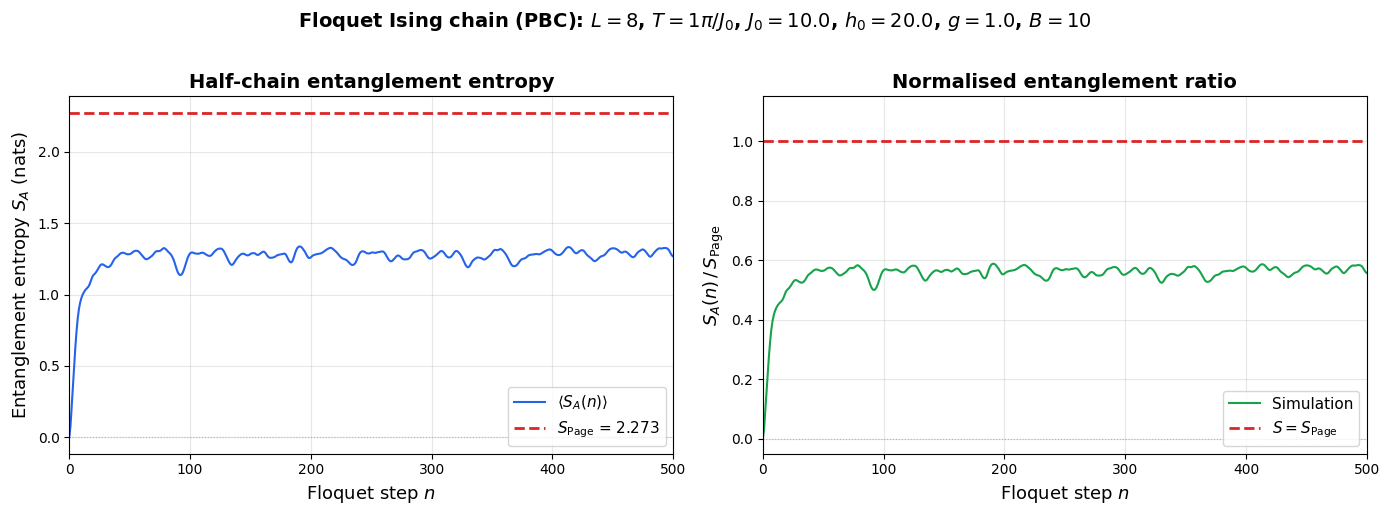


ENTANGLEMENT DYNAMICS SUMMARY
  Chain length:   L = 8
  Period:         T = 1·π/J₀ = 0.314159
  Coupling:       J₀ = 10.0
  Field:          h₀ = 20.0
  Perturbation:   g  = 1.0
  Averaged over:  B  = 10 product states

  S(0)           = -0.000000  (-0.0000 × S_Page)
  S(n=500)        = 1.265404  (0.5568 × S_Page)
  S_Page         = 2.272589
  Max S/S_Page   = 0.5880 at n = 191
  Steps to 0.9·S_Page: not reached


In [ ]:

import matplotlib.pyplot as plt

matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ============================================================
# PART 6B: PLOTTING — ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes: steps, S_avg, S_Page  (from Part 6A)
# Also reads: L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
#             n_floquet_steps, n_initial_states
#
# These variables must exist in the notebook namespace.
# ============================================================


def plot_entanglement_dynamics(steps, S_avg, S_Page, L, J_0, h_0, g,
                               n_period, n_states=None):
    """
    Plot entanglement entropy vs Floquet steps.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices [0, 1, ..., n].
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_Page : float
        Page value for this system size.
    L : int
        System size.
    J_0, h_0, g : float
        Hamiltonian parameters.
    n_period : int
        Integer n in T = n·π/J₀.
    n_states : int, optional
        Number of initial states averaged (for annotation).
    """
    S_ratio = S_avg / S_Page

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Raw entropy S(n) ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb', label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_Page, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}$ = {S_Page:.3f}')
    ax1.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax1.set_xlabel("Floquet step $n$", fontsize=13)
    ax1.set_ylabel("Entanglement entropy $S_A$ (nats)", fontsize=13)
    ax1.set_title("Half-chain entanglement entropy", fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(bottom=-0.05 * S_Page)

    # ---- Right: Ratio S(n)/S_Page ----
    ax2.plot(steps, S_ratio, '-', lw=1.5, color='#16a34a', label='Simulation')
    ax2.axhline(1.0, color='#dc2626', ls='--', lw=2, label='$S = S_{\\mathrm{Page}}$')
    ax2.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax2.set_xlabel("Floquet step $n$", fontsize=13)
    ax2.set_ylabel(r"$S_A(n) \,/\, S_{\mathrm{Page}}$", fontsize=13)
    ax2.set_title("Normalised entanglement ratio", fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])
    ax2.set_ylim(-0.05, max(1.15, np.max(S_ratio) * 1.05))

    # ---- Suptitle with parameters ----
    title_str = (f"Floquet Ising chain (PBC): $L={L}$, "
                 f"$T={n_period}\\pi/J_0$, "
                 f"$J_0={J_0}$, $h_0={h_0}$, $g={g}$")
    if n_states is not None:
        title_str += f", $B={n_states}$"
    fig.suptitle(title_str, fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 70)
    print("ENTANGLEMENT DYNAMICS SUMMARY")
    print("=" * 70)
    print(f"  Chain length:   L = {L}")
    print(f"  Period:         T = {n_period}·π/J₀ = {n_period * np.pi / J_0:.6f}")
    print(f"  Coupling:       J₀ = {J_0}")
    print(f"  Field:          h₀ = {h_0}")
    print(f"  Perturbation:   g  = {g}")
    if n_states is not None:
        print(f"  Averaged over:  B  = {n_states} product states")
    print(f"\n  S(0)           = {S_avg[0]:.6f}  ({S_ratio[0]:.4f} × S_Page)")
    print(f"  S(n={len(steps)-1})        = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
    print(f"  S_Page         = {S_Page:.6f}")
    print(f"  Max S/S_Page   = {np.max(S_ratio):.4f} at n = {steps[np.argmax(S_ratio)]}")

    idx_90 = np.where(S_ratio >= 0.9)[0]
    if len(idx_90) > 0:
        print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
    else:
        print(f"  Steps to 0.9·S_Page: not reached")
    print("=" * 70)


# ============================================================
# EXECUTE PLOT (uses variables from Part 6A)
# ============================================================

print("=" * 60)
print("PLOTTING RESULTS")
print("=" * 60)

plot_entanglement_dynamics(
    steps, S_avg, S_Page,
    L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
    n_states=n_initial_states
)

# Prethermal Hilbert space fragmentation analysis

We move towards showing that the violation of ETH is due to Hilbert space fragmentation. We show this by showing that the entanglement entropy of an initial state belonging to the largest fragment saturates to the page value of the largest fragment.

References:


1.   Somsubhra Ghosh, Indranil Paul, and K. Sengupta, "Prethermal Fragmentation in a Periodically Driven Fermionic Chain," Phys. Rev. Lett. 130, 120401 (2023). doi: [10.1103/PhysRevLett.130.120401](https://doi.org/10.1103/PhysRevLett.130.120401).
2.   Pablo Sala et al., "Ergodicity Breaking Arising from Hilbert Space Fragmentation in Dipole-Conserving Hamiltonians," Phys. Rev. X 10, 011047 (2020). doi: [10.1103/PhysRevX.10.011047](https://doi.org/10.1103/PhysRevX.10.011047).

The fragmentation is prethermal because we are analysing only the first-order Floquet hamiltonian using Floquet perturbation theory.

Reference:

Arnab Sen, Diptiman Sen, and K. Sengupta, "Analytic approaches to periodically driven closed quantum systems: methods and applications," J. Phys.: Condens. Matter 33, 443003 (2021). doi: [10.1088/1361-648X/ac1b61](https://doi.org/10.1088/1361-648X/ac1b61).

## Floquet Hamiltonian and different fragments


The first-order Floquet Hamiltonian at the fragmentation driving time periods becomes:

$$
\boxed{\;
(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\delta_{P_{nm},0},
\;}
$$

where, $P_{nm}$ is the difference between the operator $\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$ eigenvalues in the nth and mth states in the Fock site basis.  




## Building the $\mathcal{O}$ operator for periodic boundary conditions:

$$\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$$



In [ ]:
# ============================================================
# PART 1: FRAGMENT ANALYSIS — OPERATOR O CONSTRUCTION (OBC)
#         NATIVE IMPLEMENTATION
# ============================================================
#
# Drop-in replacement for the QuSpin-based build_O_operator.
# Follows the Hamiltonian bit convention from Prompt 1:
#
#   Site j  →  bit position p(j) = L - 1 - j
#   z_j(s)  = 1 - 2*c_j,   c_j = (s >> (L-1-j)) & 1
#
# THEOREM (Convention Independence for OBC):
#   For O = J0 Σ σ^z_i σ^z_{i+1} + 2J0 Σ σ^z_i on an open chain,
#   O_s is identical whether site j → bit j or bit (L-1-j).
#   Proof: Z part depends only on popcount(s);
#          ZZ part sums XOR of adjacent bit pairs — same set either way.
#   Consequence: Part 2 code works UNCHANGED.
# ============================================================

import numpy as np
from collections import deque


def build_O_operator(L, J0):
    """
    Build the diagonal operator O for Hilbert space fragmentation.

        O = J0 * Σ_{i=0}^{L-2} σ^z_i σ^z_{i+1}  +  2*J0 * Σ_{i=0}^{L-1} σ^z_i

    Open boundary conditions: (L-1) ZZ bonds, no wrap-around.

    Convention (matching build_H_floquet):
        Site j  →  bit position p(j) = L - 1 - j
        c_j(s)  = (s >> (L-1-j)) & 1
        z_j(s)  = 1 - 2*c_j(s)
        z_i * z_{i+1} = 1 - 2*(c_i XOR c_{i+1})

    Parameters
    ----------
    L : int
        Number of sites.  Must be >= 2.
    J0 : float
        Coupling constant.

    Returns
    -------
    O_diag : ndarray, shape (2**L,), dtype float64
        Diagonal elements O_n = <n|O|n> indexed by state integer.

    Complexity
    ----------
    Time  :  O(N * L)   where N = 2^L
    Memory:  O(N)       (single 1D array; no matrix constructed)
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")

    N = 1 << L
    states = np.arange(N, dtype=np.int64)
    diag = np.zeros(N, dtype=np.float64)

    # ---- ZZ contribution: J0 * Σ_{i=0}^{L-2} z_i * z_{i+1} ----
    for i in range(L - 1):
        pi  = L - 1 - i       # bit position for site i
        pi1 = L - 2 - i       # bit position for site i+1
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += J0 * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # ---- Z contribution: 2*J0 * Σ_{i=0}^{L-1} z_i ----
    for i in range(L):
        pi = L - 1 - i        # bit position for site i
        ci = (states >> pi) & 1
        diag += 2.0 * J0 * (1.0 - 2.0 * ci.astype(np.float64))

    return diag


# ============================================
# TEST: Build O operator
# ============================================

print("\n" + "=" * 60)
print("PART 1: Building Operator O for Fragment Identification (OBC)")
print("         NATIVE (no QuSpin) — Hamiltonian bit convention")
print("=" * 60)

# Parameters for fragmentation analysis
L_frag = 12
J0_frag = 10.0

print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}")
print(f"Boundary conditions: OPEN (L-1 = {L_frag - 1} ZZ bonds)")

# Build O diagonal
O_diag = build_O_operator(L_frag, J0_frag)
Ns = 2 ** L_frag

print(f"O_diag shape: {O_diag.shape}")
print(f"Hilbert space dimension: Ns = {Ns}")

# ---- Verify with hand computation ----
# Convention: bit=0 → UP (σ^z = +1), bit=1 → DOWN (σ^z = -1)
#
# For OPEN BC with L sites: (L-1) ZZ bonds, no wrap-around.
#
# State 0 (all bits=0) = all UP:
#   ZZ: (+1)(+1) * (L-1) bonds → (L-1)*J0
#   Z:  2*J0*(+1)*L            → 2*L*J0
#   Total: (3L-1)*J0
#
# State 2^L - 1 (all bits=1) = all DOWN:
#   ZZ: (-1)(-1) * (L-1) bonds → (L-1)*J0
#   Z:  2*J0*(-1)*L            → -2*L*J0
#   Total: -(L+1)*J0

N_all_down = Ns - 1  # = 1023 for L=10

expected_all_up   = (3 * L_frag - 1) * J0_frag     # = 290
expected_all_down = -(L_frag + 1) * J0_frag         # = -110

print(f"\nVerification (OBC, L={L_frag}):")
print(f"  O_diag[0]    = {O_diag[0]:.1f}  "
      f"(all UP,   expected: (3·{L_frag}-1)·{J0_frag:.0f} = {expected_all_up:.0f})")
print(f"  O_diag[{N_all_down}] = {O_diag[N_all_down]:.1f}  "
      f"(all DOWN, expected: -({L_frag}+1)·{J0_frag:.0f} = {expected_all_down:.0f})")

assert np.isclose(O_diag[0], expected_all_up), \
    f"All-up failed: {O_diag[0]} != {expected_all_up}"
assert np.isclose(O_diag[N_all_down], expected_all_down), \
    f"All-down failed: {O_diag[N_all_down]} != {expected_all_down}"
print("  ✓ Verification passed!")

# ---- Value distribution ----
unique_vals = np.unique(O_diag)
print(f"\n  Distinct O values: {len(unique_vals)}")
print(f"  Range: [{O_diag.min():.1f}, {O_diag.max():.1f}]")

print("\n" + "=" * 60)
print("Part 1 complete: O operator built successfully (OBC)")
print("  • No QuSpin dependency")
print("  • Convention: site j → bit (L-1-j)  [matches build_H_floquet]")
print("  • Convention-independent output (identical to QuSpin)")
print("=" * 60)


PART 1: Building Operator O for Fragment Identification (OBC)
         NATIVE (no QuSpin) — Hamiltonian bit convention

Parameters: L = 12, J0 = 10.0
Boundary conditions: OPEN (L-1 = 11 ZZ bonds)
O_diag shape: (4096,)
Hilbert space dimension: Ns = 4096

Verification (OBC, L=12):
  O_diag[0]    = 350.0  (all UP,   expected: (3·12-1)·10 = 350)
  O_diag[4095] = -130.0  (all DOWN, expected: -(12+1)·10 = -130)
  ✓ Verification passed!

  Distinct O values: 23
  Range: [-130.0, 350.0]

Part 1 complete: O operator built successfully (OBC)
  • No QuSpin dependency
  • Convention: site j → bit (L-1-j)  [matches build_H_floquet]
  • Convention-independent output (identical to QuSpin)


## Connectivity graph and largest fragment:




In [ ]:
import numpy as np
from collections import deque


# ============================================================
# PART 9: CONNECTIVITY GRAPH AND FRAGMENT IDENTIFICATION
#         WITH ↑↑ BOND ANALYSIS (No QuSpin)
# ============================================================
#
# Prerequisites: Part 8 (O operator)
#   Required from Part 8: O_diag, L_frag, J0_frag
#
# Produces: adjacency, components, stats, largest_fragment,
#           D_largest, N_defect_all, bond_patterns_all,
#           fragment_summary
# ============================================================


# ============================================================
# CONNECTIVITY GRAPH
# ============================================================

def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition P_nm = 0)

    Parameters
    ----------
    L : int
        Number of sites.
    O_diag : ndarray
        Diagonal elements of O operator.
    tol : float
        Tolerance for resonance condition.

    Returns
    -------
    adjacency : list of lists
        adjacency[n] = list of neighbours of state n.
    num_edges : int
        Total number of edges.
    """
    Ns = 1 << L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]
        for i in range(L):
            m = n ^ (1 << i)
            if m > n:
                if abs(O_n - O_diag[m]) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters
    ----------
    adjacency : list of lists
        Adjacency list representation.

    Returns
    -------
    components : list of lists
        Each element is a sorted list of state indices in that fragment.
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            component = []
            queue = deque([start])
            visited[start] = True
            while queue:
                node = queue.popleft()
                component.append(node)
                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            components.append(sorted(component))

    return components


def get_fragment_statistics(components):
    """Compute statistics about the fragments."""
    sizes = [len(c) for c in components]
    size_counts = {}
    for s in sizes:
        size_counts[s] = size_counts.get(s, 0) + 1

    return {
        'num_fragments': len(components),
        'sizes': sorted(sizes),
        'max_size': max(sizes),
        'min_size': min(sizes),
        'num_singletons': sum(1 for s in sizes if s == 1),
        'size_counts': size_counts,
    }


def find_largest_fragment(components):
    """Return the largest fragment (list of state indices)."""
    return max(components, key=len)


# ============================================================
# SPIN CONFIGURATION HELPERS
# ============================================================

def get_spin_config(state_idx, L):
    """
    Get spin configuration string for a state.
    Convention: bit=0 → UP (↑), bit=1 → DOWN (↓).
    """
    spins = []
    for i in range(L):
        bit = (state_idx >> i) & 1
        spins.append('↓' if bit else '↑')
    return ''.join(spins)


def get_spin_array(state_idx, L):
    """
    Convert state index to array S[i] = ±1.
    bit=0 → +1 (up), bit=1 → -1 (down).
    """
    S = np.empty(L, dtype=int)
    for i in range(L):
        bit = (state_idx >> i) & 1
        S[i] = +1 if bit == 0 else -1
    return S


# ============================================================
# ↑↑ BOND ANALYSIS
# ============================================================

def get_upup_bond_pattern(state_idx, L):
    """
    Return length-L array: p[i]=1 if bond (i, i+1 mod L) is ↑↑, else 0.
    """
    S = get_spin_array(state_idx, L)
    p = np.zeros(L, dtype=int)
    for i in range(L):
        if S[i] == +1 and S[(i + 1) % L] == +1:
            p[i] = 1
    return p


def get_N_defect(state_idx, L):
    """Number of ↑↑ bonds in the configuration."""
    return int(get_upup_bond_pattern(state_idx, L).sum())


def bond_pattern_to_string(p):
    """Convert integer array p[i] ∈ {0,1} to string '0101...'."""
    return ''.join(str(x) for x in p)


# ============================================================
# DISPLAY FUNCTIONS
# ============================================================

def display_fragment_states(fragment_states, L, O_diag, adjacency,
                            N_defect_all=None, bond_patterns_all=None):
    """Display detailed information about states in a fragment."""
    print(f"  {'#':<4} {'Index':<8} {'Binary':<{L+2}} {'Spins':<{L+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)':<{L+2}} {'Neighbors'}")
    print("  " + "-" * (55 + 3 * L))

    for i, state_idx in enumerate(fragment_states):
        binary_str = format(state_idx, f'0{L}b')
        spin_str = get_spin_config(state_idx, L)
        O_val = O_diag[state_idx]

        N_def = N_defect_all[state_idx] if N_defect_all is not None else 0
        if bond_patterns_all is not None:
            p = bond_patterns_all[state_idx]
            bond_str = bond_pattern_to_string(p) if isinstance(p, np.ndarray) else str(p)
        else:
            bond_str = ""

        neighbors_in_frag = [m for m in adjacency[state_idx] if m in fragment_states]
        neighbors_str = str(neighbors_in_frag) if neighbors_in_frag else "[]"

        print(f"  {i+1:<4} {state_idx:<8} {binary_str:<{L+2}} {spin_str:<{L+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str:<{L+2}} {neighbors_str}")


def display_all_fragments(components, L, O_diag, adjacency,
                          N_defect_all=None, bond_patterns_all=None,
                          sort_by_size=True, show_singletons=True,
                          max_display=None):
    """Display detailed information about ALL fragments."""
    sorted_comps = sorted(components, key=len, reverse=True) if sort_by_size else components
    if not show_singletons:
        sorted_comps = [c for c in sorted_comps if len(c) > 1]
    if max_display is not None:
        sorted_comps = sorted_comps[:max_display]

    print(f"\n{'=' * 90}")
    print(f"DETAILED FRAGMENT DATA (Showing {len(sorted_comps)} of {len(components)} fragments)")
    print(f"{'=' * 90}")

    for frag_idx, fragment in enumerate(sorted_comps):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_str = ""
        if N_defect_all is not None:
            N_vals = set(N_defect_all[s] for s in fragment)
            N_def_str = f", N_defect = {N_vals}"

        print(f"\n{'─' * 90}")
        print(f"FRAGMENT {frag_idx + 1}: D = {D} states, O = {O_val:.2f}, "
              f"Internal edges = {internal_edges}{N_def_str}")
        print(f"{'─' * 90}")
        display_fragment_states(fragment, L, O_diag, adjacency,
                                N_defect_all, bond_patterns_all)

    print(f"\n{'=' * 90}")
    print(f"End of fragment data")
    print(f"{'=' * 90}")


# ============================================================
# SUMMARY TABLE
# ============================================================

def create_fragment_summary_table(components, L, O_diag, adjacency,
                                  N_defect_all=None, bond_patterns_all=None):
    """Create a summary table of all fragments with ↑↑ bond analysis."""
    summary = []

    for frag_idx, fragment in enumerate(components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_unique = sorted(set(N_defect_all[s] for s in fragment)) \
            if N_defect_all is not None else []
        patterns_unique = sorted(set(
            bond_pattern_to_string(bond_patterns_all[s]) for s in fragment
        )) if bond_patterns_all is not None else []

        summary.append({
            'fragment_id': frag_idx + 1,
            'size': D,
            'O_value': O_val,
            'internal_edges': internal_edges,
            'states': fragment,
            'N_defect_values': N_def_unique,
            'bond_patterns': patterns_unique,
        })

    summary.sort(key=lambda x: x['size'], reverse=True)
    return summary


def print_fragment_summary_table(summary, L):
    """Print compact summary table."""
    print(f"\n{'=' * 110}")
    print("FRAGMENT SUMMARY TABLE (with ↑↑ bond analysis)")
    print(f"{'=' * 110}")
    print(f"{'ID':<6} {'Size':<8} {'O value':<12} {'Edges':<8} "
          f"{'#N_def':<8} {'#patterns':<12} {'N_def':<8} {'Example pattern':<{L+2}}")
    print(f"{'-' * 110}")

    for frag in summary:
        N_list = frag.get('N_defect_values', [])
        pat_list = frag.get('bond_patterns', [])
        example_pat = pat_list[0] if pat_list else ''
        example_N = str(N_list[0]) if N_list else ''

        print(f"{frag['fragment_id']:<6} {frag['size']:<8} {frag['O_value']:<12.2f} "
              f"{frag['internal_edges']:<8} {len(N_list):<8} {len(pat_list):<12} "
              f"{example_N:<8} {example_pat:<{L+2}}")

    print(f"{'=' * 110}")


# ============================================================
# FIBONACCI CHECK
# ============================================================

def fib(n):
    """Compute n-th Fibonacci number (F_0=0, F_1=1, F_2=1, ...)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ============================================================
# EXECUTE PART 9
# ============================================================

print("\n" + "=" * 60)
print("PART 9: Building Connectivity Graph and Finding Fragments")
print("        (with ↑↑ bond analysis)")
print("=" * 60)

Ns = 2**L_frag
tol = 1e-10
print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}, tol = {tol}")

# --- Precompute N_defect and bond patterns ---
print("\nPrecomputing N_defect and ↑↑ bond patterns for all states...")
N_defect_all = np.zeros(Ns, dtype=int)
bond_patterns_all = [None] * Ns

for n in range(Ns):
    p = get_upup_bond_pattern(n, L_frag)
    bond_patterns_all[n] = p
    N_defect_all[n] = int(p.sum())

print(f"  N_defect range: {N_defect_all.min()} to {N_defect_all.max()}")
print(f"  N_defect distribution:")
for n_val in range(N_defect_all.max() + 1):
    count = np.sum(N_defect_all == n_val)
    if count > 0:
        print(f"    N_defect = {n_val}: {count} states")

# --- Build connectivity graph ---
print("\nBuilding connectivity graph...")
adjacency, num_edges = build_connectivity_graph(L_frag, O_diag, tol)

total_possible_edges = Ns * L_frag // 2
print(f"  Number of edges: {num_edges}")
print(f"  Total possible edges (all single-flips): {total_possible_edges}")
print(f"  Fraction kept: {num_edges / total_possible_edges:.4f}")

# --- Find connected components ---
print("\nFinding connected components...")
components = find_connected_components(adjacency)
stats = get_fragment_statistics(components)

print(f"\n  Number of fragments: {stats['num_fragments']}")
print(f"  Largest fragment size: {stats['max_size']}")
print(f"  Number of singletons: {stats['num_singletons']}")

print("\n  Size distribution:")
print(f"    {'Size':<8} {'Count':<8} {'Total':<8}")
print("    " + "-" * 24)
for size in sorted(stats['size_counts'].keys()):
    count = stats['size_counts'][size]
    print(f"    {size:<8} {count:<8} {size * count:<8}")

# --- Largest fragment ---
largest_fragment = find_largest_fragment(components)
D_largest = len(largest_fragment)

print(f"\n  Largest fragment has D = {D_largest} states")
print(f"  O value in largest fragment: {O_diag[largest_fragment[0]]:.1f}")

total_states = sum(len(c) for c in components)
assert total_states == Ns, f"Total states mismatch: {total_states} != {Ns}"
print(f"\n  Total states across all fragments: {total_states} = Ns ✓")

# --- Summary table ---
fragment_summary = create_fragment_summary_table(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all
)
print_fragment_summary_table(fragment_summary, L_frag)

# --- ↑↑ bond pattern analysis ---
print("\n" + "=" * 70)
print("↑↑ BOND PATTERN ANALYSIS")
print("=" * 70)

num_single_pattern = sum(1 for frag in fragment_summary
                         if len(frag['bond_patterns']) == 1)
print(f"\nFragments with a single frozen ↑↑-bond pattern: "
      f"{num_single_pattern}/{len(fragment_summary)}")

num_single_N = sum(1 for frag in fragment_summary
                   if len(frag['N_defect_values']) == 1)
print(f"Fragments with a single N_defect value: "
      f"{num_single_N}/{len(fragment_summary)}")

largest = fragment_summary[0]
print("\nLargest fragment details:")
print(f"  ID: {largest['fragment_id']}")
print(f"  Size: {largest['size']}")
print(f"  O value: {largest['O_value']:.2f}")
print(f"  N_defect values: {largest['N_defect_values']}")
print(f"  Bond patterns: {largest['bond_patterns']}")
print(f"  Number of distinct patterns: {len(largest['bond_patterns'])}")

if largest['N_defect_values'] == [0]:
    print("  ✓ Largest fragment has N_defect = 0 (no ↑↑ bonds)")
else:
    print(f"  ⚠ Largest fragment has N_defect = {largest['N_defect_values']}")

if largest['bond_patterns'] == ['0' * L_frag]:
    print(f"  ✓ Bond pattern is all zeros: {'0' * L_frag}")

# --- Fibonacci check ---
print("\n" + "-" * 70)
print("Fibonacci consistency check (no adjacent ↑ on ring):")
print("-" * 70)

dim_no_adj_ring = fib(L_frag - 1) + fib(L_frag + 1)
print(f"  L = {L_frag}")
print(f"  F_{L_frag-1} = {fib(L_frag - 1)}")
print(f"  F_{L_frag+1} = {fib(L_frag + 1)}")
print(f"  Predicted dimension (no adjacent ↑ on ring): "
      f"F_{L_frag-1} + F_{L_frag+1} = {dim_no_adj_ring}")
print(f"  Largest fragment size: {D_largest}")

if D_largest == dim_no_adj_ring:
    print(f"  ✓ Matches! Largest fragment = configurations with no ↑↑ bonds")
else:
    print(f"  ⚠ Mismatch: {D_largest} ≠ {dim_no_adj_ring}")

# --- Display non-singleton fragments ---
display_all_fragments(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all,
    sort_by_size=True, show_singletons=False, max_display=None
)

# --- Display singletons ---
singleton_count = stats['num_singletons']
if singleton_count > 0:
    print(f"\n{'=' * 80}")
    print(f"SINGLETON FRAGMENTS (Size = 1): {singleton_count} total")
    print(f"{'=' * 80}")
    print(f"  {'Index':<8} {'Binary':<{L_frag+2}} {'Spins':<{L_frag+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)'}")
    print("  " + "-" * (50 + 3 * L_frag))

    singletons = sorted(c[0] for c in components if len(c) == 1)
    for state_idx in singletons:
        binary_str = format(state_idx, f'0{L_frag}b')
        spin_str = get_spin_config(state_idx, L_frag)
        O_val = O_diag[state_idx]
        N_def = N_defect_all[state_idx]
        bond_str = bond_pattern_to_string(bond_patterns_all[state_idx])
        print(f"  {state_idx:<8} {binary_str:<{L_frag+2}} {spin_str:<{L_frag+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str}")

print("\n" + "=" * 60)
print("Part 9 complete: Fragments identified successfully")
print("              (with ↑↑ bond conservation analysis)")
print("=" * 60)


PART 9: Building Connectivity Graph and Finding Fragments
        (with ↑↑ bond analysis)

Parameters: L = 12, J0 = 10.0, tol = 1e-10

Precomputing N_defect and ↑↑ bond patterns for all states...
  N_defect range: 0 to 12
  N_defect distribution:
    N_defect = 0: 322 states
    N_defect = 1: 660 states
    N_defect = 2: 834 states
    N_defect = 3: 796 states
    N_defect = 4: 627 states
    N_defect = 5: 408 states
    N_defect = 6: 250 states
    N_defect = 7: 108 states
    N_defect = 8: 66 states
    N_defect = 9: 12 states
    N_defect = 10: 12 states
    N_defect = 12: 1 states

Building connectivity graph...
  Number of edges: 5120
  Total possible edges (all single-flips): 24576
  Fraction kept: 0.2083

Finding connected components...

  Number of fragments: 1081
  Largest fragment size: 144
  Number of singletons: 441

  Size distribution:
    Size     Count    Total   
    ------------------------
    1        441      441     
    2        244      488     
    3        13

## Fragment Page value by Monte Carlo sampling:
What Page actually did
Take a bipartite Hilbert space
$$
\mathcal H = \mathcal H_A \otimes \mathcal H_B, \quad
\dim \mathcal H_A = m \le \dim \mathcal H_B = n.
$$
Choose a pure state $|\psi\rangle$ uniformly at random with respect to the Haar measure on $\mathcal H$. Let $S_A(\psi)$ be the von Neumann entropy of the reduced density matrix $\rho_A = \mathrm{Tr}_B |\psi\rangle\langle\psi|$.
Page's entropy is
$$
\boxed{
\langle S_A \rangle_{Page} := \mathbb{E}_{\psi\ Haar}[S_A(\psi)]
}
$$

Generalizing to a fragment subspace, take some subspace $\mathcal D \subset \mathcal H$ of dimension $D$. We want the fragment Page value.
We fix the bipartition $A|B$.
We put the Haar measure on $\mathcal D$ (random normalized linear combinations of an orthonormal basis of $\mathcal D$).
Then the fragment Page value is
$$
S_p^{\mathcal D} := \mathbb{E}_{\psi \in \mathcal D}[,S_A(\psi)].
$$

So in the fragmentation story:
*   Full symmetry sector: Page value $S_p^{(sector)}$.
*   Fragment subspace $\mathcal D$: Page value $S_p^{(\mathcal D)}$.


Thus,
*   If dynamics explores the whole sector ergodically:
$S_{sat} \approx S_p^{(sector)}$.
*   If dynamics is confined to a fragment and is ergodic inside that fragment:
$S_{sat} \approx S_p^{(\mathcal D)}$.




The fragment Page value formula is:

$$
S_p^{(\mathcal D)} := \mathbb{E}_{\psi \in \mathcal{D}}\bigl[S_A(\psi)\bigr].
$$



In [ ]:
import numpy as np


# ============================================================
# PART 10: FRAGMENT PAGE VALUE VIA MONTE CARLO
# ============================================================
#
# Prerequisites: Parts 8-9 (O operator, fragment identification)
#   Required: largest_fragment, D_largest, L_frag
#   Required from Prompt 4: bipartite_entropy, compute_page_value
#
# Produces: S_page_full, S_page_frag, S_std_frag, S_sem_frag
# ============================================================


def sample_haar_state_in_fragment(fragment_states, Ns, rng=None):
    """
    Sample a Haar-random state in the fragment subspace.

    |ψ⟩ = Σ_α c_α |φ_α⟩  where c_α are normalised complex
    Gaussian coefficients and {|φ_α⟩} are computational basis
    states in the fragment.

    Parameters
    ----------
    fragment_states : array-like of int
        Basis state indices in the fragment.  Converted to ndarray
        once by the caller for best performance.
    Ns : int
        Full Hilbert space dimension (2^L).
    rng : np.random.Generator or None
        If None, uses global np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (Ns,), complex128
        Haar-random state with support only on fragment states.
    """
    D = len(fragment_states)

    if rng is None:
        z = np.random.randn(D) + 1j * np.random.randn(D)
    else:
        z = rng.standard_normal(D) + 1j * rng.standard_normal(D)

    c = z / np.linalg.norm(z)

    # Vectorised scatter into full Hilbert space
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[fragment_states] = c          # fancy indexing, no Python loop

    return psi


def compute_fragment_page_value_MC(fragment_states, L, n_samples=1000,
                                    A_indices=None, seed=None,
                                    verbose=True):
    """
    Compute the fragment Page value via Monte Carlo sampling.

    S_Page^(frag) = E_{ψ ∈ fragment}[S_A(ψ)]

    Parameters
    ----------
    fragment_states : list or array of int
        List of basis state indices in the fragment.
    L : int
        Number of sites.
    n_samples : int
        Number of Haar-random states to sample.
    A_indices : list, optional
        Subsystem A indices (default: left half-chain).
    seed : int or None
        RNG seed for reproducibility. None = non-reproducible.
    verbose : bool
        Print progress.

    Returns
    -------
    S_page_frag : float
        Fragment Page value (mean entropy).
    S_std : float
        Standard deviation of entropy distribution.
    S_sem : float
        Standard error of the mean.
    """
    Ns = 1 << L
    D = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # Convert to array once for vectorised scatter in sampler
    frag_arr = np.asarray(fragment_states)

    rng = np.random.default_rng(seed)

    if verbose:
        print(f"\nComputing fragment Page value via Monte Carlo...")
        print(f"  Fragment dimension: D = {D}")
        print(f"  Number of samples: {n_samples}")
        print(f"  Subsystem A: sites {A_indices}")
        if seed is not None:
            print(f"  Seed: {seed}")

    entropies = np.zeros(n_samples)

    for r in range(n_samples):
        psi = sample_haar_state_in_fragment(frag_arr, Ns, rng)
        entropies[r] = bipartite_entropy(psi, L, A_indices)

        if verbose and (r + 1) % 2000 == 0:
            print(f"    Completed {r + 1}/{n_samples} samples")

    S_page_frag = np.mean(entropies)
    S_std = np.std(entropies, ddof=1)
    S_sem = S_std / np.sqrt(n_samples)

    if verbose:
        print(f"\n  Results:")
        print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem:.6f} nats")
        print(f"    Std dev = {S_std:.6f}")
        print(f"    Min entropy: {np.min(entropies):.6f}")
        print(f"    Max entropy: {np.max(entropies):.6f}")

    return S_page_frag, S_std, S_sem


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_samples = 10000     # Number of Monte Carlo samples
seed_MC      = 42        # RNG seed (None for non-reproducible)

# ============================================================
# EXECUTE PART 10
# ============================================================

print("\n" + "=" * 60)
print("PART 10: Computing Fragment Page Value via Monte Carlo")
print("=" * 60)

# Full Hilbert space Page value (analytical)
S_page_full = compute_page_value(L_frag)
print(f"\nFull Hilbert space Page value: S_Page = {S_page_full:.6f} nats")

# Fragment Page value (Monte Carlo)
S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
    largest_fragment, L_frag,
    n_samples=n_MC_samples,
    seed=seed_MC,
    verbose=True
)

# Summary
print("\n" + "-" * 40)
print("COMPARISON:")
print("-" * 40)
Ns_p10 = 2**L_frag
print(f"  Full Hilbert space (Ns = {Ns_p10}):")
print(f"    S_Page = {S_page_full:.6f} nats")
print(f"\n  Largest fragment (D = {D_largest}):")
print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")
print(f"\n  Ratio: S_Page^(frag) / S_Page = {S_page_frag / S_page_full:.4f}")

d_A = 2**(L_frag // 2)
max_possible = np.log(min(D_largest, d_A))
print(f"\n  Theoretical upper bound: ln(min(D, d_A)) = "
      f"ln({min(D_largest, d_A)}) = {max_possible:.6f}")

print("\n" + "=" * 60)
print("Part 10 complete: Fragment Page value computed")
print("=" * 60)


PART 10: Computing Fragment Page Value via Monte Carlo

Full Hilbert space Page value: S_Page = 3.658883 nats

Computing fragment Page value via Monte Carlo...
  Fragment dimension: D = 144
  Number of samples: 10000
  Subsystem A: sites [0, 1, 2, 3, 4, 5]
  Seed: 42
    Completed 2000/10000 samples
    Completed 4000/10000 samples
    Completed 6000/10000 samples
    Completed 8000/10000 samples
    Completed 10000/10000 samples

  Results:
    S_Page^(frag) = 2.029976 ± 0.000413 nats
    Std dev = 0.041307
    Min entropy: 1.817678
    Max entropy: 2.164423

----------------------------------------
COMPARISON:
----------------------------------------
  Full Hilbert space (Ns = 4096):
    S_Page = 3.658883 nats

  Largest fragment (D = 144):
    S_Page^(frag) = 2.029976 ± 0.000413 nats

  Ratio: S_Page^(frag) / S_Page = 0.5548

  Theoretical upper bound: ln(min(D, d_A)) = ln(64) = 4.158883

Part 10 complete: Fragment Page value computed


## Entanglement entropy of the state in a particular fragment

We cannot take a Haar single qubit states and tensor product them to get a pure state in the largest fragment because  we obtain these fragments for a fixed basis. Thus, we instead just choose a random state in the largest fragment and see it evolve.

### Definitions

In [ ]:
import numpy as np
import time


# ============================================================
# FRAGMENT STATE GENERATION
# ============================================================
#
# Prerequisites:
#   Prompt 2: apply_floquet_step
#   Prompt 4: bipartite_entropy
#   (only needed by self-tests: FloquetIsingChain, build_floquet_operator)
#
# Defines:
#   build_random_basis_state_in_fragment(fragment_states, L, rng)
#   build_fragment_states_batched(fragment_states, L, num_states, rng)
#   compute_entanglement_dynamics_fragment_basis(ising_chain, ...)
# ============================================================


def build_random_basis_state_in_fragment(fragment_states, L, rng=None):
    """
    Pick a random computational basis state from a fragment.

    The returned state |n⟩ is a standard basis vector (delta function),
    which is a product state with S_A = 0 for any bipartition.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Computational basis state.
    state_idx : int
        The chosen basis state index.
    """
    Ns = 1 << L

    if rng is None:
        idx = np.random.randint(len(fragment_states))
    else:
        idx = rng.integers(len(fragment_states))

    state_idx = fragment_states[idx]
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[state_idx] = 1.0

    return psi, state_idx


def build_fragment_states_batched(fragment_states, L, num_states, rng=None):
    """
    Build B random computational basis states from a fragment as (Ns × B).

    Each column is a delta function |n_k⟩ where n_k is drawn uniformly
    from fragment_states (with replacement). All columns have S_A = 0.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices in the fragment.
    L : int
        Number of sites.
    num_states : int
        Number of states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42).

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are computational basis states.
    chosen_indices : ndarray, shape (num_states,), int
        The basis state indices that were selected.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    fragment_arr = np.asarray(fragment_states)
    chosen = rng.choice(fragment_arr, size=num_states, replace=True)

    Psi = np.zeros((Ns, num_states), dtype=np.complex128)
    for k in range(num_states):
        Psi[chosen[k], k] = 1.0

    return Psi, chosen


# ============================================================
# FRAGMENT ENTANGLEMENT DYNAMICS — BATCHED KRYLOV
# ============================================================

def compute_entanglement_dynamics_fragment_basis(ising_chain, fragment_states,
                                                  n_periods, n_initial_states=10,
                                                  A_indices=None, seed=42,
                                                  verbose=True,
                                                  renorm_interval=100):
    """
    Compute entanglement entropy evolution starting from random
    computational basis states within a Hilbert space fragment.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() called.
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random basis states to average over (B).
    A_indices : list of int, optional
        Subsystem A indices. Default: left half-chain.
    seed : int
        RNG seed for reproducibility.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise every N steps (0 to disable).

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Time step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Averaged entanglement entropy at each step.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns
    D_frag = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # --- Build batched initial states from fragment ---
    rng = np.random.default_rng(seed)
    Psi, chosen_indices = build_fragment_states_batched(
        fragment_states, L, n_initial_states, rng
    )

    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"  Evolving {n_initial_states} random basis states from fragment...")
        print(f"  Fragment size: D = {D_frag}")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  First initial state: |{chosen_indices[0]}⟩ = "
              f"|{format(chosen_indices[0], f'0{L}b')}⟩")

    # --- Step 0: entropy of initial states (should all be 0) ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be 0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods}: S = {S_current:.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # Average
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        print(f"\n  Final averaged entropy: S = {S_avg[-1]:.6f}")
        print(f"  Wall time: {t_total:.2f} s")

    return steps, S_avg


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("FRAGMENT DYNAMICS — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: build_random_basis_state_in_fragment
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Single fragment basis state")
    print("-" * 72)

    L_t = 6
    Ns_t = 2**L_t
    frag = [0, 3, 5, 12, 63]

    rng_t = np.random.default_rng(42)
    psi_t, idx_t = build_random_basis_state_in_fragment(frag, L_t, rng_t)
    print(f"  Chosen index: {idx_t} (in fragment: {idx_t in frag})")
    print(f"  Shape: {psi_t.shape}, norm: {np.linalg.norm(psi_t):.15f}")
    print(f"  Non-zero entries: {np.count_nonzero(psi_t)}")
    assert idx_t in frag
    assert psi_t.shape == (Ns_t,)
    assert abs(np.linalg.norm(psi_t) - 1.0) < 1e-15
    assert np.count_nonzero(psi_t) == 1
    assert psi_t[idx_t] == 1.0
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Batched fragment states
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_fragment_states_batched")
    print("-" * 72)

    B_t = 10
    rng_t2 = np.random.default_rng(42)
    Psi_t, chosen_t = build_fragment_states_batched(frag, L_t, B_t, rng_t2)

    print(f"  Shape: {Psi_t.shape} (expected ({Ns_t}, {B_t}))")
    assert Psi_t.shape == (Ns_t, B_t)

    for k in range(B_t):
        assert chosen_t[k] in frag, f"Column {k}: {chosen_t[k]} not in fragment"
    print(f"  All {B_t} indices in fragment: PASS")

    nnz_per_col = np.count_nonzero(Psi_t, axis=0)
    assert np.all(nnz_per_col == 1)
    print(f"  All columns are basis states (1 non-zero): PASS")

    norms_t = np.linalg.norm(Psi_t, axis=0)
    assert np.allclose(norms_t, 1.0)
    print(f"  All norms = 1: PASS")

    A_t = list(range(L_t // 2))
    max_S = max(abs(bipartite_entropy(Psi_t[:, k], L_t, A_t)) for k in range(B_t))
    print(f"  Max |S_A|: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: all fragment basis states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 3: Batched column 0 matches single-state (same RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Batch consistency with single-state function")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single, idx_single = build_random_basis_state_in_fragment(frag, L_t, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch, chosen_batch = build_fragment_states_batched(frag, L_t, 5, rng_b)

    print(f"  Single: idx={idx_single}, Batch[0]: idx={chosen_batch[0]}")
    assert idx_single == chosen_batch[0], \
        f"Index mismatch: {idx_single} vs {chosen_batch[0]}"
    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-15
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 4: Fragment dynamics — basic run
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: compute_entanglement_dynamics_fragment_basis (L=6)")
    print("-" * 72)

    ising_ft = FloquetIsingChain(L=L_t, J_0=10.0, h_0=20.0, g=1.0,
                                  TP=np.pi/10.0, hbar=1.0)
    ising_ft.build_hamiltonians()

    all_states = list(range(Ns_t))
    steps_f, S_avg_f = compute_entanglement_dynamics_fragment_basis(
        ising_ft, all_states, n_periods=20, n_initial_states=5,
        seed=42, verbose=False
    )

    assert steps_f.shape == (21,)
    assert S_avg_f.shape == (21,)
    assert abs(S_avg_f[0]) < 1e-12
    assert S_avg_f[10] > 0
    print(f"  S(0) = {S_avg_f[0]:.2e}")
    print(f"  S(20) = {S_avg_f[-1]:.6f}")
    print("  PASS: shapes correct, entropy grows from 0")

    # ----------------------------------------------------------
    # TEST 5: Krylov vs Dense regression
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov vs Dense regression (L=6, fragment, n=30)")
    print("-" * 72)

    n_reg = 30
    B_reg = 5
    seed_reg = 42
    frag_reg = [0, 3, 12, 15, 48, 51, 60, 63]

    steps_k, S_avg_k = compute_entanglement_dynamics_fragment_basis(
        ising_ft, frag_reg, n_reg, B_reg, seed=seed_reg, verbose=False
    )

    U_F_reg = build_floquet_operator(ising_ft)
    rng_d = np.random.default_rng(seed_reg)
    Psi_d, _ = build_fragment_states_batched(frag_reg, L_t, B_reg, rng_d)

    S_avg_d = np.zeros(n_reg + 1)
    A_reg = list(range(L_t // 2))
    for k in range(B_reg):
        S_avg_d[0] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)

    for n in range(1, n_reg + 1):
        Psi_d = U_F_reg @ Psi_d
        for k in range(B_reg):
            S_avg_d[n] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)
    S_avg_d /= B_reg

    max_diff = np.max(np.abs(S_avg_k - S_avg_d))
    print(f"  Max |S_krylov - S_dense|: {max_diff:.2e}")
    assert max_diff < 1e-5, f"Regression failed: {max_diff}"
    print("  PASS: Krylov matches dense for fragment dynamics")

    print("\n" + "=" * 72)
    print("ALL FRAGMENT DYNAMICS TESTS PASSED")
    print("=" * 72)

FRAGMENT DYNAMICS — Self-Tests

------------------------------------------------------------------------
TEST 1: Single fragment basis state
------------------------------------------------------------------------
  Chosen index: 0 (in fragment: True)
  Shape: (64,), norm: 1.000000000000000
  Non-zero entries: 1
  PASS

------------------------------------------------------------------------
TEST 2: build_fragment_states_batched
------------------------------------------------------------------------
  Shape: (64, 10) (expected (64, 10))
  All 10 indices in fragment: PASS
  All columns are basis states (1 non-zero): PASS
  All norms = 1: PASS
  Max |S_A|: 0.00e+00
  PASS: all fragment basis states have S_A = 0

------------------------------------------------------------------------
TEST 3: Batch consistency with single-state function
------------------------------------------------------------------------
  Single: idx=0, Batch[0]: idx=0
  Max |single - batch[:,0]|: 0.00e+00
  PASS

-

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 11A: FRAGMENT ENTANGLEMENT DYNAMICS — RESULTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator → O_diag, L_frag, J0_frag
#   Part 9      : largest_fragment, D_largest, adjacency, components
#   Part 10     : S_page_full, S_page_frag, S_sem_frag  (MC Page value)
#   Fragment dynamics cell: build_random_basis_state_in_fragment,
#                           build_fragment_states_batched,
#                           compute_entanglement_dynamics_fragment_basis
#
# Produces: steps_frag, S_avg_frag
#   (S_page_full, S_page_frag already exist from Part 10)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_periods_frag  = 200      # Number of Floquet periods
n_random_states = 10       # Random basis states to average (B)
seed_frag       = 42       # RNG seed for reproducibility
renorm_frag     = 100      # Renormalise every N steps (0 = off)

# Floquet system parameters (must match Part 8/9 chain)
J0_frag_sim     = J0_frag          # from Part 8
h0_frag_sim     = 2.0 * J0_frag    # h₀ = 2·J₀
g_frag_sim      = 1.0              # transverse field
n_period_frag   = 2                # T = n·π/J₀

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_frag = n_period_frag * np.pi / J0_frag_sim
Ns_frag = 2**L_frag

print("=" * 60)
print("PART 11A: Entanglement Dynamics from Random Fragment Basis States")
print("=" * 60)

print(f"\n  System:")
print(f"    L  = {L_frag}  (Ns = {Ns_frag})")
print(f"    J₀ = {J0_frag_sim},  h₀ = {h0_frag_sim},  g = {g_frag_sim}")
print(f"    T  = {n_period_frag}·π/J₀ = {T_frag:.6f}")

print(f"\n  Fragment:")
print(f"    Size: D = {D_largest}")
print(f"    O value: {O_diag[largest_fragment[0]]:.1f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_frag}")
print(f"    B = {n_random_states} random basis states")
print(f"    seed = {seed_frag}")
print(f"    renorm interval = {renorm_frag}")

# ============================================================
# REFERENCE PAGE VALUES (from Part 10)
# ============================================================

# S_page_full and S_page_frag are in namespace from Part 10.
print(f"\n  Reference values (from Part 10):")
print(f"    S_Page (full, Ns={Ns_frag}):  {S_page_full:.6f} nats")
print(f"    S_Page (frag, D={D_largest}): {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system for fragment dynamics...")
print("-" * 60)

t0_build = time.perf_counter()

ising_frag = FloquetIsingChain(
    L=L_frag, J_0=J0_frag_sim, h_0=h0_frag_sim, g=g_frag_sim,
    TP=T_frag, hbar=1.0
)
ising_frag.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running fragment basis evolution...")
print("-" * 60)

t0_run = time.perf_counter()

steps_frag, S_avg_frag = compute_entanglement_dynamics_fragment_basis(
    ising_frag,
    largest_fragment,
    n_periods_frag,
    n_initial_states=n_random_states,
    seed=seed_frag,
    verbose=True,
    renorm_interval=renorm_frag
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Wall time: {t_build + t_run:.2f} s  (build: {t_build:.3f}s, "
      f"evolve: {t_run:.2f}s)")
print(f"\n  S(n=0)            = {S_avg_frag[0]:.6f} nats (should be ~0)")
print(f"  S(n={n_periods_frag})          = {S_avg_frag[-1]:.6f} nats")
print(f"  S / S_Page^full   = {S_avg_frag[-1] / S_page_full:.4f}")
print(f"  S / S_Page^frag   = {S_avg_frag[-1] / S_page_frag:.4f}")
print("=" * 60)
print("\nData available: steps_frag, S_avg_frag, S_page_full, S_page_frag")
print("Run the plotting cell (Part 11B) to visualise.")

PART 11A: Entanglement Dynamics from Random Fragment Basis States

  System:
    L  = 12  (Ns = 4096)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 2·π/J₀ = 0.628319

  Fragment:
    Size: D = 144
    O value: -130.0

  Simulation:
    n_periods = 200
    B = 10 random basis states
    seed = 42
    renorm interval = 100

  Reference values (from Part 10):
    S_Page (full, Ns=4096):  3.658883 nats
    S_Page (frag, D=144): 2.029976 ± 0.000413 nats

------------------------------------------------------------
Building Floquet system for fragment dynamics...
------------------------------------------------------------
System Parameters (OPEN BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 11 (open chain)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  

### Plotting code

PLOTTING FRAGMENT DYNAMICS


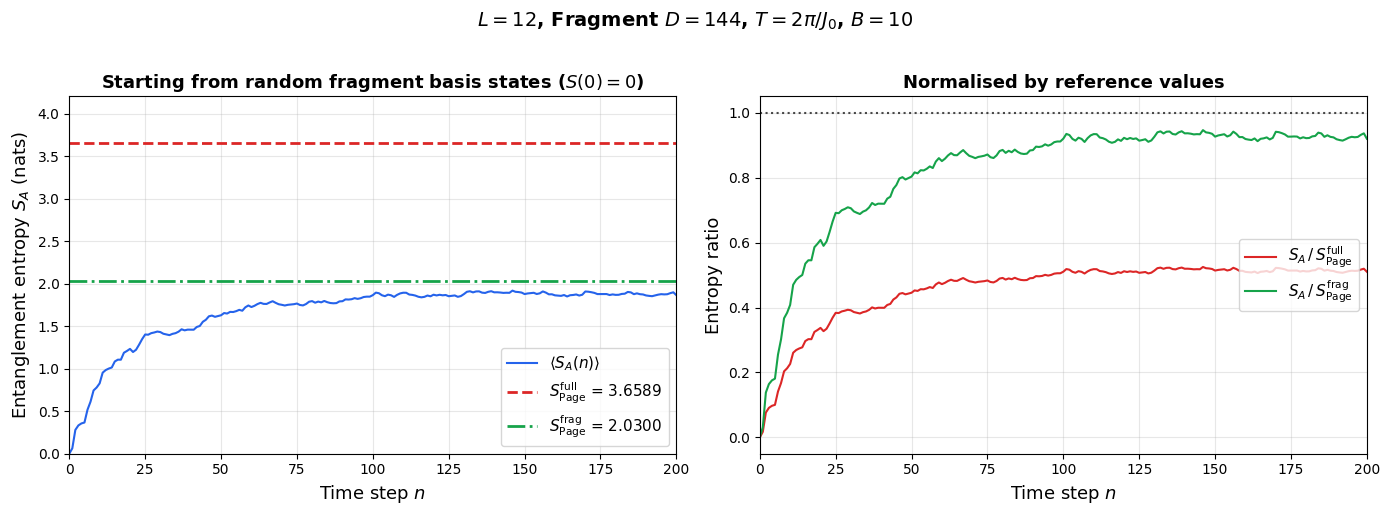


FINAL SUMMARY

  System: L = 12
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  Initial states: 10 random basis states from fragment
  Fragment size: D = 144

  Reference values:
    S_Page (full, Ns=4096):  3.658883 nats
    S_Page (frag, D=144): 2.029976 nats

  Entropy evolution:
    S(n=0)   = 0.000000 nats (should be ~0)
    S(n=200)  = 1.866454 nats

  Final ratios:
    S / S_Page^full = 0.5101
    S / S_Page^frag = 0.9194


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 11B: PLOTTING — FRAGMENT ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes from Part 10: S_page_full, S_page_frag, S_sem_frag
# Consumes from Part 11A: steps_frag, S_avg_frag
# Also reads: D_largest, L_frag, n_random_states, n_periods_frag,
#             largest_fragment, J0_frag_sim, h0_frag_sim,
#             g_frag_sim, n_period_frag
# ============================================================


def plot_fragment_basis_evolution(steps, S_avg, S_page_full, S_page_frag,
                                  D_frag, L, n_states=None,
                                  J0=None, h0=None, g=None, n_period=None):
    """
    Plot entanglement dynamics from random fragment basis states.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices.
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_page_full : float
        Page value for full Hilbert space.
    S_page_frag : float
        Page value for fragment subspace (MC).
    D_frag : int
        Fragment dimension.
    L : int
        System size.
    n_states : int, optional
        Number of initial states averaged.
    J0, h0, g : float, optional
        Hamiltonian parameters for annotation.
    n_period : int, optional
        Integer n in T = n·π/J₀.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Entropy vs time step ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb',
             label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_page_full, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$ = {S_page_full:.4f}')
    ax1.axhline(S_page_frag, color='#16a34a', ls='-.', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$ = {S_page_frag:.4f}')

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Starting from random fragment basis states ($S(0)=0$)',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # ---- Right: Ratio to Page values ----
    ax2.plot(steps, S_avg / S_page_full, '-', lw=1.5, color='#dc2626',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{full}}$')
    ax2.plot(steps, S_avg / S_page_frag, '-', lw=1.5, color='#16a34a',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$')
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)

    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel('Entropy ratio', fontsize=13)
    ax2.set_title('Normalised by reference values', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11, loc='right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])

    # ---- Suptitle ----
    parts = [f'$L = {L}$', f'Fragment $D = {D_frag}$']
    if n_period is not None and J0 is not None:
        parts.append(f'$T = {n_period}\\pi/J_0$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"\n  System: L = {L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_states is not None:
        print(f"  Initial states: {n_states} random basis states from fragment")
    print(f"  Fragment size: D = {D_frag}")

    print(f"\n  Reference values:")
    Ns_disp = 2**L
    print(f"    S_Page (full, Ns={Ns_disp}):  {S_page_full:.6f} nats")
    print(f"    S_Page (frag, D={D_frag}): {S_page_frag:.6f} nats")

    print(f"\n  Entropy evolution:")
    print(f"    S(n=0)   = {S_avg[0]:.6f} nats (should be ~0)")
    print(f"    S(n={len(steps)-1})  = {S_avg[-1]:.6f} nats")

    print(f"\n  Final ratios:")
    print(f"    S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
    print(f"    S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
    print("=" * 60)


# ============================================================
# EXECUTE PLOT (uses variables from Parts 10 + 11A)
# ============================================================

print("=" * 60)
print("PLOTTING FRAGMENT DYNAMICS")
print("=" * 60)

plot_fragment_basis_evolution(
    steps_frag, S_avg_frag,
    S_page_full, S_page_frag,
    D_largest, L_frag,
    n_states=n_random_states,
    J0=J0_frag_sim, h0=h0_frag_sim, g=g_frag_sim,
    n_period=n_period_frag
)

## EE vs $J_0$

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: COMPARISON OF ENTANGLEMENT DYNAMICS FOR DIFFERENT J₀
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components,
#                 find_largest_fragment
#   Part 10     : compute_fragment_page_value_MC
#   Fragment dynamics : build_fragment_states_batched,
#                       compute_entanglement_dynamics_fragment_basis
#
# Produces: results_list (list of dicts, one per J₀)
# ============================================================


def run_fragment_analysis_for_J0(L, J_0, g, n_periods, n_initial_states,
                                  n_MC_samples=500, seed=42, verbose=False):
    """
    Run complete fragment analysis for a given J₀ value.

    Builds the Floquet system, identifies fragments, computes
    fragment Page value via MC, and evolves entanglement dynamics
    from random basis states in the largest fragment.

    All evolution uses batched Krylov — no dense U_F is formed.

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling strength.
    g : float
        Transverse field (perturbation).
    n_periods : int
        Number of Floquet periods.
    n_initial_states : int
        Number of initial states to average (B).
    n_MC_samples : int
        Monte Carlo samples for fragment Page value.
    seed : int
        RNG seed for reproducibility (MC + initial states).
    verbose : bool
        Print detailed output.

    Returns
    -------
    results : dict
        Dictionary with keys: J_0, h_0, T, steps, S_avg,
        S_page_full, S_page_frag, D_largest, wall_time.
    """
    h_0 = 2.0 * J_0
    T = 2*np.pi / J_0   # fragmentation condition

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"J₀ = {J_0}, h₀ = {h_0}, T = π/{J_0}")
        print(f"{'=' * 60}")

    t0 = time.perf_counter()

    # --- Step 1: Fragment identification ---
    O_diag_local = build_O_operator(L, J_0)
    adjacency_local, num_edges = build_connectivity_graph(L, O_diag_local, tol=1e-10)
    components_local = find_connected_components(adjacency_local)
    largest_frag = find_largest_fragment(components_local)
    D = len(largest_frag)

    if verbose:
        print(f"  Fragments: {len(components_local)}, largest D = {D}")

    # --- Step 2: Build Floquet system (sparse, no dense U_F) ---
    ising_local = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=T, hbar=1.0)
    ising_local.build_hamiltonians()

    # --- Step 3: Page values ---
    S_page_full = compute_page_value(L)
    S_page_frag, _, _ = compute_fragment_page_value_MC(
        largest_frag, L, n_samples=n_MC_samples,
        seed=seed, verbose=False
    )

    if verbose:
        print(f"  S_Page (full): {S_page_full:.4f}")
        print(f"  S_Page (frag): {S_page_frag:.4f}")

    # --- Step 4: Batched Krylov evolution ---
    steps, S_avg = compute_entanglement_dynamics_fragment_basis(
        ising_local, largest_frag, n_periods,
        n_initial_states=n_initial_states,
        seed=seed, verbose=False, renorm_interval=100
    )

    wall = time.perf_counter() - t0

    if verbose:
        print(f"  Final entropy: S = {S_avg[-1]:.4f}")
        print(f"  S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
        print(f"  S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
        print(f"  Wall time: {wall:.1f} s")

    return {
        'J_0': J_0,
        'h_0': h_0,
        'T': T,
        'steps': steps,
        'S_avg': S_avg,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'D_largest': D,
        'wall_time': wall,
    }


# ============================================================
#  CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_compare              = 12
g_compare              = 1.0
n_periods_compare      = 200
n_initial_states_compare = 10
n_MC_compare           = 500       # MC samples per J₀ for fragment Page
seed_compare           = 42

J_0_values = [1, 3, 4, 10, 20]

# ============================================================
# EXECUTE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("PART 12: Comparing Entanglement Dynamics for Different J₀ Values")
print("=" * 70)

print(f"\n  L = {L_compare}")
print(f"  g = {g_compare}")
print(f"  h₀ = 2·J₀")
print(f"  T  = π/J₀ (fragmentation condition)")
print(f"  Floquet periods: {n_periods_compare}")
print(f"  Initial states:  {n_initial_states_compare}")
print(f"  MC samples:      {n_MC_compare}")
print(f"  seed:            {seed_compare}")
print(f"  J₀ values:       {J_0_values}")

results_list = []
t0_total = time.perf_counter()

for J_0 in J_0_values:
    print(f"\n--- Processing J₀ = {J_0} ---")
    result = run_fragment_analysis_for_J0(
        L=L_compare, J_0=J_0, g=g_compare,
        n_periods=n_periods_compare,
        n_initial_states=n_initial_states_compare,
        n_MC_samples=n_MC_compare,
        seed=seed_compare,
        verbose=True
    )
    results_list.append(result)

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "=" * 90)
print("COMPARISON SUMMARY")
print("=" * 90)
print(f"{'J₀':<8} {'h₀':<8} {'T':<12} {'D':<8} "
      f"{'S_final':<10} {'S/S_Page':<10} {'S/S_frag':<10} {'Time(s)':<8}")
print("-" * 90)

for r in results_list:
    print(f"{r['J_0']:<8.1f} {r['h_0']:<8.1f} {r['T']:<12.6f} {r['D_largest']:<8} "
          f"{r['S_avg'][-1]:<10.4f} {r['S_avg'][-1]/r['S_page_full']:<10.4f} "
          f"{r['S_avg'][-1]/r['S_page_frag']:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 90)
print(f"Total wall time: {t_total:.1f} s")
print("\nData available: results_list")
print("Run the plotting cell (Part 12B) to visualise.")


PART 12: Comparing Entanglement Dynamics for Different J₀ Values

  L = 12
  g = 1.0
  h₀ = 2·J₀
  T  = π/J₀ (fragmentation condition)
  Floquet periods: 200
  Initial states:  10
  MC samples:      500
  seed:            42
  J₀ values:       [1, 3, 4, 10, 20]

--- Processing J₀ = 1 ---

J₀ = 1, h₀ = 2.0, T = π/1
  Fragments: 853, largest D = 322
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 1
  h_0 = 2.0
  g = 1.0
  Period T = 3.141593
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 75.40, ||A-||_1 = 75.40
  Krylov sub-steps: K+ = 16, K- = 16
  Hermiticity check (H+): max err = 1.49e-12
  Hermiticity check (H-): max err = 1.93e-12
  S_Page (full): 3.6589
  S_Page (frag): 2.4717
  Final entropy: S = 3.6520
  S / S_Page^full = 

### Plotting code


Plotting comparison...


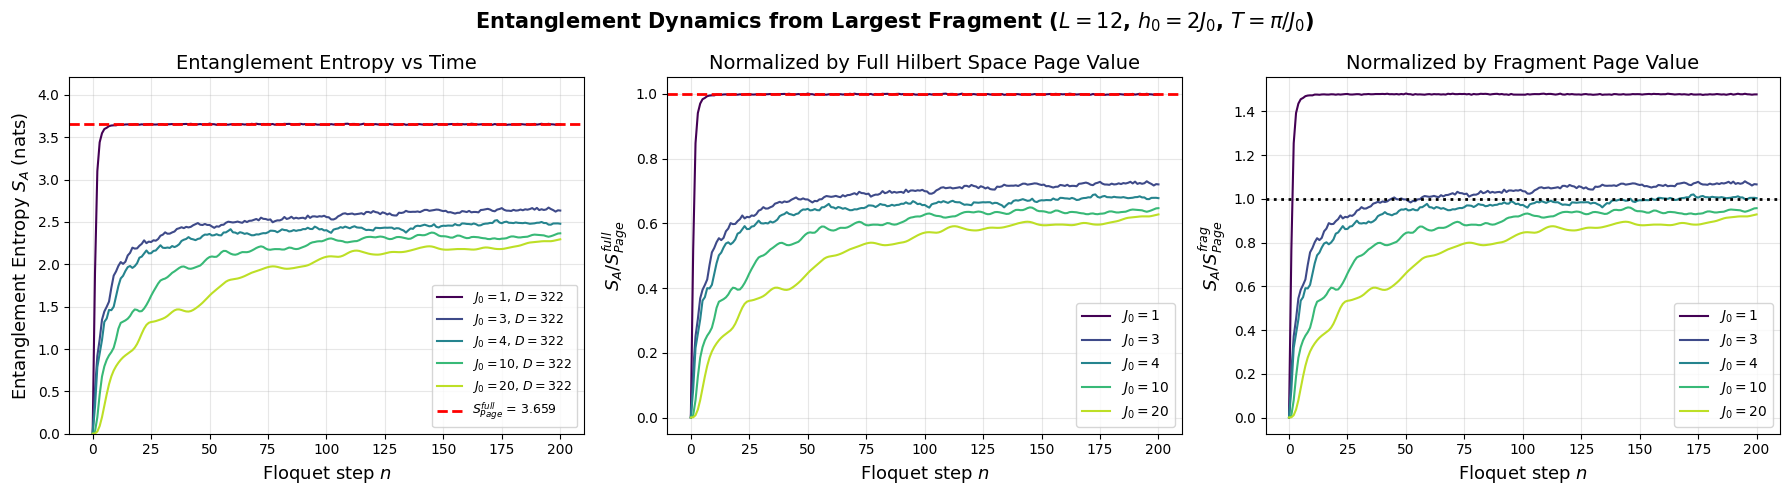


SUMMARY TABLE
J_0      h_0      T            D_frag     S_page^frag  S_final      S/S_Page^full  S/S_Page^frag 
--------------------------------------------------------------------------------
1        2.0      3.141593     322        2.4717       3.6520       0.9981         1.4775        
3        6.0      1.047198     322        2.4717       2.6348       0.7201         1.0660        
4        8.0      0.785398     322        2.4717       2.4793       0.6776         1.0031        
10       20.0     0.314159     322        2.4717       2.3661       0.6467         0.9573        
20       40.0     0.157080     322        2.4717       2.2955       0.6274         0.9287        

✓ Comparison complete!


In [ ]:
def plot_comparison_J0_values(results_list, L):
    """
    Plot entanglement dynamics for different J_0 values.

    Parameters:
    -----------
    results_list : list of dict
        Results from run_fragment_analysis_for_J0 for each J_0
    L : int
        Chain length
    """
    # Color map for different J_0 values
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(results_list)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Get the full Page value (same for all J_0)
    S_page_full = results_list[0]['S_page_full']

    # ========== Left plot: Entropy S(n) ==========
    ax1 = axes[0]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$, $D = {res['D_largest']}$"
        ax1.plot(res['steps'], res['S_avg'], color=colors[i], linewidth=1.5, label=label)

    ax1.axhline(S_page_full, color='red', linestyle='--', linewidth=2,
                label=f'$S_{{Page}}^{{full}}$ = {S_page_full:.3f}')

    ax1.set_xlabel('Floquet step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement Entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Entanglement Entropy vs Time', fontsize=14)
    ax1.legend(fontsize=9, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, S_page_full * 1.15)

    # ========== Middle plot: Ratio to full Page value ==========
    ax2 = axes[1]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax2.plot(res['steps'], res['S_avg'] / S_page_full, color=colors[i],
                 linewidth=1.5, label=label)

    ax2.axhline(1.0, color='red', linestyle='--', linewidth=2)

    ax2.set_xlabel('Floquet step $n$', fontsize=13)
    ax2.set_ylabel(r'$S_A / S_{Page}^{full}$', fontsize=13)
    ax2.set_title('Normalized by Full Hilbert Space Page Value', fontsize=14)
    ax2.legend(fontsize=10, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # ========== Right plot: Ratio to fragment Page value ==========
    ax3 = axes[2]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax3.plot(res['steps'], res['S_avg'] / res['S_page_frag'], color=colors[i],
                 linewidth=1.5, label=label)

    ax3.axhline(1.0, color='black', linestyle=':', linewidth=2)

    ax3.set_xlabel('Floquet step $n$', fontsize=13)
    ax3.set_ylabel(r'$S_A / S_{Page}^{frag}$', fontsize=13)
    ax3.set_title('Normalized by Fragment Page Value', fontsize=14)
    ax3.legend(fontsize=10, loc='lower right')
    ax3.grid(True, alpha=0.3)

    fig.suptitle(f'Entanglement Dynamics from Largest Fragment ($L = {L}$, $h_0 = 2J_0$, $T = \\pi/J_0$)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(f"{'J_0':<8} {'h_0':<8} {'T':<12} {'D_frag':<10} {'S_page^frag':<12} {'S_final':<12} {'S/S_Page^full':<14} {'S/S_Page^frag':<14}")
    print("-"*80)
    for res in results_list:
        print(f"{res['J_0']:<8} {res['h_0']:<8} {res['T']:<12.6f} {res['D_largest']:<10} "
              f"{res['S_page_frag']:<12.4f} {res['S_avg'][-1]:<12.4f} "
              f"{res['S_avg'][-1]/S_page_full:<14.4f} {res['S_avg'][-1]/res['S_page_frag']:<14.4f}")
    print("="*80)



# Plot comparison
print("\n" + "="*70)
print("Plotting comparison...")
print("="*70)

plot_comparison_J0_values(results_list, L_compare)

print("\n✓ Comparison complete!")

## EE vs fragments

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: ENTANGLEMENT DYNAMICS FOR LARGEST DISTINCT-D FRAGMENTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components
#   Fragment dynamics : build_fragment_states_batched
#
# Produces: fragment_results (list of dicts, one per fragment)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_p12           = 12
J_0_p12         = 10.0
h_0_p12         = 2.0 * J_0_p12    # = 20
g_p12           = 1.0
n_period_p12    = 2                 # T = n·π/J₀
n_periods_p12   = 200               # Floquet periods
n_samples_p12   = 10                # initial states per fragment
n_top_frags     = 4                 # how many distinct-D fragments
seed_p12        = 42
renorm_p12      = 100

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_p12  = n_period_p12 * np.pi / J_0_p12
Ns_p12 = 2**L_p12

print("=" * 70)
print(f"PART 12: Entanglement Dynamics for {n_top_frags} Largest Distinct-D Fragments")
print("=" * 70)

print(f"\n  System:")
print(f"    L  = {L_p12}  (Ns = {Ns_p12})")
print(f"    J₀ = {J_0_p12},  h₀ = {h_0_p12},  g = {g_p12}")
print(f"    T  = {n_period_p12}·π/J₀ = {T_p12:.6f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_p12}")
print(f"    B = {n_samples_p12} initial states per fragment")
print(f"    seed = {seed_p12}")

# ============================================================
# BUILD FLOQUET SYSTEM (sparse, no dense U_F)
# ============================================================

print("\n" + "-" * 70)
print("Building Floquet system...")
print("-" * 70)

t0_build = time.perf_counter()

ising_p12 = FloquetIsingChain(
    L=L_p12, J_0=J_0_p12, h_0=h_0_p12, g=g_p12,
    TP=T_p12, hbar=1.0
)
ising_p12.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# FRAGMENT IDENTIFICATION
# ============================================================

print("\n" + "-" * 70)
print("Identifying fragments...")
print("-" * 70)

O_diag_p12 = build_O_operator(L_p12, J_0_p12)
adjacency_p12, num_edges_p12 = build_connectivity_graph(L_p12, O_diag_p12)
components_p12 = find_connected_components(adjacency_p12)

components_sorted = sorted(components_p12, key=len, reverse=True)

# --- Select fragments with DISTINCT dimensions ---
# Walk the size-sorted list; skip any fragment whose D already appeared.
top_fragments = []
seen_D = set()
for frag in components_sorted:
    D = len(frag)
    if D not in seen_D:
        top_fragments.append(frag)
        seen_D.add(D)
    if len(top_fragments) == n_top_frags:
        break

print(f"  Total fragments: {len(components_p12)}")
print(f"  Unique fragment dimensions: "
      f"{sorted(set(len(c) for c in components_p12), reverse=True)}")
print(f"\n  Selected {len(top_fragments)} fragments with distinct D:")
for i, frag in enumerate(top_fragments):
    print(f"    Fragment {i+1}: D = {len(frag)} states")

# ============================================================
# PAGE VALUES
# ============================================================

A_indices_p12 = list(range(L_p12 // 2))
S_page_full_p12 = compute_page_value(L_p12)
print(f"\n  S_Page (full, Ns={Ns_p12}): {S_page_full_p12:.6f} nats")

# ============================================================
# EVOLUTION — BATCHED KRYLOV PER FRAGMENT
# ============================================================

print("\n" + "-" * 70)
print("Running entanglement dynamics per fragment...")
print("-" * 70)

fragment_results = []
t0_total = time.perf_counter()

for i, fragment in enumerate(top_fragments):
    D_frag = len(fragment)
    print(f"\n--- Fragment {i+1} (D = {D_frag}) ---")

    t0_frag = time.perf_counter()

    # Build batched initial states (all B at once)
    rng_frag = np.random.default_rng(seed_p12 + i)
    Psi, chosen = build_fragment_states_batched(
        fragment, L_p12, n_samples_p12, rng_frag
    )

    steps = np.arange(n_periods_p12 + 1)
    S_all = np.zeros((n_samples_p12, n_periods_p12 + 1))

    # Step 0: entropy of initial states (should be 0)
    for k in range(n_samples_p12):
        S_all[k, 0] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

    # Evolution loop
    for n in range(1, n_periods_p12 + 1):
        # Batched Krylov step
        Psi = apply_floquet_step(ising_p12, Psi)

        # Periodic renormalisation
        if renorm_p12 > 0 and n % renorm_p12 == 0:
            norms = np.linalg.norm(Psi, axis=0)
            Psi /= norms[np.newaxis, :]

        # Per-sample entropy
        for k in range(n_samples_p12):
            S_all[k, n] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

        # Progress
        if n % max(1, n_periods_p12 // 5) == 0:
            elapsed = time.perf_counter() - t0_frag
            rate = n / elapsed
            eta = (n_periods_p12 - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods_p12}: "
                  f"<S> = {np.mean(S_all[:, n]):.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    S_avg = np.mean(S_all, axis=0)
    S_std = np.std(S_all, axis=0, ddof=1)
    t_frag = time.perf_counter() - t0_frag

    fragment_results.append({
        'fragment_id': i + 1,
        'D': D_frag,
        'steps': steps,
        'S_avg': S_avg,
        'S_std': S_std,
        'S_all': S_all,
        'wall_time': t_frag,
    })

    print(f"  S(0) = {S_avg[0]:.2e}, S({n_periods_p12}) = {S_avg[-1]:.4f} "
          f"± {S_std[-1]:.4f}")
    print(f"  S / S_Page^full = {S_avg[-1] / S_page_full_p12:.4f}")
    print(f"  Wall time: {t_frag:.1f} s")

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"{'Frag':<6} {'D':<8} {'S_final':<10} {'± std':<10} "
      f"{'S/S_Page':<10} {'Time(s)':<8}")
print("-" * 70)

for r in fragment_results:
    print(f"{r['fragment_id']:<6} {r['D']:<8} {r['S_avg'][-1]:<10.4f} "
          f"{r['S_std'][-1]:<10.4f} "
          f"{r['S_avg'][-1] / S_page_full_p12:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 70)
print(f"Total wall time: {t_total:.1f} s")
print(f"\nData available: fragment_results, S_page_full_p12")
print("Run Part 12B plotting cell to visualise.")

PART 12: Entanglement Dynamics for 4 Largest Distinct-D Fragments

  System:
    L  = 12  (Ns = 4096)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 200
    B = 10 initial states per fragment
    seed = 42

----------------------------------------------------------------------
Building Floquet system...
----------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 58.43, ||A-||_1 = 58.43
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 2.28e-11
  Hermiticity check (H-): max err = 1.50e-11
  Build time: 0.019 

### Plotting code

PART 12B: Computing fragment Page values + plotting

Computing S_Page^frag via Monte Carlo (5000 samples)...
  Fragment 1 (D= 322): S_Page^frag = 2.470260 ± 0.000391 nats
  Fragment 2 (D=  55): S_Page^frag = 1.392477 ± 0.000770 nats
  Fragment 3 (D=  34): S_Page^frag = 0.971694 ± 0.000824 nats
  Fragment 4 (D=  21): S_Page^frag = 0.604761 ± 0.000906 nats



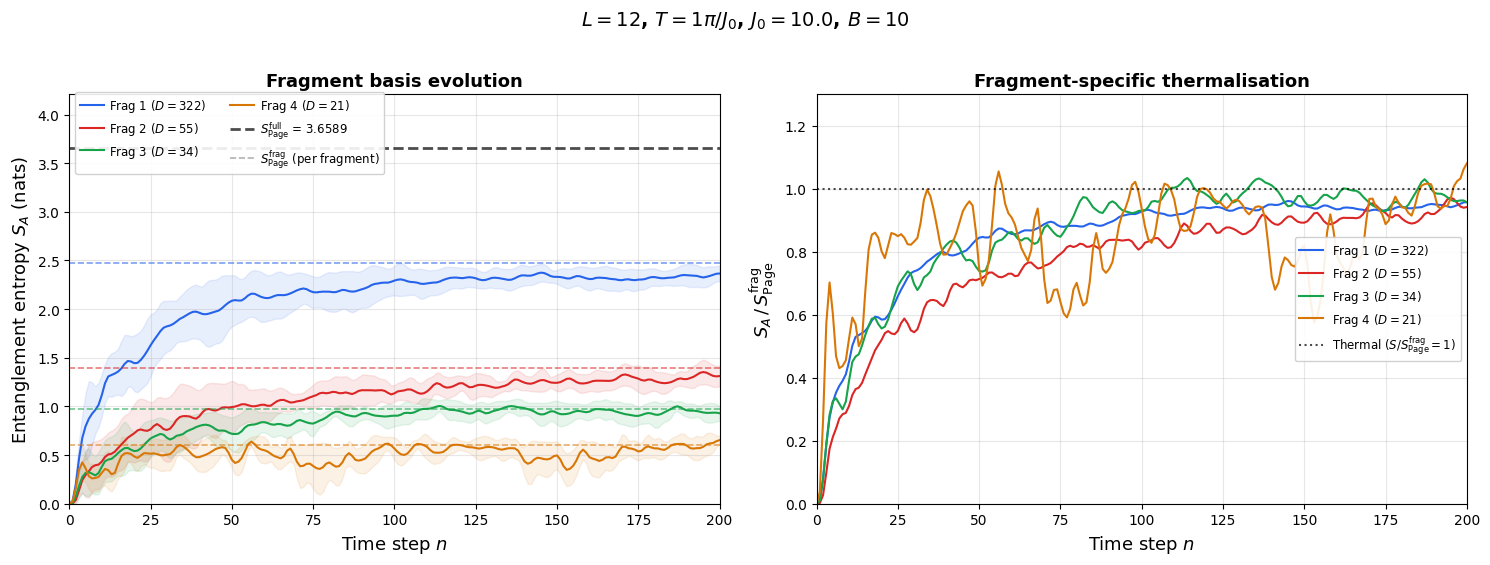

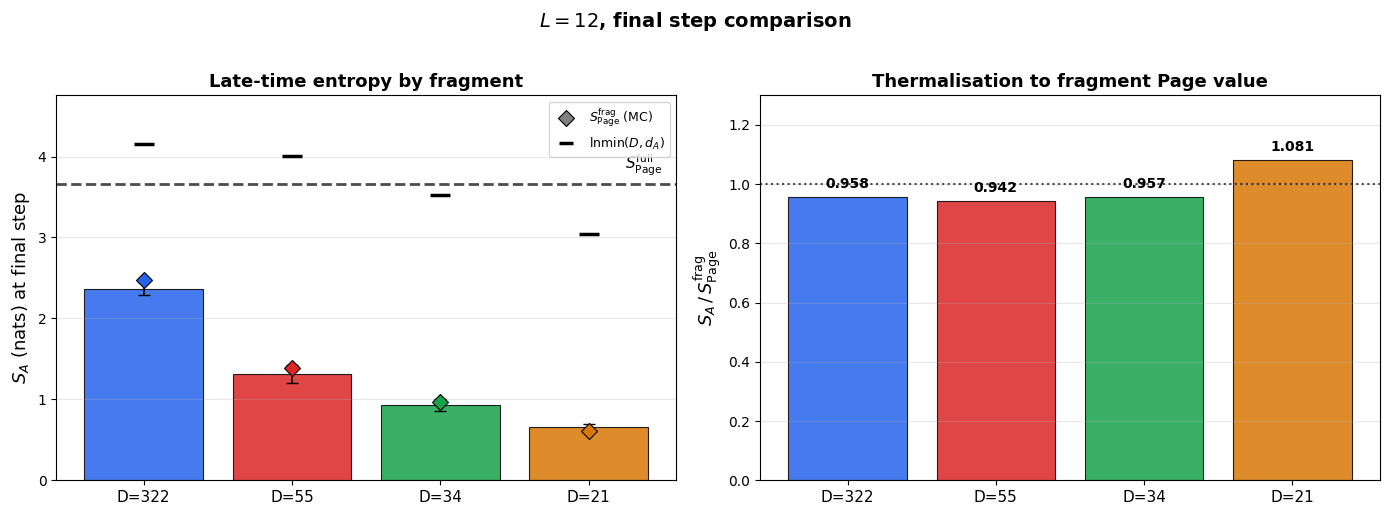


PART 12B — SUMMARY

  System: L = 12, Ns = 4096
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 10 initial states per fragment

  S_Page^full = 3.658883 nats

  Frag   D        S_final      ± σ          S_Page^f     S/S_Pf     S/S_PF     ln min    
  --------------------------------------------------------------------------------
  1      322      2.366073     0.079612     2.470260     0.9578     0.6467     4.158883  
  2      55       1.312064     0.106902     1.392477     0.9423     0.3586     4.007333  
  3      34       0.929860     0.079568     0.971694     0.9569     0.2541     3.526361  
  4      21       0.653598     0.044030     0.604761     1.0808     0.1786     3.044522  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 12B: PLOTTING — MULTI-FRAGMENT ENTANGLEMENT DYNAMICS
#           (with fragment-specific Page value thermalisation)
# ============================================================
#
# Consumes from Part 12:
#   fragment_results : list of dicts (fragment_id, D, steps,
#                      S_avg, S_std, S_all, wall_time)
#   top_fragments    : list of lists (basis state indices)
#   S_page_full_p12  : float (full Hilbert space Page value)
#   L_p12, J_0_p12, h_0_p12, g_p12, n_period_p12, n_samples_p12
#
# Consumes from Part 10:
#   compute_fragment_page_value_MC  (function)
# ============================================================

# Colour palette — distinct, colourblind-friendly
FRAG_COLORS = ['#2563eb', '#dc2626', '#16a34a', '#d97706', '#7c3aed']
FRAG_MARKERS = ['o', 's', '^', 'D', 'v']


def plot_multi_fragment_dynamics(fragment_results, S_page_full, L,
                                 J0=None, h0=None, g=None, n_period=None,
                                 n_states=None):
    """
    Plot entanglement dynamics for multiple Hilbert space fragments,
    showing thermalisation against both S_Page^full and S_Page^frag.

    Figure 1 — Two panels:
      Left : S_A(n) vs n with per-fragment S_Page^frag dashed lines
      Right: S_A / S_Page^frag ratio (fragment-specific thermalisation)

    Figure 2 — Two panels:
      Left : Bar chart of late-time S_A with S_Page^frag diamonds
      Right: Bar chart of S / S_Page^frag ratio
    """
    n_frags = len(fragment_results)
    colors = FRAG_COLORS[:n_frags]
    markers = FRAG_MARKERS[:n_frags]
    d_A = 2**(L // 2)

    # ================================================================
    # FIGURE 1: Time-evolution panels
    # ================================================================
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

    # First pass: plot data without legend
    legend_elements = []
    for i, r in enumerate(fragment_results):
        S_pf = r['S_page_frag']
        label = f'Frag {r["fragment_id"]} ($D = {r["D"]}$)'

        # ---- Left: Entropy S(n) ----
        line1 = ax1.plot(r['steps'], r['S_avg'], '-', lw=1.5, color=colors[i],
                         label=label)[0]  # Get the line object
        ax1.fill_between(r['steps'],
                         r['S_avg'] - r['S_std'],
                         r['S_avg'] + r['S_std'],
                         color=colors[i], alpha=0.10)
        # Per-fragment Page value (coloured dashed)
        if S_pf > 1e-10:
            ax1.axhline(S_pf, color=colors[i], ls='--', lw=1.2, alpha=0.6)

        # ---- Right: Ratio to fragment Page ----
        if S_pf > 1e-10:
            ax2.plot(r['steps'], r['S_avg'] / S_pf, '-', lw=1.5,
                     color=colors[i], label=label)

        # Store legend element for fragment line
        legend_elements.append(line1)

    # Full-space Page reference + legend entry for fragment dashes
    full_page_line = ax1.axhline(
        S_page_full, color='black', ls='--', lw=2, alpha=0.7,
        label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$ = {S_page_full:.4f}')
    frag_dash_line = ax1.plot(
        [], [], '--', color='gray', lw=1.2, alpha=0.6,
        label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (per fragment)')[0]
    legend_elements.extend([full_page_line, frag_dash_line])

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Fragment basis evolution', fontsize=13, fontweight='bold')
    # Legend: pass (handles, labels) as TWO arguments
    leg_labels = [h.get_label() for h in legend_elements]
    ax1.legend(legend_elements, leg_labels, fontsize=8.5, loc='upper left',
               ncol=2, framealpha=0.9, bbox_to_anchor=(0, 1.02),
               handlelength=2, handletextpad=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, fragment_results[0]['steps'][-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # Right: ratio to fragment Page
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7,
                label=r'Thermal ($S/S_{\mathrm{Page}}^{\mathrm{frag}} = 1$)')
    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax2.set_title('Fragment-specific thermalisation', fontsize=13,
                  fontweight='bold')
    ax2.legend(fontsize=8.5, loc='right', ncol=1, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, fragment_results[0]['steps'][-1])
    ax2.set_ylim(0, 1.3)

    # Suptitle
    parts = [f'$L = {L}$']
    if n_period is not None and J0 is not None:
        parts.append(rf'$T = {n_period}\pi/J_0$')
    if J0 is not None:
        parts.append(f'$J_0 = {J0}$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig1.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()
    # ================================================================
    # FIGURE 2: Bar chart — final entropy vs fragment dimension
    # ================================================================
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

    D_vals = [r['D'] for r in fragment_results]
    S_final = [r['S_avg'][-1] for r in fragment_results]
    S_final_std = [r['S_std'][-1] for r in fragment_results]
    S_pf_vals = [r['S_page_frag'] for r in fragment_results]
    S_ratio_frag = [s / spf if spf > 1e-10 else 0.0
                    for s, spf in zip(S_final, S_pf_vals)]

    x_pos = np.arange(n_frags)
    bar_labels = [f'D={d}' for d in D_vals]

    # Left: absolute entropy bars
    bars1 = ax3.bar(x_pos, S_final, yerr=S_final_std,
                    color=colors, alpha=0.85, edgecolor='black', lw=0.8,
                    capsize=4, error_kw={'lw': 1.2})
    ax3.axhline(S_page_full, color='black', ls='--', lw=2, alpha=0.7)
    ax3.text(n_frags - 0.5, S_page_full * 1.02,
             rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$',
             fontsize=11, ha='right', va='bottom')

    # Per-fragment S_Page^frag (diamond markers)
    for i, spf in enumerate(S_pf_vals):
        if spf > 1e-10:
            ax3.plot(i, spf, 'D', ms=8, color=colors[i],
                     markeredgecolor='black', markeredgewidth=0.8, zorder=5)
    ax3.plot([], [], 'D', ms=8, color='gray', markeredgecolor='black',
             markeredgewidth=0.8,
             label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (MC)')

    # ln(min(D, d_A)) upper bounds
    Ns = 2**L
    for i, d in enumerate(D_vals):
        S_max_frag = np.log(min(d, d_A))
        ax3.plot(i, S_max_frag, 'k_', ms=14, mew=2.5)

    ax3.plot([], [], 'k_', ms=10, mew=2.5, label=r'$\ln\!\min(D, d_A)$')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(bar_labels, fontsize=11)
    ax3.set_ylabel('$S_A$ (nats) at final step', fontsize=13)
    ax3.set_title('Late-time entropy by fragment', fontsize=13,
                  fontweight='bold')
    ax3.legend(fontsize=9, loc='upper right')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim(0, S_page_full * 1.3)

    # Right: thermalisation ratio to fragment Page
    bars2 = ax4.bar(x_pos, S_ratio_frag, color=colors, alpha=0.85,
                    edgecolor='black', lw=0.8)
    ax4.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bar_labels, fontsize=11)
    ax4.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax4.set_title('Thermalisation to fragment Page value', fontsize=13,
                  fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 1.3)

    # Annotate ratios on bars
    for j, (bar, ratio) in enumerate(zip(bars2, S_ratio_frag)):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{ratio:.3f}', ha='center', va='bottom', fontsize=10,
                 fontweight='bold')

    fig2.suptitle(f'$L = {L}$, final step comparison', fontsize=14,
                  fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ================================================================
    # TEXT SUMMARY
    # ================================================================
    print("\n" + "=" * 70)
    print("PART 12B — SUMMARY")
    print("=" * 70)
    print(f"\n  System: L = {L}, Ns = {2**L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_period is not None and J0 is not None:
        T_val = n_period * np.pi / J0
        print(f"  T = {n_period}·π/J₀ = {T_val:.6f}")
    if n_states is not None:
        print(f"  B = {n_states} initial states per fragment")

    print(f"\n  S_Page^full = {S_page_full:.6f} nats")

    print(f"\n  {'Frag':<6} {'D':<8} {'S_final':<12} {'± σ':<12} "
          f"{'S_Page^f':<12} {'S/S_Pf':<10} {'S/S_PF':<10} "
          f"{'ln min':<10}")
    print("  " + "-" * 80)
    for r in fragment_results:
        S_bound = np.log(min(r['D'], d_A))
        S_f = r['S_avg'][-1]
        S_pf = r['S_page_frag']
        r_frag = S_f / S_pf if S_pf > 1e-10 else float('nan')
        r_full = S_f / S_page_full
        print(f"  {r['fragment_id']:<6} {r['D']:<8} "
              f"{S_f:<12.6f} {r['S_std'][-1]:<12.6f} "
              f"{S_pf:<12.6f} {r_frag:<10.4f} {r_full:<10.4f} "
              f"{S_bound:<10.6f}")
    print("=" * 70)


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_page_12b   = 5000     # MC samples for fragment Page value
seed_MC_12b     = 1042     # RNG seed for MC Page values

# ============================================================
# COMPUTE S_PAGE^FRAG PER FRAGMENT, THEN PLOT
# ============================================================

print("=" * 70)
print("PART 12B: Computing fragment Page values + plotting")
print("=" * 70)

print(f"\nComputing S_Page^frag via Monte Carlo ({n_MC_page_12b} samples)...")

for i, r in enumerate(fragment_results):
    S_pf, _, S_pf_sem = compute_fragment_page_value_MC(
        top_fragments[i], L_p12,
        n_samples=n_MC_page_12b,
        A_indices=list(range(L_p12 // 2)),
        seed=seed_MC_12b + i,
        verbose=False
    )
    r['S_page_frag'] = S_pf
    r['S_page_frag_sem'] = S_pf_sem
    print(f"  Fragment {r['fragment_id']} (D={r['D']:>4}): "
          f"S_Page^frag = {S_pf:.6f} ± {S_pf_sem:.6f} nats")

print()
plot_multi_fragment_dynamics(
    fragment_results, S_page_full_p12, L_p12,
    J0=J_0_p12, h0=h_0_p12, g=g_p12, n_period=n_period_p12,
    n_states=n_samples_p12
)

# Fragment-resolved level spacing statistics

## Definitions

## Results code

# EE with Quasi-energy

ETH DIAGNOSTIC: S_A vs quasienergy in largest fragment
L=12, J0=10.0, h0=20.0, g=1, T=0.314159
Ns = 4096

Fragment identification:
  Total fragments: 1081
  Largest fragment dimension: D = 144
  Fibonacci check: F_11+F_13 = 322, MISMATCH
System Parameters (OPEN BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 11 (open chain)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 56.86, ||A-||_1 = 56.86
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 1.78e-11
  Hermiticity check (H-): max err = 1.09e-11

Building fragment operator via batched Krylov...
  Embedding matrix: 4096 × 144 = 9.4 MB
  Built 144×144 fragment operator in 13.07s
  Unitarity: ||U†U - I|| = 6.71e-01
  Avg leakage per basis state: 5.09e-02
  Max leakage (w

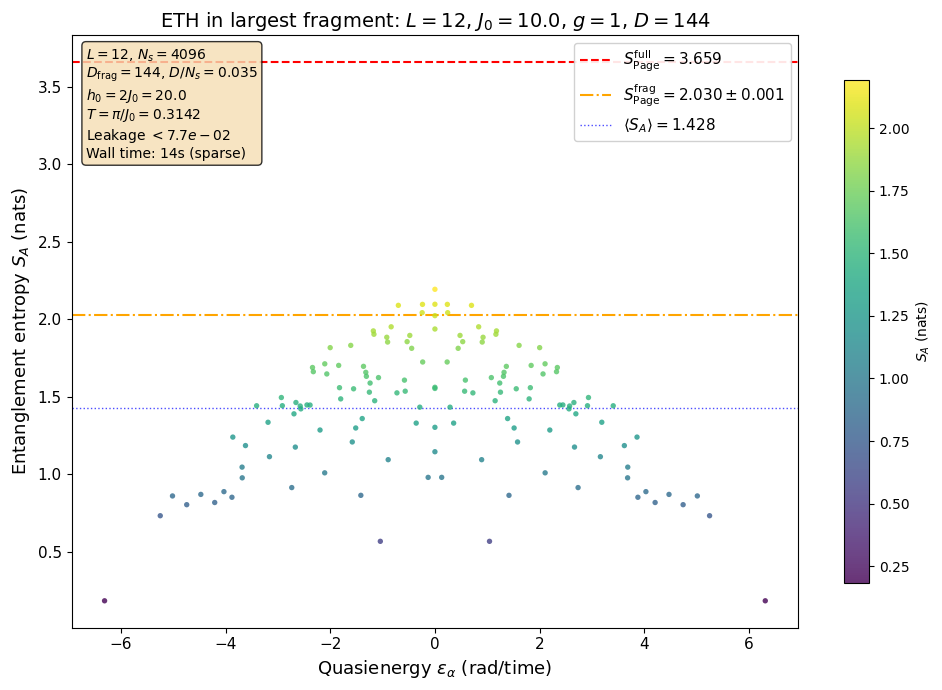

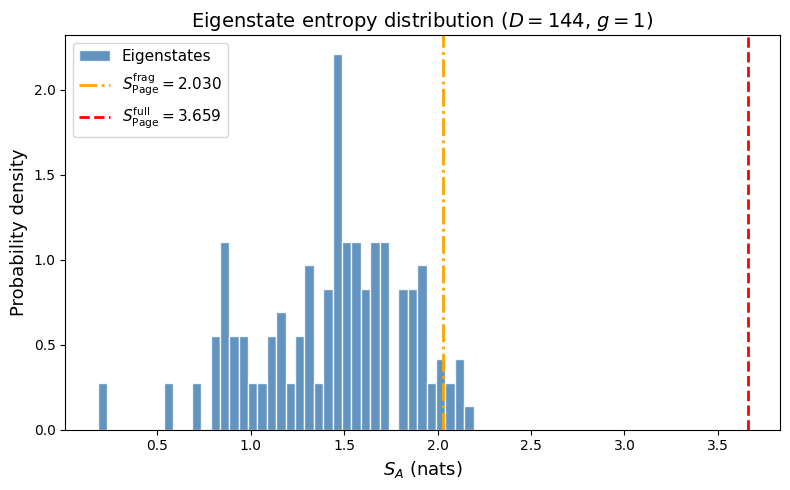

In [ ]:
"""
Entanglement entropy S_A vs. quasienergy epsilon for Floquet eigenstates
in the largest Hilbert space fragment.

ETH diagnostic: in a thermalising fragment, S_A(epsilon) should cluster
near the fragment Page value S_Page^(frag) for mid-spectrum states.

*** SPARSE ONLY — no dense U_F ever formed. ***
Strategy: embed fragment identity into full space, apply one batched
Krylov Floquet step, project back → D×D fragment operator.
Cost: O(K · nnz · D) instead of O(Ns³).

Tunable parameters are collected at the top.
Reuses: snippets/ modules (hamiltonian, evolution, fragment_ops, entropy).
"""

import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# TUNABLE PARAMETERS
# ============================================================
L        = 12       # System size (chain length). L <= 16 feasible.
J0       = 10.0      # Ising coupling strength
h0       = 2.0 * J0 # Longitudinal field (fragmentation: h0 = 2*J0)
g        = 1      # Transverse field (perturbation). g=0 => exact fragments.
n_period = 1        # T = n_period * pi / J0 (fragmentation condition)
seed     = 42       # RNG seed for MC Page value estimation
n_MC     = 1000     # MC samples for fragment Page value

# ============================================================
# STEP 1: IDENTIFY FRAGMENTS
# ============================================================
T  = n_period * np.pi / J0
Ns = 1 << L

print(f"{'='*60}")
print(f"ETH DIAGNOSTIC: S_A vs quasienergy in largest fragment")
print(f"L={L}, J0={J0}, h0={h0}, g={g}, T={T:.6f}")
print(f"Ns = {Ns}")
print(f"{'='*60}")

t_wall_start = time.perf_counter()

O_diag = build_O_operator(L, J0)
adj, num_edges = build_connectivity_graph(L, O_diag)
comps = find_connected_components(adj)
largest = np.array(find_largest_fragment(comps))
D = len(largest)
D_fib = fib(L - 1) + fib(L + 1)

print(f"\nFragment identification:")
print(f"  Total fragments: {len(comps)}")
print(f"  Largest fragment dimension: D = {D}")
print(f"  Fibonacci check: F_{L-1}+F_{L+1} = {D_fib}, "
      f"{'MATCH' if D == D_fib else 'MISMATCH'}")

# ============================================================
# STEP 2: BUILD SPARSE FLOQUET SYSTEM
# ============================================================
ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
ising.build_hamiltonians()

# ============================================================
# STEP 3: BUILD D×D FRAGMENT OPERATOR VIA BATCHED KRYLOV
# ============================================================
# Strategy:
#   1. Build I_frag: Ns × D matrix with (I_frag)_{frag[j], j} = 1
#   2. Apply one Floquet step (batched Krylov): U_F · I_frag → Ns × D
#   3. Project back: extract rows at fragment indices → D × D
#
# This gives U_frag[a,b] = ⟨frag[a]| U_F |frag[b]⟩
# without ever forming the Ns × Ns dense unitary.
#
# Cost: O(K_sub · nnz · D) where K_sub = K+ + K- Krylov sub-steps.
# Memory: O(Ns · D) for the embedding matrix.

print(f"\nBuilding fragment operator via batched Krylov...")
print(f"  Embedding matrix: {Ns} × {D} = {Ns*D*16/1e6:.1f} MB")

t0 = time.perf_counter()

# Embed: D fragment basis vectors into full Hilbert space
I_frag = np.zeros((Ns, D), dtype=np.complex128)
I_frag[largest, np.arange(D)] = 1.0

# Batched Floquet step: expm_multiply handles (Ns, D) natively
# Krylov basis is reused across all D columns → much faster than D serial calls
U_frag_full = apply_floquet_step(ising, I_frag)

# Project back to fragment subspace
U_frag_dense = U_frag_full[largest, :]

t_build = time.perf_counter() - t0
print(f"  Built {D}×{D} fragment operator in {t_build:.2f}s")

# --- Validate ---
unitarity_err = np.linalg.norm(U_frag_dense.conj().T @ U_frag_dense - np.eye(D))
print(f"  Unitarity: ||U†U - I|| = {unitarity_err:.2e}")

# Leakage: total weight escaping fragment across all D basis vectors
total_weight_in_frag = np.sum(np.abs(U_frag_full[largest, :])**2)
total_weight_all     = np.sum(np.abs(U_frag_full)**2)
avg_leakage = 1.0 - total_weight_in_frag / total_weight_all
max_leakage_per_col  = 1.0 - np.sum(np.abs(U_frag_full[largest, :])**2, axis=0).min()
print(f"  Avg leakage per basis state: {avg_leakage:.2e}")
print(f"  Max leakage (worst basis state): {max_leakage_per_col:.2e}")

# Free the large Ns × D matrices
del I_frag, U_frag_full

if unitarity_err > 1e-3:
    print("  WARNING: significant leakage — fragment not well-closed at this g.")

# ============================================================
# STEP 4: DIAGONALISE D×D FRAGMENT OPERATOR
# ============================================================
# D = 322 for L=12 → diagonalising 322×322 is trivial (~0.1s).
# np.linalg.eig is correct here: U_frag is unitary, not Hermitian.

print(f"\nDiagonalising {D}×{D} fragment operator...")
t0 = time.perf_counter()
evals, evecs = np.linalg.eig(U_frag_dense)
t_eig = time.perf_counter() - t0
print(f"  Time: {t_eig:.4f}s")

# Verify eigenvalues on unit circle
radii = np.abs(evals)
print(f"  |eigenvalue| range: [{radii.min():.8f}, {radii.max():.8f}]")

# Quasienergies: U|φ⟩ = e^{-iεT}|φ⟩  ⟹  ε = -arg(λ)/T
quasienergies = -np.angle(evals) / T

# Sort by quasienergy
sort_idx = np.argsort(quasienergies)
quasienergies = quasienergies[sort_idx]
evecs = evecs[:, sort_idx]

print(f"  Quasienergy range: [{quasienergies.min():.4f}, {quasienergies.max():.4f}]")
print(f"  Brillouin zone: [-π/T, π/T] = [{-np.pi/T:.4f}, {np.pi/T:.4f}]")

# ============================================================
# STEP 5: COMPUTE S_A FOR EACH EIGENSTATE
# ============================================================
A_indices = list(range(L // 2))   # left half-chain
L_A = len(A_indices)

print(f"\nComputing S_A for {D} eigenstates...")
print(f"  Subsystem A: sites {A_indices} (L_A = {L_A})")
t0 = time.perf_counter()

entropies = np.zeros(D)
for alpha in range(D):
    # Lift eigenvector from fragment basis to full Hilbert space
    psi_full = np.zeros(Ns, dtype=np.complex128)
    psi_full[largest] = evecs[:, alpha]
    entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)

t_ent = time.perf_counter() - t0
print(f"  Time: {t_ent:.2f}s")
print(f"  S_A range: [{entropies.min():.4f}, {entropies.max():.4f}]")
print(f"  Mean S_A: {entropies.mean():.4f}")

# ============================================================
# STEP 6: REFERENCE VALUES — Page values
# ============================================================
S_page_full = compute_page_value(L)

S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
    largest, L, n_samples=n_MC, seed=seed, verbose=False
)

print(f"\nReference Page values:")
print(f"  S_Page (full Hilbert space): {S_page_full:.6f}")
print(f"  S_Page (fragment, MC): {S_page_frag:.6f} ± {S_sem_frag:.6f}")

t_wall_total = time.perf_counter() - t_wall_start
print(f"\nTotal wall time: {t_wall_total:.1f}s")
print(f"  (Fragment operator: {t_build:.1f}s, Eigensolver: {t_eig:.2f}s, "
      f"Entropies: {t_ent:.1f}s)")

# ============================================================
# STEP 7: PLOT — S_A vs quasienergy
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Scatter: S_A vs quasienergy
scatter = ax.scatter(
    quasienergies, entropies,
    c=entropies, cmap='viridis', s=15, alpha=0.8,
    edgecolors='none', zorder=2
)
cbar = fig.colorbar(scatter, ax=ax, label=r'$S_A$ (nats)', shrink=0.85)

# Page value lines
ax.axhline(S_page_full, color='red', ls='--', lw=1.5,
           label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}} = {S_page_full:.3f}$',
           zorder=1)
ax.axhline(S_page_frag, color='orange', ls='-.', lw=1.5,
           label=(rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{frag}}}} = {S_page_frag:.3f}'
                  rf'\pm {S_sem_frag:.3f}$'),
           zorder=1)

# Mean entropy line
S_mean = entropies.mean()
ax.axhline(S_mean, color='blue', ls=':', lw=1.0, alpha=0.7,
           label=rf'$\langle S_A \rangle = {S_mean:.3f}$', zorder=1)

# Labels and formatting
ax.set_xlabel(r'Quasienergy $\varepsilon_\alpha$ (rad/time)', fontsize=13)
ax.set_ylabel(r'Entanglement entropy $S_A$ (nats)', fontsize=13)
ax.set_title(
    rf'ETH in largest fragment: $L={L}$, $J_0={J0}$, $g={g}$, $D={D}$',
    fontsize=14
)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.tick_params(labelsize=11)

# Annotation box
textstr = (
    rf'$L = {L}$, $N_s = {Ns}$' '\n'
    rf'$D_{{\mathrm{{frag}}}} = {D}$, '
    rf'$D/N_s = {D/Ns:.3f}$' '\n'
    rf'$h_0 = 2J_0 = {h0}$' '\n'
    rf'$T = \pi/J_0 = {T:.4f}$' '\n'
    rf'Leakage $< {max_leakage_per_col:.1e}$' '\n'
    rf'Wall time: {t_wall_total:.0f}s (sparse)'
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

fig.tight_layout()
plt.show()

# ============================================================
# BONUS: HISTOGRAM OF S_A
# ============================================================
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.hist(entropies, bins=40, density=True, color='steelblue',
         edgecolor='white', alpha=0.85, label='Eigenstates')
ax2.axvline(S_page_frag, color='orange', ls='-.', lw=2,
            label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{frag}}}} = {S_page_frag:.3f}$')
ax2.axvline(S_page_full, color='red', ls='--', lw=2,
            label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}} = {S_page_full:.3f}$')
ax2.set_xlabel(r'$S_A$ (nats)', fontsize=13)
ax2.set_ylabel('Probability density', fontsize=13)
ax2.set_title(rf'Eigenstate entropy distribution ($D={D}$, $g={g}$)', fontsize=14)
ax2.legend(fontsize=11)
fig2.tight_layout()
plt.show()

MAGNETISATION DYNAMICS: lowest-entropy Floquet eigenstates
L=8, J0=10.0, h0=20.0, g=1.0, T=0.628319
Ns = 256

  Fragments: 114, largest D = 21, Fibonacci MISMATCH
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 74.77, ||A-||_1 = 74.77
  Krylov sub-steps: K+ = 15, K- = 15
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 9.25e-13

Building 21×21 fragment operator via batched Krylov...
  Time: 0.58s, ||U†U-I|| = 1.08e-03, leakage = 2.81e-04

  2 lowest-entropy eigenstates:
    #0: S_A = 0.1980, ε = 3.8892
    #1: S_A = 0.1980, ε = -3.8892

  Evolving 200 Floquet steps...
    State #0: 12.9s (15 steps/s), ||ψ|| = 1.00000000
    Sta

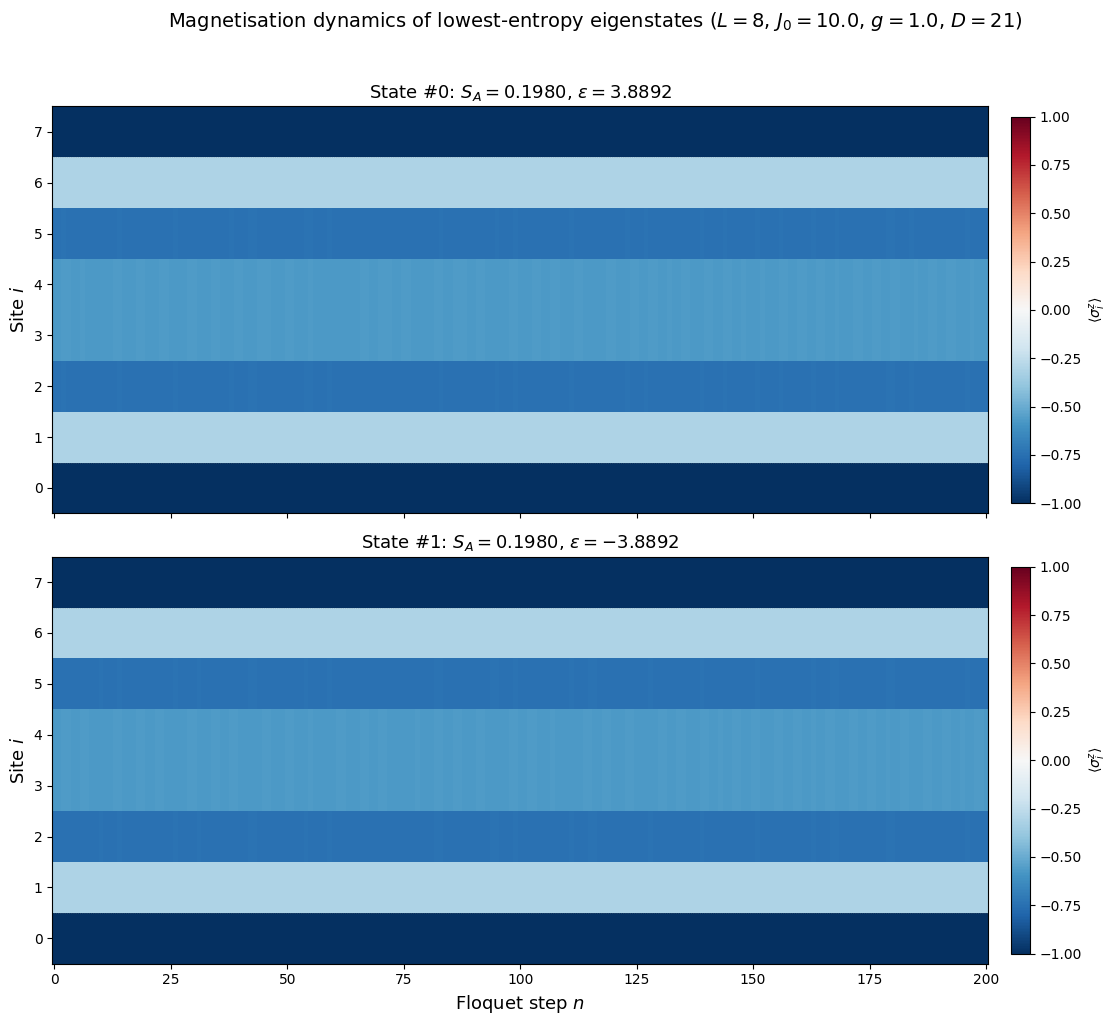

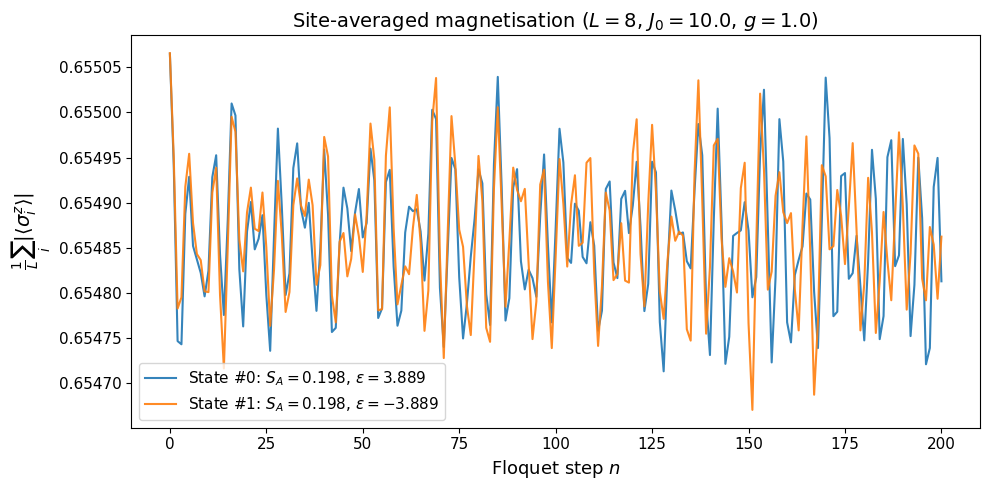

In [ ]:
"""
Spatiotemporal magnetisation contour plot for the two lowest-entangled
Floquet eigenstates in the largest Hilbert space fragment.

Plots <σ^z_i>(n) as a function of site i and Floquet step n.

*** SPARSE ONLY — no dense U_F ever formed. ***
Reuses the eigenstate analysis from the S_A vs ε code.

Tunable parameters are collected at the top.
Reuses: snippets/ modules (hamiltonian, evolution, fragment_ops, entropy).
"""

import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ============================================================
# TUNABLE PARAMETERS
# ============================================================
L              = 8        # System size (chain length)
J0             = 10.0     # Ising coupling strength
h0             = 2.0 * J0 # Longitudinal field (fragmentation: h0 = 2*J0)
g              = 1.0      # Transverse field (perturbation)
n_period       = 2        # T = n_period * pi / J0
seed           = 42       # RNG seed for MC Page value
n_MC           = 1000     # MC samples for fragment Page value
n_periods_evol = 200      # Floquet steps to evolve
n_lowest       = 2        # Number of lowest-entropy eigenstates to plot

# ============================================================
# HELPER: DIAGONAL <σ^z_i> FOR ALL SITES
# ============================================================
def compute_sz_all_sites(psi, L):
    """Compute <σ^z_i> for sites i = 0, ..., L-1.

    σ^z is diagonal in the computational basis:
        <ψ|σ^z_i|ψ> = Σ_n |c_n|² (1 - 2·bit_i(n))

    Convention: site i ↔ bit position (L-1-i).
    Cost: O(L · Ns) — no matrix operations.
    """
    Ns = 1 << L
    probs = np.abs(psi)**2
    states = np.arange(Ns, dtype=np.int64)
    sz = np.zeros(L, dtype=np.float64)
    for i in range(L):
        bit_pos = L - 1 - i
        bits = (states >> bit_pos) & 1
        sz_vals = 1.0 - 2.0 * bits
        sz[i] = np.dot(probs, sz_vals)
    return sz

# ============================================================
# STEP 1: IDENTIFY FRAGMENTS
# ============================================================
T  = n_period * np.pi / J0
Ns = 1 << L

print(f"{'='*60}")
print(f"MAGNETISATION DYNAMICS: lowest-entropy Floquet eigenstates")
print(f"L={L}, J0={J0}, h0={h0}, g={g}, T={T:.6f}")
print(f"Ns = {Ns}")
print(f"{'='*60}")

t_wall_start = time.perf_counter()

O_diag = build_O_operator(L, J0)
adj, _ = build_connectivity_graph(L, O_diag)
comps = find_connected_components(adj)
largest = np.array(find_largest_fragment(comps))
D = len(largest)

print(f"\n  Fragments: {len(comps)}, largest D = {D}, "
      f"Fibonacci {'MATCH' if D == fib(L-1)+fib(L+1) else 'MISMATCH'}")

# ============================================================
# STEP 2: BUILD SPARSE FLOQUET SYSTEM
# ============================================================
ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
ising.build_hamiltonians()

# ============================================================
# STEP 3: BUILD D×D FRAGMENT OPERATOR VIA BATCHED KRYLOV
# ============================================================
print(f"\nBuilding {D}×{D} fragment operator via batched Krylov...")
t0 = time.perf_counter()

I_frag = np.zeros((Ns, D), dtype=np.complex128)
I_frag[largest, np.arange(D)] = 1.0
U_frag_full = apply_floquet_step(ising, I_frag)
U_frag_dense = U_frag_full[largest, :]

unitarity_err = np.linalg.norm(U_frag_dense.conj().T @ U_frag_dense - np.eye(D))
max_leakage = 1.0 - np.sum(np.abs(U_frag_full[largest, :])**2, axis=0).min()
del I_frag, U_frag_full

t_build = time.perf_counter() - t0
print(f"  Time: {t_build:.2f}s, ||U†U-I|| = {unitarity_err:.2e}, "
      f"leakage = {max_leakage:.2e}")

# ============================================================
# STEP 4: DIAGONALISE → QUASIENERGIES + ENTROPIES
# ============================================================
evals, evecs = np.linalg.eig(U_frag_dense)
quasienergies = -np.angle(evals) / T
sort_idx = np.argsort(quasienergies)
quasienergies = quasienergies[sort_idx]
evecs = evecs[:, sort_idx]

A_indices = list(range(L // 2))
entropies = np.zeros(D)
for alpha in range(D):
    psi_full = np.zeros(Ns, dtype=np.complex128)
    psi_full[largest] = evecs[:, alpha]
    entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)

S_page_full = compute_page_value(L)
S_page_frag, _, _ = compute_fragment_page_value_MC(
    largest, L, n_samples=n_MC, seed=seed, verbose=False)

# ============================================================
# STEP 5: SELECT LOWEST-ENTROPY EIGENSTATES
# ============================================================
low_idx = np.argsort(entropies)[:n_lowest]
print(f"\n  {n_lowest} lowest-entropy eigenstates:")
for rank, idx in enumerate(low_idx):
    print(f"    #{rank}: S_A = {entropies[idx]:.4f}, "
          f"ε = {quasienergies[idx]:.4f}")

# ============================================================
# STEP 6: EVOLVE AND RECORD MAGNETISATION
# ============================================================
# sz_data[rank, n, i] = <σ^z_i> at Floquet step n for state #rank
sz_data = np.zeros((n_lowest, n_periods_evol + 1, L), dtype=np.float64)

print(f"\n  Evolving {n_periods_evol} Floquet steps...")
for rank, eig_idx in enumerate(low_idx):
    # Lift eigenstate to full Hilbert space
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[largest] = evecs[:, eig_idx]

    sz_data[rank, 0, :] = compute_sz_all_sites(psi, L)

    t0 = time.perf_counter()
    for n in range(1, n_periods_evol + 1):
        psi = apply_floquet_step(ising, psi)
        sz_data[rank, n, :] = compute_sz_all_sites(psi, L)

    elapsed = time.perf_counter() - t0
    norm_final = np.linalg.norm(psi)
    print(f"    State #{rank}: {elapsed:.1f}s "
          f"({n_periods_evol/elapsed:.0f} steps/s), "
          f"||ψ|| = {norm_final:.8f}")

t_wall_total = time.perf_counter() - t_wall_start
print(f"\n  Total wall time: {t_wall_total:.1f}s")

# ============================================================
# STEP 7: CONTOUR PLOTS
# ============================================================
steps_arr = np.arange(n_periods_evol + 1)
sites_arr = np.arange(L)

# Use diverging colourmap centred at 0: blue (↓) — white (0) — red (↑)
vmax_global = np.max(np.abs(sz_data))
norm_div = TwoSlopeNorm(vmin=-vmax_global, vcenter=0, vmax=vmax_global)

fig, axes = plt.subplots(n_lowest, 1, figsize=(12, 5 * n_lowest),
                         sharex=True, sharey=True)
if n_lowest == 1:
    axes = [axes]

for rank, (ax, eig_idx) in enumerate(zip(axes, low_idx)):
    # sz_data[rank] has shape (n_periods+1, L) — transpose so
    # x-axis = Floquet step, y-axis = site index
    im = ax.pcolormesh(
        steps_arr, sites_arr, sz_data[rank].T,
        cmap='RdBu_r', norm=norm_div, shading='auto'
    )

    cbar = fig.colorbar(im, ax=ax, label=r'$\langle\sigma^z_i\rangle$',
                        shrink=0.95, pad=0.02)

    ax.set_ylabel(r'Site $i$', fontsize=13)
    ax.set_title(
        rf'State #{rank}: $S_A = {entropies[eig_idx]:.4f}$, '
        rf'$\varepsilon = {quasienergies[eig_idx]:.4f}$',
        fontsize=13
    )
    ax.set_yticks(sites_arr)

    # Mark edge sites
    ax.axhline(0.5, color='grey', ls=':', lw=0.5, alpha=0.5)
    ax.axhline(L - 1.5, color='grey', ls=':', lw=0.5, alpha=0.5)

axes[-1].set_xlabel(r'Floquet step $n$', fontsize=13)

fig.suptitle(
    rf'Magnetisation dynamics of lowest-entropy eigenstates '
    rf'($L={L}$, $J_0={J0}$, $g={g}$, $D={D}$)',
    fontsize=14, y=1.02
)
fig.tight_layout()
plt.show()

# ============================================================
# BONUS: SITE-AVERAGED MAGNETISATION vs TIME
# ============================================================
fig3, ax3 = plt.subplots(1, 1, figsize=(10, 5))

for rank, eig_idx in enumerate(low_idx):
    # Site-averaged |<sz>| as a proxy for order
    sz_avg = np.mean(np.abs(sz_data[rank]), axis=1)  # average over sites
    ax3.plot(steps_arr, sz_avg,
             label=(rf'State #{rank}: $S_A = {entropies[eig_idx]:.3f}$, '
                    rf'$\varepsilon = {quasienergies[eig_idx]:.3f}$'),
             lw=1.5, alpha=0.9)

ax3.set_xlabel(r'Floquet step $n$', fontsize=13)
ax3.set_ylabel(r'$\frac{1}{L}\sum_i |\langle\sigma^z_i\rangle|$', fontsize=14)
ax3.set_title(
    rf'Site-averaged magnetisation ($L={L}$, $J_0={J0}$, $g={g}$)',
    fontsize=14
)
ax3.legend(fontsize=11)
ax3.tick_params(labelsize=11)
fig3.tight_layout()
plt.show()

MAGNETISATION DYNAMICS: most-polarised basis states
L=8, J0=10.0, h0=20.0, g=1.0, T=0.628319
Ns = 256

  Fragments: 114, largest D = 21, Fibonacci MISMATCH
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 74.77, ||A-||_1 = 74.77
  Krylov sub-steps: K+ = 15, K- = 15
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 9.25e-13

  Selected 2 most-polarised basis states:
    #0: |255⟩ = |11111111⟩ = ↓↓↓↓↓↓↓↓,  M = -8
    #1: |191⟩ = |10111111⟩ = ↓↑↓↓↓↓↓↓,  M = -6

  Evolving 200 Floquet steps...
    State #0 (M=-8): 14.2s (14 steps/s), ||ψ|| = 1.00000000
    State #1 (M=-6): 8.0s (25 steps/s), ||ψ|| = 1.00000000

  Total wall time: 22.

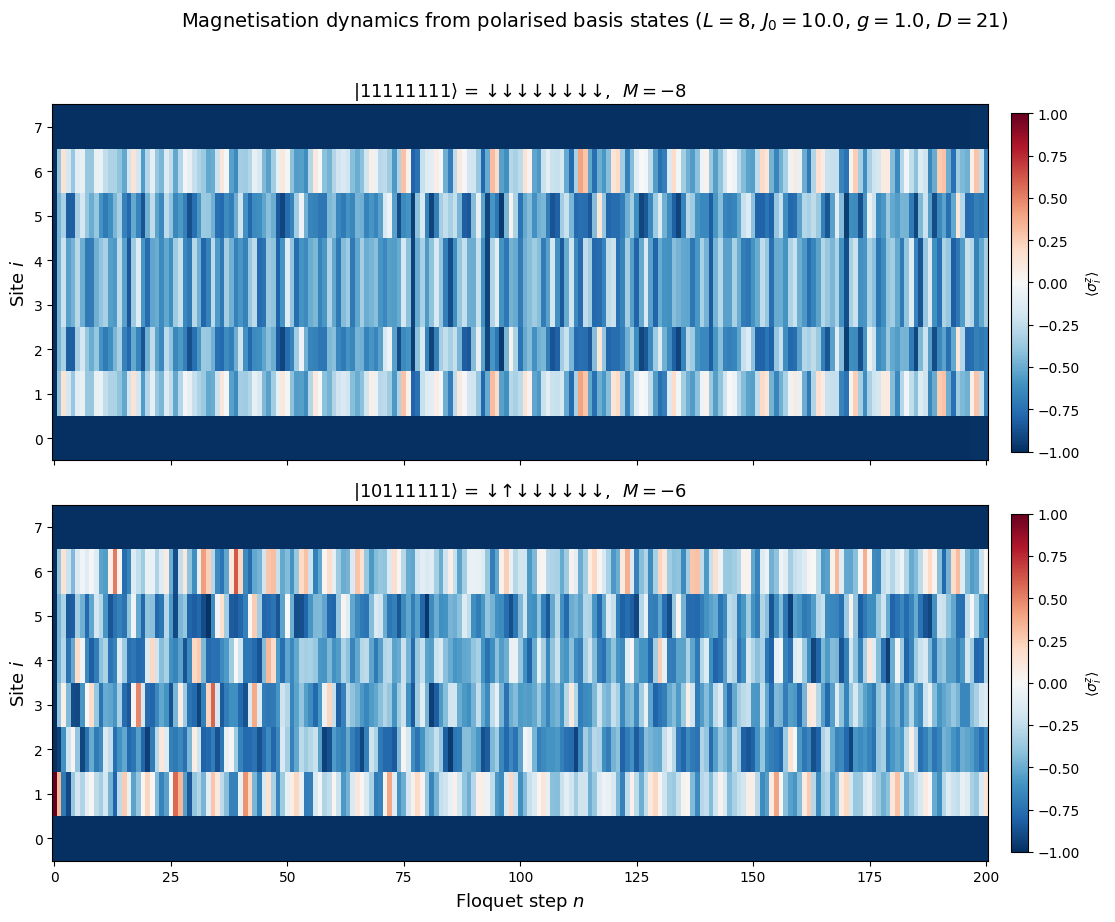

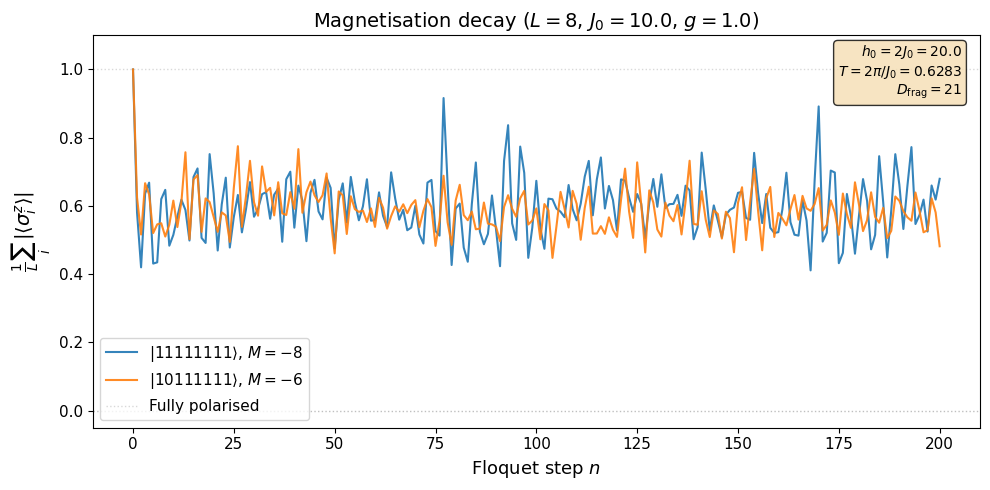

In [ ]:


import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ============================================================
# TUNABLE PARAMETERS
# ============================================================
L              = 8        # System size (chain length)
J0             = 10.0     # Ising coupling strength
h0             = 2.0 * J0 # Longitudinal field (fragmentation: h0 = 2*J0)
g              = 1.0      # Transverse field (perturbation)
n_period       = 2        # T = n_period * pi / J0
n_periods_evol = 200      # Floquet steps to evolve
n_states_plot  = 2        # Number of most-polarised states to plot


# ============================================================
# HELPER: DIAGONAL <σ^z_i> FOR ALL SITES
# ============================================================
def compute_sz_all_sites(psi, L):
    """Compute <σ^z_i> for sites i = 0, ..., L-1.

    σ^z is diagonal in the computational basis:
        <ψ|σ^z_i|ψ> = Σ_n |c_n|² (1 - 2·bit_i(n))

    Convention: site i ↔ bit position (L-1-i).
    Cost: O(L · Ns) — no matrix operations.
    """
    Ns = 1 << L
    probs = np.abs(psi)**2
    states = np.arange(Ns, dtype=np.int64)
    sz = np.zeros(L, dtype=np.float64)
    for i in range(L):
        bit_pos = L - 1 - i
        bits = (states >> bit_pos) & 1
        sz_vals = 1.0 - 2.0 * bits
        sz[i] = np.dot(probs, sz_vals)
    return sz


def total_magnetisation(state_idx, L):
    """Compute M = Σ_i σ^z_i for a computational basis state."""
    M = 0
    for i in range(L):
        bit = (state_idx >> (L - 1 - i)) & 1
        M += 1 - 2 * bit
    return M

# ============================================================
# STEP 1: IDENTIFY FRAGMENTS
# ============================================================
T  = n_period * np.pi / J0
Ns = 1 << L

print(f"{'='*60}")
print(f"MAGNETISATION DYNAMICS: most-polarised basis states")
print(f"L={L}, J0={J0}, h0={h0}, g={g}, T={T:.6f}")
print(f"Ns = {Ns}")
print(f"{'='*60}")

t_wall_start = time.perf_counter()

O_diag = build_O_operator(L, J0)
adj, _ = build_connectivity_graph(L, O_diag)
comps = find_connected_components(adj)
largest = np.array(find_largest_fragment(comps))
D = len(largest)

print(f"\n  Fragments: {len(comps)}, largest D = {D}, "
      f"Fibonacci {'MATCH' if D == fib(L-1)+fib(L+1) else 'MISMATCH'}")

# ============================================================
# STEP 2: BUILD SPARSE FLOQUET SYSTEM
# ============================================================
ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
ising.build_hamiltonians()

# ============================================================
# STEP 3: SELECT MOST-POLARISED BASIS STATES
# ============================================================
mags = np.array([total_magnetisation(s, L) for s in largest])
abs_mags = np.abs(mags)
order = np.argsort(-abs_mags)  # descending |M|

# Pick the top n_states_plot, breaking ties by taking distinct |M| where possible
selected_indices = []       # indices into 'largest' array
selected_state_ids = []     # actual basis state integers
selected_M = []

seen_abs_M = set()
for i in order:
    am = abs_mags[i]
    if len(selected_indices) < n_states_plot:
        selected_indices.append(i)
        selected_state_ids.append(largest[i])
        selected_M.append(mags[i])
        seen_abs_M.add(am)
    if len(selected_indices) == n_states_plot:
        break

print(f"\n  Selected {n_states_plot} most-polarised basis states:")
for rank in range(n_states_plot):
    s = selected_state_ids[rank]
    M = selected_M[rank]
    bits = format(s, f'0{L}b')
    spins = ''.join('↓' if b == '1' else '↑' for b in bits)
    print(f"    #{rank}: |{s}⟩ = |{bits}⟩ = {spins},  M = {M:+d}")

# ============================================================
# STEP 4: EVOLVE AND RECORD MAGNETISATION
# ============================================================
# sz_data[rank, n, i] = <σ^z_i> at Floquet step n
sz_data = np.zeros((n_states_plot, n_periods_evol + 1, L), dtype=np.float64)

print(f"\n  Evolving {n_periods_evol} Floquet steps...")
for rank in range(n_states_plot):
    s = selected_state_ids[rank]

    # Prepare computational basis state |s⟩
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[s] = 1.0

    # Step 0: sharp ±1 magnetisation
    sz_data[rank, 0, :] = compute_sz_all_sites(psi, L)

    t0 = time.perf_counter()
    for n in range(1, n_periods_evol + 1):
        psi = apply_floquet_step(ising, psi)
        sz_data[rank, n, :] = compute_sz_all_sites(psi, L)

    elapsed = time.perf_counter() - t0
    norm_final = np.linalg.norm(psi)
    print(f"    State #{rank} (M={selected_M[rank]:+d}): "
          f"{elapsed:.1f}s ({n_periods_evol/elapsed:.0f} steps/s), "
          f"||ψ|| = {norm_final:.8f}")

t_wall_total = time.perf_counter() - t_wall_start
print(f"\n  Total wall time: {t_wall_total:.1f}s")

# ============================================================
# STEP 5: CONTOUR PLOTS
# ============================================================
steps_arr = np.arange(n_periods_evol + 1)
sites_arr = np.arange(L)

# Diverging colourmap centred at 0: blue (↓) — white (0) — red (↑)
norm_div = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(n_states_plot, 1,
                         figsize=(12, 4.5 * n_states_plot),
                         sharex=True, sharey=True)
if n_states_plot == 1:
    axes = [axes]

for rank, ax in enumerate(axes):
    s = selected_state_ids[rank]
    M = selected_M[rank]
    bits = format(s, f'0{L}b')
    spins = ''.join('↓' if b == '1' else '↑' for b in bits)

    im = ax.pcolormesh(
        steps_arr, sites_arr, sz_data[rank].T,
        cmap='RdBu_r', norm=norm_div, shading='auto'
    )

    cbar = fig.colorbar(im, ax=ax, label=r'$\langle\sigma^z_i\rangle$',
                        shrink=0.95, pad=0.02)

    ax.set_ylabel(r'Site $i$', fontsize=13)
    ax.set_title(
        rf'$|{bits}\rangle$ = {spins},  $M = {M:+d}$',
        fontsize=13
    )
    ax.set_yticks(sites_arr)

axes[-1].set_xlabel(r'Floquet step $n$', fontsize=13)

fig.suptitle(
    rf'Magnetisation dynamics from polarised basis states '
    rf'($L={L}$, $J_0={J0}$, $g={g}$, $D={D}$)',
    fontsize=14, y=1.02
)
fig.tight_layout()
plt.show()

# ============================================================
# BONUS: SITE-AVERAGED |MAGNETISATION| vs TIME
# ============================================================
fig3, ax3 = plt.subplots(1, 1, figsize=(10, 5))

for rank in range(n_states_plot):
    s = selected_state_ids[rank]
    M = selected_M[rank]
    bits = format(s, f'0{L}b')

    # Site-averaged |<sz>|: measures how much spin order survives
    sz_avg = np.mean(np.abs(sz_data[rank]), axis=1)
    ax3.plot(steps_arr, sz_avg,
             label=rf'$|{bits}\rangle$, $M={M:+d}$',
             lw=1.5, alpha=0.9)

# Diagonal ensemble prediction: long-time average should plateau
# Mark the infinite-temperature value: <|sz|> → 0 for fully thermalised
ax3.axhline(0, color='grey', ls=':', lw=1, alpha=0.5)
ax3.axhline(1, color='grey', ls=':', lw=1, alpha=0.3,
            label=r'Fully polarised')

ax3.set_xlabel(r'Floquet step $n$', fontsize=13)
ax3.set_ylabel(
    r'$\frac{1}{L}\sum_i \,|\langle\sigma^z_i\rangle|$', fontsize=14
)
ax3.set_title(
    rf'Magnetisation decay ($L={L}$, $J_0={J0}$, $g={g}$)',
    fontsize=14
)
ax3.legend(fontsize=11)
ax3.set_ylim(-0.05, 1.1)
ax3.tick_params(labelsize=11)

# Annotation
textstr = (
    rf'$h_0 = 2J_0 = {h0}$' '\n'
    rf'$T = 2\pi/J_0 = {T:.4f}$' '\n'
    rf'$D_{{\mathrm{{frag}}}} = {D}$'
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax3.text(0.98, 0.98, textstr, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

fig3.tight_layout()
plt.show()

#EE for a general partition



## Edge EE random pure state

PROMPT 2: Edge-Site Entropy Dynamics — Self-Tests + Run

------------------------------------------------------------------------
TEST 1: Page value for L_A = 1
------------------------------------------------------------------------
  L= 6: S_Page = 0.66189718,  ln2 - 1/2^5 = 0.66189718,  err = 0.00e+00
  L= 8: S_Page = 0.68533468,  ln2 - 1/2^7 = 0.68533468,  err = 0.00e+00
  L=10: S_Page = 0.69119406,  ln2 - 1/2^9 = 0.69119406,  err = 0.00e+00
  L=12: S_Page = 0.69265890,  ln2 - 1/2^11 = 0.69265890,  err = 0.00e+00
  PASS: generalised Page value correct for L_A = 1

------------------------------------------------------------------------
TEST 2: S_A(0) = 0 for product states, A = {site 0}
------------------------------------------------------------------------
  max|S_A(0)| over 20 product states = 8.88e-16
  PASS: product states have zero edge-site entanglement

------------------------------------------------------------------------
TEST 3: Right-edge entropy (non-contiguous A path

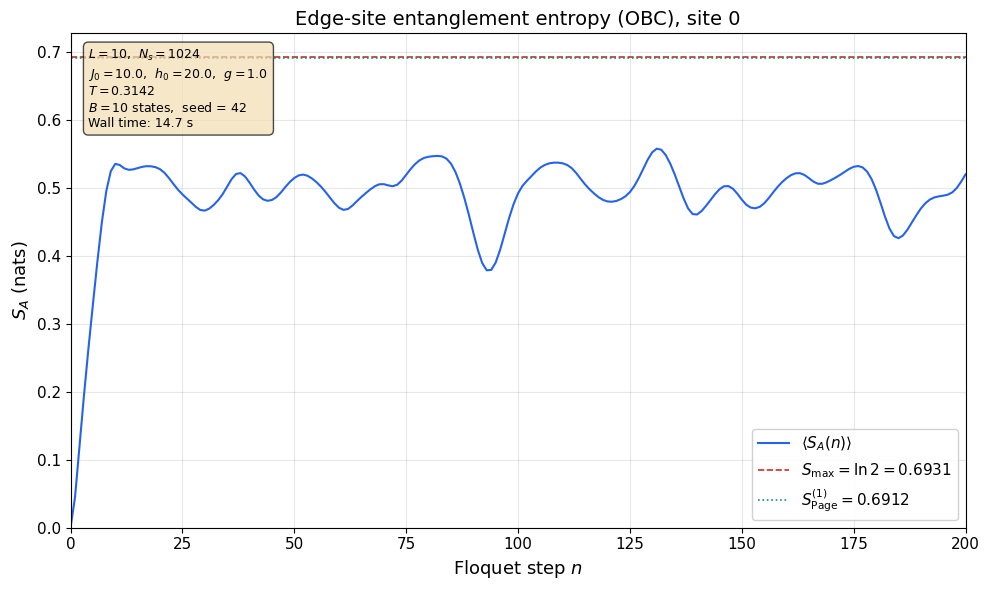

In [ ]:
# ============================================================
# NEW: Page value for arbitrary L_A (generalised)
# ============================================================

def compute_page_value_general(L, L_A):
    """
    Page value S_Page ≈ ln(m) - m/(2n)  for arbitrary bipartition.

    m = min(2^L_A, 2^L_B),  n = max(2^L_A, 2^L_B).
    For L_A = 1:  S_Page = ln(2) - 1/2^{L-1}.
    """
    L_B = L - L_A
    dim_A = 1 << L_A
    dim_B = 1 << L_B
    m = min(dim_A, dim_B)
    n = max(dim_A, dim_B)
    return np.log(m) - m / (2.0 * n)


# ============================================================
# CORE COMPUTATION: Edge-site entropy dynamics
# ============================================================

def compute_edge_entropy_dynamics(L, J_0, h_0, g, TP, n_steps, n_states,
                                   edge_site=0, seed=42,
                                   renorm_interval=100, verbose=True):
    """
    Compute S_A(n) where A = {edge_site} under Floquet evolution (OBC).

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling.
    h_0 : float
        Longitudinal field.
    g : float
        Transverse field (perturbation).
    TP : float
        Floquet period T.
    n_steps : int
        Number of Floquet periods.
    n_states : int
        Number of random product states to average (B).
    edge_site : int
        Which site defines subsystem A (0 = left edge, L-1 = right edge).
    seed : int
        RNG seed.
    renorm_interval : int
        Renormalise every N steps (0 to disable).
    verbose : bool
        Print progress.

    Returns
    -------
    results : dict
        steps, S_avg, S_page, S_max, params, wall_time.
    """
    assert 0 <= edge_site < L, f"edge_site={edge_site} out of range [0, {L-1}]"

    A_indices = [edge_site]
    S_page = compute_page_value_general(L, L_A=1)
    S_max = np.log(2)

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"EDGE-SITE ENTROPY DYNAMICS (OBC)")
        print(f"{'=' * 60}")
        print(f"  L = {L},  N_s = {1 << L}")
        print(f"  J_0 = {J_0},  h_0 = {h_0},  g = {g}")
        print(f"  T = {TP:.6f}")
        print(f"  Subsystem A = site {edge_site}")
        print(f"  n_steps = {n_steps},  n_states = {n_states}")
        print(f"  S_Page (1-site) = {S_page:.6f} nats")
        print(f"  S_max = ln(2) = {S_max:.6f} nats")

    t0 = time.perf_counter()

    # --- Build system ---
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    if verbose:
        print(f"  Krylov sub-steps: K+ = {ising.K_plus}, K- = {ising.K_minus}")

    # --- Build initial states ---
    rng = np.random.default_rng(seed)
    Psi = build_product_states_batched(L, n_states, rng)

    # --- Allocate entropy accumulator ---
    S_avg = np.zeros(n_steps + 1, dtype=np.float64)

    # Step 0: entropy of product states (should be ~0)
    for k in range(n_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_states
        print(f"  S(0) = {S0:.2e} (should be ~0 for product states)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_steps + 1):
        Psi = apply_floquet_step(ising, Psi)

        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        for k in range(n_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        if verbose and (n % max(1, n_steps // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_cur = S_avg[n] / n_states
            rate = n / elapsed if elapsed > 0 else 0
            eta = (n_steps - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_steps}: S = {S_cur:.4f} "
                  f"({S_cur/S_max:.3f} S_max), "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    S_avg /= n_states
    steps = np.arange(n_steps + 1)
    wall = time.perf_counter() - t0

    if verbose:
        print(f"\n  Final: S({n_steps}) = {S_avg[-1]:.6f}")
        print(f"  S / S_max = {S_avg[-1] / S_max:.4f}")
        print(f"  S / S_Page = {S_avg[-1] / S_page:.4f}")
        print(f"  Max norm drift: {max_norm_drift:.2e}")
        print(f"  Wall time: {wall:.1f} s")

    return {
        'steps': steps,
        'S_avg': S_avg,
        'S_page': S_page,
        'S_max': S_max,
        'params': {
            'L': L, 'J_0': J_0, 'h_0': h_0, 'g': g, 'T': TP,
            'edge_site': edge_site, 'n_states': n_states,
            'n_steps': n_steps, 'seed': seed,
        },
        'wall_time': wall,
    }


# ============================================================
# PLOTTING
# ============================================================

def plot_edge_entropy(results, save_path=None, show=True):
    """
    Publication-quality plot of edge-site entanglement entropy dynamics.

    Parameters
    ----------
    results : dict
        Output from compute_edge_entropy_dynamics.
    save_path : str or None
        If given, save figure to this path.
    show : bool
        Whether to call plt.show().
    """
    steps = results['steps']
    S_avg = results['S_avg']
    S_page = results['S_page']
    S_max = results['S_max']
    p = results['params']

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # --- Entropy curve ---
    ax.plot(steps, S_avg, '-', color='#2563EB', linewidth=1.5,
            label=r'$\langle S_A(n) \rangle$')

    # --- Reference lines ---
    ax.axhline(S_max, color='#DC2626', linestyle='--', linewidth=1.2,
               label=rf'$S_{{\max}} = \ln 2 = {S_max:.4f}$')
    ax.axhline(S_page, color='#059669', linestyle=':', linewidth=1.2,
               label=rf'$S_{{\mathrm{{Page}}}}^{{(1)}} = {S_page:.4f}$')

    # --- Labels ---
    ax.set_xlabel('Floquet step $n$', fontsize=13)
    ax.set_ylabel(r'$S_A$ (nats)', fontsize=13)
    ax.set_title(
        rf'Edge-site entanglement entropy (OBC), '
        rf'site {p["edge_site"]}',
        fontsize=14
    )

    ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
    ax.set_xlim(0, steps[-1])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

    # --- Parameter annotation ---
    param_text = (
        f'$L = {p["L"]}$,  $N_s = {1 << p["L"]}$\n'
        f'$J_0 = {p["J_0"]}$,  $h_0 = {p["h_0"]}$,  '
        f'$g = {p["g"]}$\n'
        f'$T = {p["T"]:.4f}$\n'
        f'$B = {p["n_states"]}$ states,  '
        f'seed = {p["seed"]}\n'
        f'Wall time: {results["wall_time"]:.1f} s'
    )
    ax.text(0.02, 0.97, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat',
                      alpha=0.7))

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Figure saved to: {save_path}")

    if show:
        plt.show()

    return fig, ax


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 2: Edge-Site Entropy Dynamics — Self-Tests + Run")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Page value for 1-site cut
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Page value for L_A = 1")
    print("-" * 72)

    for L_test in [6, 8, 10, 12]:
        S_p = compute_page_value_general(L_test, L_A=1)
        S_exact = np.log(2) - 1.0 / (2**(L_test - 1))
        err = abs(S_p - S_exact)
        print(f"  L={L_test:2d}: S_Page = {S_p:.8f},  "
              f"ln2 - 1/2^{L_test-1} = {S_exact:.8f},  err = {err:.2e}")
        assert err < 1e-15, f"Page value mismatch at L={L_test}"
    print("  PASS: generalised Page value correct for L_A = 1")

    # ----------------------------------------------------------
    # TEST 2: Initial entropy = 0 for product states
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: S_A(0) = 0 for product states, A = {site 0}")
    print("-" * 72)

    L_test = 8
    rng_test = np.random.default_rng(123)
    Psi_test = build_product_states_batched(L_test, 20, rng_test)
    max_S0 = 0.0
    for k in range(20):
        S0 = bipartite_entropy(Psi_test[:, k], L_test, [0])
        max_S0 = max(max_S0, abs(S0))
    print(f"  max|S_A(0)| over 20 product states = {max_S0:.2e}")
    assert max_S0 < 1e-12, f"Initial entropy not zero: {max_S0}"
    print("  PASS: product states have zero edge-site entanglement")

    # ----------------------------------------------------------
    # TEST 3: General-path entropy for non-contiguous A
    #   A = {site L-1} (right edge) uses the transpose path.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Right-edge entropy (non-contiguous A path)")
    print("-" * 72)

    L_test = 6
    rng_test = np.random.default_rng(456)
    # Haar-random state (should have S ≈ ln2 - 1/2^5 ≈ 0.662)
    z = rng_test.standard_normal(1 << L_test) + 1j * rng_test.standard_normal(1 << L_test)
    z /= np.linalg.norm(z)

    S_left  = bipartite_entropy(z, L_test, [0])
    S_right = bipartite_entropy(z, L_test, [L_test - 1])
    S_page_1 = compute_page_value_general(L_test, 1)

    print(f"  Haar state: S(site 0) = {S_left:.6f}")
    print(f"  Haar state: S(site {L_test-1}) = {S_right:.6f}")
    print(f"  S_Page^(1) = {S_page_1:.6f}")
    # Both should be close to S_Page for a Haar state
    assert abs(S_left - S_page_1) < 0.3, "Left edge entropy too far from Page"
    assert abs(S_right - S_page_1) < 0.3, "Right edge entropy too far from Page"
    print("  PASS: both edge entropies reasonable for Haar state")

    # ----------------------------------------------------------
    # PRODUCTION RUN
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("PRODUCTION RUN: L=10, 200 steps, 10 states")
    print("-" * 72)

    # ====== TUNABLE PARAMETERS ======
    L       = 10        # chain length
    J_0     = 10.0       # Ising coupling
    h_0     = 20.0       # longitudinal field  (h_0 = 2*J_0 for prethermal)
    g       = 1.0       # transverse field perturbation
    TP      = np.pi / J_0   # Floquet period
    n_steps = 200       # Floquet periods
    n_states = 10       # initial product states to average
    edge_site = 0       # 0 = left edge, L-1 = right edge
    seed    = 42
    # =================================

    results = compute_edge_entropy_dynamics(
        L=L, J_0=J_0, h_0=h_0, g=g, TP=TP,
        n_steps=n_steps, n_states=n_states,
        edge_site=edge_site, seed=seed, verbose=True
    )

    fig, ax = plot_edge_entropy(results, save_path='edge_entropy.png', show=False)

    print("\n" + "=" * 72)
    print("PROMPT 2 COMPLETE")
    print("=" * 72)

## Edge EE fragment state

PROMPT 3: Single-Site Entropy in Largest Fragment — Tests + Run

------------------------------------------------------------------------
TEST 1: OBC O operator — L=2 analytical check
------------------------------------------------------------------------
  O = [ 5. -1. -1. -3.]
  Expected = [ 5. -1. -1. -3.]
  PASS

------------------------------------------------------------------------
TEST 2: All OBC fragments have frozen edges (L=8)
------------------------------------------------------------------------
  Site 0 frozen in all D>1 fragments: True
  Site 7 frozen in all D>1 fragments: True
  PASS

------------------------------------------------------------------------
TEST 3: Bulk site mobile in largest fragment (L=8)
------------------------------------------------------------------------
  Site 4 frozen: False, bits = {0, 1}
  PASS: bulk site is mobile within largest fragment

------------------------------------------------------------------------
TEST 4: Fragment Page value =

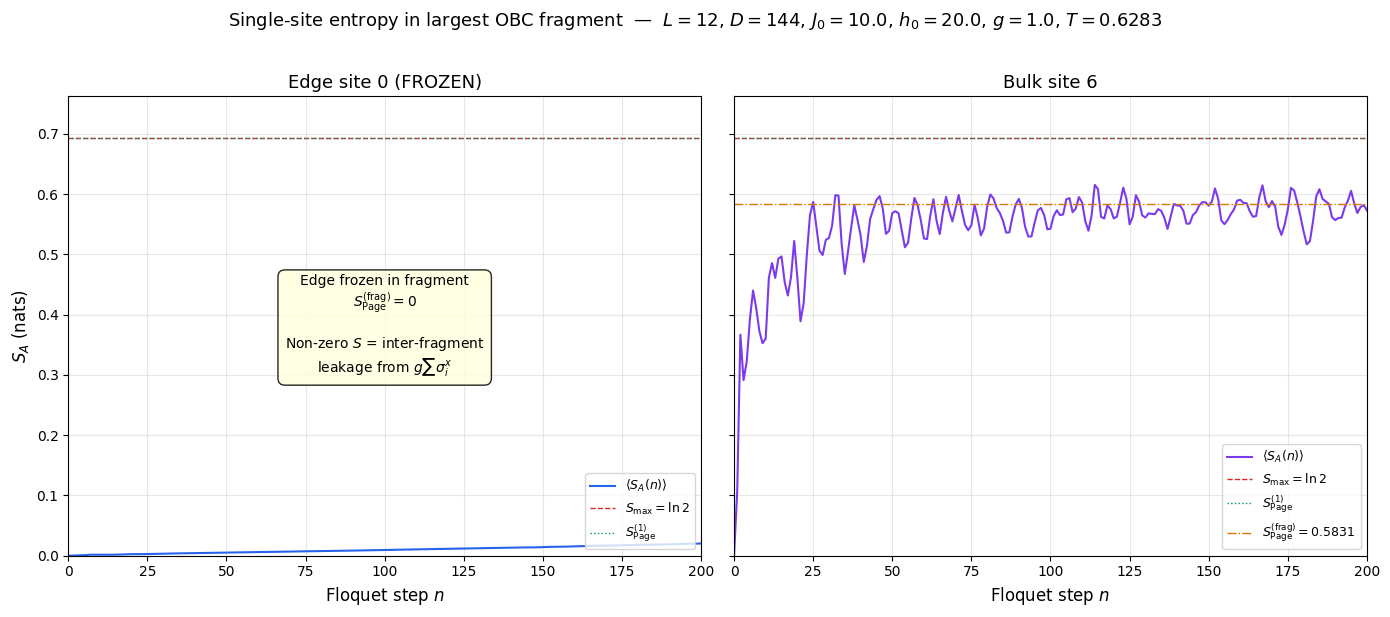

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import deque
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply





def bipartite_entropy(psi, L, A_indices):
    """Von Neumann S_A via SVD. (Prompt 2 definition.)"""
    L_A = len(A_indices)
    L_B = L - L_A
    dim_A = 1 << L_A
    dim_B = 1 << L_B
    norm = np.linalg.norm(psi)
    if abs(norm - 1.0) > 1e-14:
        psi = psi / norm
    if A_indices == list(range(L_A)):
        psi_matrix = psi.reshape(dim_A, dim_B)
    else:
        psi_tensor = psi.reshape((2,) * L)
        B_indices = [j for j in range(L) if j not in A_indices]
        perm = list(A_indices) + B_indices
        psi_perm = np.transpose(psi_tensor, axes=perm)
        psi_matrix = psi_perm.reshape(dim_A, dim_B)
    s = np.linalg.svd(psi_matrix, compute_uv=False)
    p = s * s
    p = p[p > 1e-15]
    return float((-np.sum(p * np.log(p))).real)


def check_site_frozen_in_fragment(fragment_states, L, site):
    """
    Check if a given site has a fixed bit value across all states
    in a fragment.

    Returns
    -------
    frozen : bool
    bits : set of {0} or {1} or {0,1}
    """
    bit_pos = L - 1 - site
    bits = set((s >> bit_pos) & 1 for s in fragment_states)
    return len(bits) == 1, bits



# ============================================================
# CORE: Single-site entropy evolution in largest fragment
# ============================================================

def compute_single_site_entropy_fragment(
        ising, largest, L, n_steps, n_states,
        site, n_MC_samples=1000, seed=42,
        renorm_interval=100, verbose=True):
    """
    Compute S_{A={site}}(n) with initial states from the largest
    OBC fragment. The FloquetIsingChain and fragment are passed in
    so they can be shared across multiple site runs.

    Parameters
    ----------
    ising : FloquetIsingChain
        Already built (build_hamiltonians called).
    largest : list of int
        Largest fragment basis state indices.
    L : int
        Chain length.
    n_steps : int
        Number of Floquet periods.
    n_states : int
        Number of initial basis states from fragment (B).
    site : int
        Site index for subsystem A.
    n_MC_samples : int
        MC samples for fragment Page value.
    seed : int
        RNG seed.
    renorm_interval : int
        Renormalise every N steps.
    verbose : bool
        Print progress.

    Returns
    -------
    results : dict
    """
    assert 0 <= site < L

    A_indices = [site]
    S_page_full = compute_page_value_general(L, L_A=1)
    S_max = np.log(2)
    D = len(largest)

    t0 = time.perf_counter()

    if verbose:
        print(f"\n  --- Site {site} ---")

    # Check if site is frozen in this fragment
    frozen, frozen_bits = check_site_frozen_in_fragment(largest, L, site)

    if verbose:
        print(f"    Site {site} frozen in fragment: {frozen} (bits = {frozen_bits})")

    # Fragment Page value (MC) — skip if frozen
    if frozen:
        S_page_frag = 0.0
        S_std_frag = 0.0
        S_sem_frag = 0.0
        if verbose:
            print(f"    S_Page^(frag) = 0 exactly (frozen site, MC skipped)")
    else:
        S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
            largest, L, n_samples=n_MC_samples,
            A_indices=A_indices, seed=seed, verbose=verbose
        )

    # Build initial states and evolve
    rng = np.random.default_rng(seed)
    Psi, chosen_indices = build_fragment_states_batched(
        largest, L, n_states, rng)

    S_avg = np.zeros(n_steps + 1, dtype=np.float64)

    # Step 0
    for k in range(n_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_states
        print(f"    S(0) = {S0:.2e} (should be 0 for basis states)")

    # Evolution loop
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_steps + 1):
        Psi = apply_floquet_step(ising, Psi)

        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        for k in range(n_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        if verbose and (n % max(1, n_steps // 5) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_cur = S_avg[n] / n_states
            rate = n / elapsed if elapsed > 0 else 0
            print(f"      Step {n:>5d}/{n_steps}: S = {S_cur:.4f} "
                  f"({S_cur/S_max:.3f} S_max)")

    S_avg /= n_states
    steps = np.arange(n_steps + 1)
    wall = time.perf_counter() - t0

    if verbose:
        print(f"    Final S = {S_avg[-1]:.6f}, wall = {wall:.1f} s")

    return {
        'steps': steps,
        'S_avg': S_avg,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'S_std_frag': S_std_frag,
        'S_sem_frag': S_sem_frag,
        'S_max': S_max,
        'D_largest': D,
        'frozen': frozen,
        'params': {
            'L': L, 'J_0': ising.J_0, 'h_0': ising.h_0,
            'g': ising.g, 'T': ising.T,
            'site': site, 'n_states': n_states,
            'n_steps': n_steps, 'n_MC_samples': n_MC_samples,
            'seed': seed,
        },
        'wall_time': wall,
    }


def run_edge_and_bulk(L, J_0, h_0, g, TP, n_steps, n_states,
                      edge_site=0, bulk_site=None,
                      n_MC_samples=1000, seed=42, verbose=True):
    """
    Run entropy dynamics for both edge and bulk sites, sharing the
    FloquetIsingChain and fragment identification across both runs.

    Parameters
    ----------
    L, J_0, h_0, g, TP : float — Tunable system parameters.
    n_steps : int — Number of Floquet periods.
    n_states : int — Number of initial basis states from fragment (B).
    edge_site : int — Edge site index (0 or L-1).
    bulk_site : int or None — Bulk site index. Default: L//2.
    n_MC_samples : int — MC samples for fragment Page value.
    seed : int — RNG seed.
    verbose : bool — Print progress.

    Returns
    -------
    edge_results, bulk_results : dict, dict
    """
    if bulk_site is None:
        bulk_site = L // 2

    if verbose:
        print(f"\n{'=' * 65}")
        print(f"SINGLE-SITE ENTROPY IN LARGEST FRAGMENT (OBC)")
        print(f"{'=' * 65}")
        print(f"  L = {L},  N_s = {1 << L}")
        print(f"  J_0 = {J_0},  h_0 = {h_0},  g = {g},  T = {TP:.6f}")
        print(f"  n_steps = {n_steps},  n_states = {n_states}")
        print(f"  Edge site = {edge_site},  Bulk site = {bulk_site}")

    # --- Shared: fragment identification (done once) ---
    t_frag = time.perf_counter()
    O_diag = build_O_operator(L, J_0)
    adjacency, _ = build_connectivity_graph(L, O_diag)
    components = find_connected_components(adjacency)
    stats = get_fragment_statistics(components)
    largest = find_largest_fragment(components)
    D = len(largest)
    t_frag = time.perf_counter() - t_frag

    if verbose:
        print(f"\n  Fragment identification ({t_frag:.2f} s):")
        print(f"    Total fragments: {stats['num_fragments']}")
        print(f"    Largest fragment: D = {D} "
              f"({D / (1 << L) * 100:.1f}% of Hilbert space)")
        print(f"    Singletons: {stats['num_singletons']}")

        # Check which sites are frozen
        frozen_sites = []
        mobile_sites = []
        for s in range(L):
            fr, _ = check_site_frozen_in_fragment(largest, L, s)
            if fr:
                frozen_sites.append(s)
            else:
                mobile_sites.append(s)
        print(f"    Frozen sites (edge-type):  {frozen_sites}")
        print(f"    Mobile sites (bulk-type):  {mobile_sites}")

    # --- Shared: build Floquet system (done once) ---
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    if verbose:
        print(f"    Krylov sub-steps: K+ = {ising.K_plus}, K- = {ising.K_minus}")

    # --- Run edge site ---
    edge_results = compute_single_site_entropy_fragment(
        ising, largest, L, n_steps, n_states,
        site=edge_site, n_MC_samples=n_MC_samples,
        seed=seed, verbose=verbose
    )

    # --- Run bulk site ---
    bulk_results = compute_single_site_entropy_fragment(
        ising, largest, L, n_steps, n_states,
        site=bulk_site, n_MC_samples=n_MC_samples,
        seed=seed, verbose=verbose
    )

    return edge_results, bulk_results


# ============================================================
# PLOTTING: 2-panel comparison
# ============================================================

def plot_edge_vs_bulk(edge_results, bulk_results,
                      save_path=None, show=True):
    """
    Two-panel plot: edge (frozen) vs bulk (mobile) site
    entropy dynamics within the largest fragment.
    """
    fig, (ax_e, ax_b) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    S_max = np.log(2)
    pe = edge_results['params']
    pb = bulk_results['params']

    # --- Left panel: Edge site ---
    ax_e.plot(edge_results['steps'], edge_results['S_avg'],
              '-', color='#2563EB', linewidth=1.5,
              label=r'$\langle S_A(n) \rangle$')
    ax_e.axhline(S_max, color='#DC2626', linestyle='--', linewidth=1.0,
                 label=rf'$S_{{\max}} = \ln 2$')
    ax_e.axhline(edge_results['S_page_full'], color='#059669',
                 linestyle=':', linewidth=1.0,
                 label=rf'$S_{{\mathrm{{Page}}}}^{{(1)}}$')
    if edge_results['S_page_frag'] > 1e-10:
        ax_e.axhline(edge_results['S_page_frag'], color='#D97706',
                     linestyle='-.', linewidth=1.0,
                     label=rf'$S_{{\mathrm{{Page}}}}^{{(\mathrm{{frag}})}}$')

    ax_e.set_xlabel('Floquet step $n$', fontsize=12)
    ax_e.set_ylabel(r'$S_A$ (nats)', fontsize=12)
    frozen_label = " (FROZEN)" if edge_results['frozen'] else ""
    ax_e.set_title(
        rf'Edge site {pe["site"]}{frozen_label}',
        fontsize=13)
    ax_e.legend(fontsize=9, loc='lower right')
    ax_e.set_xlim(0, edge_results['steps'][-1])
    ax_e.set_ylim(bottom=0, top=S_max * 1.1)
    ax_e.grid(True, alpha=0.3)
    ax_e.tick_params(labelsize=10)

    # Annotation for frozen edge
    if edge_results['frozen']:
        ax_e.text(0.5, 0.5,
                  'Edge frozen in fragment\n'
                  r'$S_{\mathrm{Page}}^{(\mathrm{frag})} = 0$'
                  '\n\nNon-zero $S$ = inter-fragment\n'
                  r'leakage from $g \sum \sigma^x_i$',
                  transform=ax_e.transAxes, fontsize=10,
                  ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.5',
                            facecolor='lightyellow', alpha=0.85))

    # --- Right panel: Bulk site ---
    ax_b.plot(bulk_results['steps'], bulk_results['S_avg'],
              '-', color='#7C3AED', linewidth=1.5,
              label=r'$\langle S_A(n) \rangle$')
    ax_b.axhline(S_max, color='#DC2626', linestyle='--', linewidth=1.0,
                 label=rf'$S_{{\max}} = \ln 2$')
    ax_b.axhline(bulk_results['S_page_full'], color='#059669',
                 linestyle=':', linewidth=1.0,
                 label=rf'$S_{{\mathrm{{Page}}}}^{{(1)}}$')
    if bulk_results['S_page_frag'] > 1e-10:
        ax_b.axhline(bulk_results['S_page_frag'], color='#D97706',
                     linestyle='-.', linewidth=1.0,
                     label=rf'$S_{{\mathrm{{Page}}}}^{{(\mathrm{{frag}})}} = '
                           rf'{bulk_results["S_page_frag"]:.4f}$')

    ax_b.set_xlabel('Floquet step $n$', fontsize=12)
    frozen_label_b = " (FROZEN)" if bulk_results['frozen'] else ""
    ax_b.set_title(
        rf'Bulk site {pb["site"]}{frozen_label_b}',
        fontsize=13)
    ax_b.legend(fontsize=9, loc='lower right')
    ax_b.set_xlim(0, bulk_results['steps'][-1])
    ax_b.grid(True, alpha=0.3)
    ax_b.tick_params(labelsize=10)

    # Shared supertitle with parameters
    fig.suptitle(
        rf'Single-site entropy in largest OBC fragment  —  '
        rf'$L={pe["L"]}$, $D={edge_results["D_largest"]}$, '
        rf'$J_0={pe["J_0"]}$, $h_0={pe["h_0"]}$, $g={pe["g"]}$, '
        rf'$T={pe["T"]:.4f}$',
        fontsize=13, y=1.02
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Figure saved to: {save_path}")
    if show:
        plt.show()

    return fig, (ax_e, ax_b)


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 3: Single-Site Entropy in Largest Fragment — Tests + Run")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: OBC O operator — L=2 analytical check
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: OBC O operator — L=2 analytical check")
    print("-" * 72)

    # L=2, J0=1: O = J0*sz0*sz1 + 2*J0*(sz0 + sz1)   (1 bond OBC)
    # |00>: ZZ=+1, Z_sum=+2 -> O = 1 + 4 = 5
    # |01>: ZZ=-1, Z_sum= 0 -> O = -1 + 0 = -1
    # |10>: ZZ=-1, Z_sum= 0 -> O = -1 + 0 = -1
    # |11>: ZZ=+1, Z_sum=-2 -> O = 1 - 4 = -3
    O_test = build_O_operator(2, 1.0)
    O_expected = np.array([5.0, -1.0, -1.0, -3.0])
    assert np.allclose(O_test, O_expected), \
        f"O mismatch: {O_test} vs {O_expected}"
    print(f"  O = {O_test}")
    print(f"  Expected = {O_expected}")
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Edge sites frozen in ALL OBC fragments (L=8)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: All OBC fragments have frozen edges (L=8)")
    print("-" * 72)

    L_t = 8
    O_t = build_O_operator(L_t, 4.0)
    adj_t, _ = build_connectivity_graph(L_t, O_t)
    comp_t = find_connected_components(adj_t)

    all_frozen_0 = all(
        check_site_frozen_in_fragment(c, L_t, 0)[0]
        for c in comp_t if len(c) > 1
    )
    all_frozen_R = all(
        check_site_frozen_in_fragment(c, L_t, L_t - 1)[0]
        for c in comp_t if len(c) > 1
    )
    print(f"  Site 0 frozen in all D>1 fragments: {all_frozen_0}")
    print(f"  Site {L_t-1} frozen in all D>1 fragments: {all_frozen_R}")
    assert all_frozen_0 and all_frozen_R
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: Bulk site NOT frozen in largest fragment (L=8)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Bulk site mobile in largest fragment (L=8)")
    print("-" * 72)

    largest_t = find_largest_fragment(comp_t)
    bulk_t = L_t // 2
    frozen_bulk, bits_bulk = check_site_frozen_in_fragment(
        largest_t, L_t, bulk_t)
    print(f"  Site {bulk_t} frozen: {frozen_bulk}, bits = {bits_bulk}")
    assert not frozen_bulk, "Bulk site frozen — unexpected!"
    print("  PASS: bulk site is mobile within largest fragment")

    # ----------------------------------------------------------
    # TEST 4: Fragment Page value for frozen site = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: Fragment Page value = 0 for frozen edge (L=8)")
    print("-" * 72)

    S_pfr_edge, _, _ = compute_fragment_page_value_MC(
        largest_t, L_t, n_samples=200,
        A_indices=[0], seed=42, verbose=False
    )
    print(f"  S_Page^(frag, site 0) = {S_pfr_edge:.2e}")
    assert S_pfr_edge < 1e-14, f"Frozen site Page value nonzero: {S_pfr_edge}"
    print("  PASS: S_Page^(frag, edge) = 0 exactly")

    # ----------------------------------------------------------
    # TEST 5: Fragment Page value for bulk site > 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Fragment Page value > 0 for mobile bulk site (L=8)")
    print("-" * 72)

    S_pfr_bulk, _, _ = compute_fragment_page_value_MC(
        largest_t, L_t, n_samples=500,
        A_indices=[bulk_t], seed=42, verbose=False
    )
    print(f"  S_Page^(frag, site {bulk_t}) = {S_pfr_bulk:.6f}")
    assert S_pfr_bulk > 0.01, f"Bulk site Page value too small: {S_pfr_bulk}"
    print("  PASS: bulk site has non-trivial fragment Page value")

    # ----------------------------------------------------------
    # PRODUCTION RUN
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("PRODUCTION RUN: L=10, 200 steps, edge vs bulk")
    print("-" * 72)

    # ====== TUNABLE PARAMETERS ======
    L          = 12
    J_0        = 10.0
    h_0        = 20.0       # h_0 = 2*J_0  (prethermal condition)
    g          = 1.0
    TP         = 2*np.pi / J_0
    n_steps    = 200
    n_states   = 10
    edge_site  = 0         # 0 = left edge, L-1 = right edge
    bulk_site  = L // 2    # site 5 (middle of chain)
    n_MC       = 1000      # MC samples for fragment Page value
    seed       = 42
    # =================================

    edge_res, bulk_res = run_edge_and_bulk(
        L=L, J_0=J_0, h_0=h_0, g=g, TP=TP,
        n_steps=n_steps, n_states=n_states,
        edge_site=edge_site, bulk_site=bulk_site,
        n_MC_samples=n_MC, seed=seed, verbose=True
    )

    fig, axes = plot_edge_vs_bulk(
        edge_res, bulk_res,
        save_path='edge_vs_bulk_fragment.png', show=False
    )

    print("\n" + "=" * 72)
    print("PROMPT 3 COMPLETE")
    print("=" * 72)

# EE bulk detuning

### Definitions

In [ ]:
"""Module: detuning_scan
Provides: run_detuning_scan
Depends on: hamiltonian, evolution, entropy, fragment_ops, fragment_page,
            fragment_dynamics

Robustness check for Hilbert space fragmentation under detuning
δ = h₀ − 2J₀.

Protocol:
  1. At δ=0: identify the largest fragment, draw B basis states from it.
  2. For each δ: build Floquet system with h₀ = 2J₀ + δ (same J₀, g, T),
     evolve the SAME initial states for n_periods, measure S_A(n).
  3. Extract S_sat from the tail of each time series.

Physics: if fragmentation is robust for |δ| ≲ g, then S_sat stays
near S_Page^(frag). If it jumps to S_Page^(full) for tiny δ, the
fragmentation is fine-tuned and experimentally irrelevant.
"""
import numpy as np
import time
import io
import contextlib


def _extract_saturation_entropy(S_avg, n_periods, tail_fraction=0.2):
    """
    Extract saturation entropy from the tail of the time series.

    Parameters
    ----------
    S_avg : ndarray, shape (n_periods+1,)
    n_periods : int
    tail_fraction : float

    Returns
    -------
    S_sat : float — mean over tail
    S_sat_std : float — std over tail (plateau quality)
    """
    n_tail = max(1, int(n_periods * tail_fraction))
    tail = S_avg[-n_tail:]
    return float(np.mean(tail)), float(np.std(tail))


def run_detuning_scan(L, J0, g, delta_over_J0_values, n_periods,
                      n_initial_states, n_MC_samples=500,
                      tail_fraction=0.2, seed=42,
                      renorm_interval=100, verbose=True):
    """
    Sweep δ/J₀ and measure saturation entropy of fragment-basis
    initial states evolved under the detuned Floquet Hamiltonian.

    Parameters
    ----------
    L : int
        Chain length.
    J0 : float
        Ising coupling strength.
    g : float
        Transverse field (perturbation).
    delta_over_J0_values : array-like of float
        Values of δ/J₀ to scan.
    n_periods : int
        Number of Floquet periods per run.
    n_initial_states : int
        Number of basis states from the δ=0 fragment (B).
    n_MC_samples : int
        MC samples for fragment Page value.
    tail_fraction : float
        Fraction of tail for plateau extraction.
    seed : int
        RNG seed (used for both fragment states and MC).
    renorm_interval : int
        Renormalise every N steps.
    verbose : bool
        Print progress.

    Returns
    -------
    results : dict
    """
    delta_arr = np.asarray(delta_over_J0_values, dtype=np.float64)
    n_delta = len(delta_arr)
    T = 2.0 * np.pi / J0        # T = 2π/J₀
    A_indices = list(range(L // 2))

    t0 = time.perf_counter()

    # ==============================================================
    # STEP 1: Fragment identification at δ=0
    # ==============================================================
    S_page_full = compute_page_value(L)

    if verbose:
        print(f"Step 1: Fragment identification at δ=0  (h₀ = {2*J0})")

    O_diag = build_O_operator(L, J0)
    adjacency, _ = build_connectivity_graph(L, O_diag, tol=1e-10)
    components = find_connected_components(adjacency)
    largest_frag = find_largest_fragment(components)
    D_largest = len(largest_frag)

    S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
        largest_frag, L, n_samples=n_MC_samples,
        seed=seed, verbose=False
    )

    if verbose:
        print(f"  D_largest = {D_largest}")
        print(f"  S_Page^(full) = {S_page_full:.6f}")
        print(f"  S_Page^(frag) = {S_page_frag:.6f} +/- {S_sem_frag:.6f}")

    # ==============================================================
    # STEP 2: Build B initial basis states from the δ=0 fragment
    #         These are FIXED across the entire δ scan.
    # ==============================================================
    rng = np.random.default_rng(seed)
    Psi0, chosen_indices = build_fragment_states_batched(
        largest_frag, L, n_initial_states, rng
    )

    if verbose:
        print(f"\nStep 2: Built {n_initial_states} initial states from fragment")
        print(f"  Chosen basis states: {chosen_indices}")

    # ==============================================================
    # STEP 3: Sweep δ — evolve the SAME initial states under
    #         detuned Hamiltonian h₀ = 2J₀ + δ
    # ==============================================================
    if verbose:
        print(f"\nStep 3: Scanning {n_delta} values of delta/J0")
        print(f"  L={L}, J0={J0}, g={g}, T=2*pi/J0={T:.6f}")
        print(f"  n_periods={n_periods}, B={n_initial_states}")
        print(f"  g/J0 = {g/J0:.4f} — robustness scale\n")

    S_sat = np.zeros(n_delta)
    S_sat_std = np.zeros(n_delta)
    h0_values = np.zeros(n_delta)
    S_timeseries = {}

    for idx, d_over_J0 in enumerate(delta_arr):
        delta = d_over_J0 * J0
        h0 = 2.0 * J0 + delta
        h0_values[idx] = h0

        # Build detuned Floquet system (suppress print output)
        f_buf = io.StringIO()
        with contextlib.redirect_stdout(f_buf):
            ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
            ising.build_hamiltonians()

        # Start from the SAME initial states (deep copy)
        Psi = Psi0.copy()

        # Allocate entropy array
        S_avg = np.zeros(n_periods + 1, dtype=np.float64)

        # Step 0: initial entropy (should be 0 — basis states)
        for k in range(n_initial_states):
            S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Evolution loop
        for n in range(1, n_periods + 1):
            Psi = apply_floquet_step(ising, Psi)

            if renorm_interval > 0 and n % renorm_interval == 0:
                norms = np.linalg.norm(Psi, axis=0)
                Psi /= norms[np.newaxis, :]

            for k in range(n_initial_states):
                S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        S_avg /= n_initial_states

        # Extract saturation
        S_sat[idx], S_sat_std[idx] = _extract_saturation_entropy(
            S_avg, n_periods, tail_fraction
        )
        S_timeseries[d_over_J0] = S_avg.copy()

        if verbose:
            r_full = S_sat[idx] / S_page_full
            r_frag = S_sat[idx] / S_page_frag
            print(f"  [{idx+1:>2d}/{n_delta}] delta/J0={d_over_J0:+.4f}  "
                  f"h0={h0:.4f}  S_sat={S_sat[idx]:.4f}  "
                  f"S/S_full={r_full:.3f}  S/S_frag={r_frag:.3f}")

    wall = time.perf_counter() - t0

    if verbose:
        print(f"\nScan complete. Wall time: {wall:.1f} s")

    return {
        'L': L, 'J0': J0, 'g': g, 'T': T,
        'n_periods': n_periods,
        'n_initial_states': n_initial_states,
        'delta_over_J0': delta_arr,
        'delta': delta_arr * J0,
        'h0_values': h0_values,
        'S_sat': S_sat,
        'S_sat_std': S_sat_std,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'S_std_frag': S_std_frag,
        'S_sem_frag': S_sem_frag,
        'D_largest': D_largest,
        'largest_fragment': largest_frag,
        'chosen_indices': chosen_indices,
        'S_timeseries': S_timeseries,
        'wall_time': wall,
    }

### Results code

In [ ]:
"""Results: detuning_scan_L5
Runs the fine-tuning robustness check for L=5.

Protocol:
  - Fragment identified at δ=0 with T = 2π/J₀
  - B=5 basis states drawn from the largest fragment
  - Each δ: evolve those states under h₀ = 2J₀ + δ for 200 periods
  - 35 points in δ/J₀ ∈ [-0.5, +0.5]
"""
import numpy as np
import time

# ============================================================
# PHYSICS PARAMETERS
# ============================================================
L = 8
J0 = 10.0
g = 1          # perturbation scale: the key comparison is |δ| vs g

# Detuning grid: 35 points, denser near δ=0
delta_fine = np.linspace(-0.15, 0.15, 15)        # 15 points near centre
delta_coarse_neg = np.linspace(-1, -0.16, 7)  # 7 points left
delta_coarse_pos = np.linspace(0.16, 1, 7)    # 7 points right
delta_over_J0 = np.sort(np.unique(np.concatenate([
    delta_coarse_neg, delta_fine, delta_coarse_pos
])))
# Remove near-duplicates from overlap at ±0.15, ±0.20
delta_over_J0 = np.unique(np.round(delta_over_J0, decimals=6))

print(f"Detuning grid: {len(delta_over_J0)} points")
print(f"  Range: delta/J0 in [{delta_over_J0[0]:.3f}, {delta_over_J0[-1]:.3f}]")
print(f"  g/J0 = {g/J0:.4f}")
print(f"  |delta| = g corresponds to delta/J0 = {g/J0:.4f}")

# ============================================================
# EVOLUTION PARAMETERS
# ============================================================
n_periods = 200
n_initial_states = 5       # B = 5
n_MC_samples = 500         # for fragment Page value
tail_fraction = 0.2        # last 20% for plateau extraction
seed = 42

# ============================================================
# RUN
# ============================================================
t0 = time.perf_counter()

results = run_detuning_scan(
    L=L, J0=J0, g=g,
    delta_over_J0_values=delta_over_J0,
    n_periods=n_periods,
    n_initial_states=n_initial_states,
    n_MC_samples=n_MC_samples,
    tail_fraction=tail_fraction,
    seed=seed,
    renorm_interval=100,
    verbose=True
)

t_total = time.perf_counter() - t0
print(f"\nTOTAL WALL TIME: {t_total:.1f} s")

# ============================================================
# SAVE
# ============================================================



# ============================================================
# SUMMARY TABLE
# ============================================================
print(f"\n{'='*70}")
print(f"SUMMARY: L={L}, J0={J0}, g={g}, T=2*pi/J0={results['T']:.4f}")
print(f"S_Page^(full) = {results['S_page_full']:.6f}")
print(f"S_Page^(frag) = {results['S_page_frag']:.6f}  (D={results['D_largest']})")
print(f"{'='*70}")
print(f"{'d/J0':>8}  {'h0':>8}  {'S_sat':>8}  {'pm':>6}  "
      f"{'S/S_full':>8}  {'S/S_frag':>8}")
print('-' * 58)
for i, d in enumerate(results['delta_over_J0']):
    print(f"{d:>+8.4f}  {results['h0_values'][i]:>8.4f}  "
          f"{results['S_sat'][i]:>8.4f}  {results['S_sat_std'][i]:>6.4f}  "
          f"{results['S_sat'][i]/results['S_page_full']:>8.4f}  "
          f"{results['S_sat'][i]/results['S_page_frag']:>8.4f}")

Detuning grid: 29 points
  Range: delta/J0 in [-1.000, 1.000]
  g/J0 = 0.1000
  |delta| = g corresponds to delta/J0 = 0.1000
Step 1: Fragment identification at δ=0  (h₀ = 20.0)
  D_largest = 21
  S_Page^(full) = 2.272589
  S_Page^(frag) = 1.093745 +/- 0.004385

Step 2: Built 5 initial states from fragment
  Chosen basis states: [173 245 235 215 215]

Step 3: Scanning 29 values of delta/J0
  L=8, J0=10.0, g=1, T=2*pi/J0=0.628319
  n_periods=200, B=5
  g/J0 = 0.1000 — robustness scale

  Diagonal computed for OBC (L-1 = 7 ZZ bonds, no wrap-around)
  CSR cross-check skipped (hamiltonian.py builds PBC)

  Auto-calibrating n_sub (tol=1e-06)...
    n_sub=  1: Richardson err = 9.39e-01
    n_sub=  2: Richardson err = 1.74e-01
    n_sub=  4: Richardson err = 2.11e-03
    n_sub=  8: Richardson err = 2.74e-05
    n_sub= 16: Richardson err = 1.56e-06
    n_sub= 32: Richardson err = 9.62e-08
  → n_sub = 32

  Trotter propagator ready (OBC):
    Order = 4 (Yoshida-Suzuki)
    n_sub = 32 per half-st

### Plotting code

Saved results to detuning_scan_L8_J010.0_g1.npz


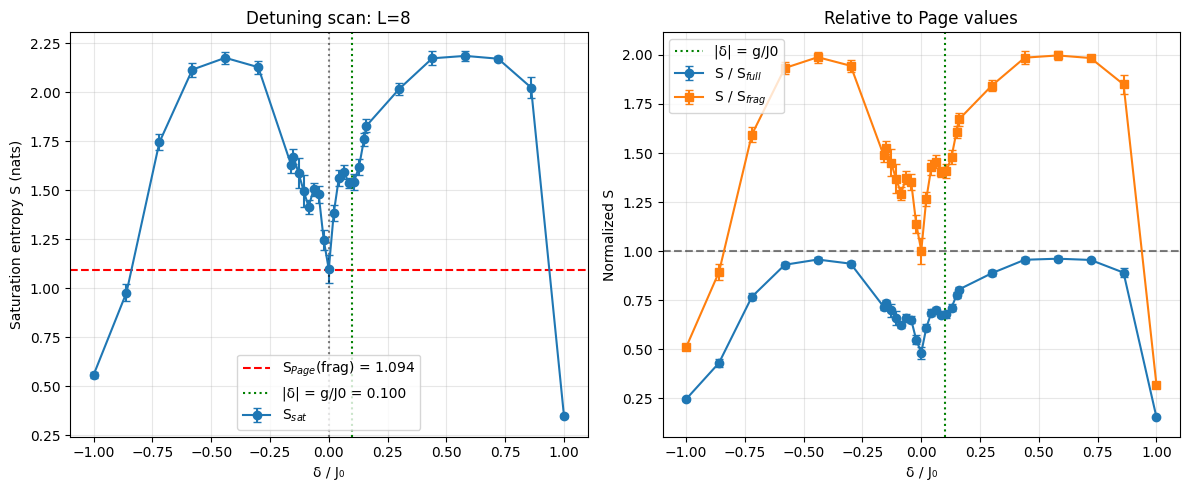

In [ ]:
# ============================================================
# SAVE AS NPZ
# ============================================================
np.savez_compressed(
    f'detuning_scan_L{L}_J0{J0}_g{g}.npz',
    **results  # Saves all keys: delta_over_J0, S_sat, etc.
)
print(f"Saved results to detuning_scan_L{L}_J0{J0}_g{g}.npz")

# ============================================================
# PLOT RESULTS
# ============================================================
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: S_sat vs delta/J0 with error bars
ax1.errorbar(
    results['delta_over_J0'], results['S_sat'],
    yerr=results['S_sat_std'], fmt='o-', capsize=3, label='S$_{sat}$'
)
ax1.axhline(results['S_page_frag'], color='r', linestyle='--', label=f'S$_{{Page}}$(frag) = {results["S_page_frag"]:.3f}')
ax1.axvline(0, color='k', linestyle=':', alpha=0.5)
ax1.axvline(g/J0, color='g', linestyle=':', label=f'|δ| = g/J0 = {g/J0:.3f}')
ax1.set_xlabel('δ / J₀')
ax1.set_ylabel('Saturation entropy S (nats)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Detuning scan: L={L}')

# Right: Relative to Page values
ax2.errorbar(
    results['delta_over_J0'], results['S_sat']/results['S_page_full'],
    yerr=results['S_sat_std']/results['S_page_full'], fmt='o-', capsize=3, label='S / S$_{full}$'
)
ax2.errorbar(
    results['delta_over_J0'], results['S_sat']/results['S_page_frag'],
    yerr=results['S_sat_std']/results['S_page_frag'], fmt='s-', capsize=3, label='S / S$_{frag}$'
)
ax2.axvline(g/J0, color='g', linestyle=':', label=f'|δ| = g/J0')
ax2.axhline(1, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('δ / J₀')
ax2.set_ylabel('Normalized S')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Relative to Page values')

plt.tight_layout()
plt.show()


# EE edge detuning

### Definitions

In [ ]:
"""Module: edge_detuning_scan
Provides: run_edge_detuning_scan
Depends on: entropy, evolution (apply_floquet_step logic), fragment_ops (connectivity),
            fragment_page, fragment_dynamics

Robustness of edge-site freezing under detuning δ = h₀ − 2J₀.

Uses OBC Hamiltonian and OBC O-operator so that edge sites (0, L−1)
are genuinely frozen in the largest fragment at δ=0.

Protocol:
  1. Build OBC O-operator at δ=0 → identify largest fragment.
  2. Draw B basis states from that fragment (fixed for all δ).
  3. For each δ: build OBC Floquet system with h₀ = 2J₀ + δ,
     evolve those states for n_periods, measure S_{A={site 0}}(n).
  4. Extract S_sat from tail.

Physics: at δ=0 edge sites are frozen ⇒ S_edge ≈ 0.  Detuning
breaks the exact conservation law, so S_edge should grow.  The
question is: how fast, and at what δ-scale?
"""
import numpy as np
import time
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply
from scipy.sparse.linalg import norm as sp_norm



# ============================================================
# Page value for single-site bipartition
# ============================================================

def compute_page_value_1site(L):
    """S_Page for A = 1 site: ln(2) − 1/2^{L−1}."""
    return np.log(2) - 1.0 / (1 << (L - 1))


# ============================================================
# Saturation extraction
# ============================================================

def _extract_saturation_entropy(S_avg, n_periods, tail_fraction=0.2):
    n_tail = max(1, int(n_periods * tail_fraction))
    tail = S_avg[-n_tail:]
    return float(np.mean(tail)), float(np.std(tail))


# ============================================================
# Check site frozen
# ============================================================

def check_site_frozen_in_fragment(fragment_states, L, site):
    bit_pos = L - 1 - site
    bits = set((s >> bit_pos) & 1 for s in fragment_states)
    return len(bits) == 1, bits


# ============================================================
# MAIN WRAPPER
# ============================================================

def run_edge_detuning_scan(L, J0, g, delta_over_J0_values, n_periods,
                           n_initial_states, edge_site=0, bulk_site=None,
                           n_MC_samples=500, tail_fraction=0.2, seed=42,
                           renorm_interval=100, verbose=True):
    """
    Sweep δ/J₀ and measure edge-site saturation entropy.

    Uses OBC throughout.  Initial states drawn from the largest
    OBC fragment at δ=0.  Also computes bulk-site entropy for
    comparison.

    Parameters
    ----------
    L : int
    J0, g : float
    delta_over_J0_values : array-like
    n_periods : int
    n_initial_states : int — B
    edge_site : int — default 0
    bulk_site : int or None — default L//2
    n_MC_samples : int
    tail_fraction : float
    seed : int
    renorm_interval : int
    verbose : bool

    Returns
    -------
    results : dict
    """
    if bulk_site is None:
        bulk_site = L // 2

    delta_arr = np.asarray(delta_over_J0_values, dtype=np.float64)
    n_delta = len(delta_arr)
    T = 2.0 * np.pi / J0
    A_edge = [edge_site]
    A_bulk = [bulk_site]

    t0 = time.perf_counter()

    # ==============================================================
    # STEP 1: OBC fragment identification at δ=0
    # ==============================================================
    S_page_1site = compute_page_value_1site(L)
    S_max = np.log(2)
    S_page_half = compute_page_value(L)

    if verbose:
        print(f"Step 1: OBC fragment identification at delta=0  (h0 = {2*J0})")

    O_diag = build_O_operator(L, J0)
    adjacency, _ = build_connectivity_graph(L, O_diag, tol=1e-10)
    components = find_connected_components(adjacency)
    largest_frag = find_largest_fragment(components)
    stats = get_fragment_statistics(components)
    D_largest = len(largest_frag)

    # Check frozen status
    edge_frozen, edge_bits = check_site_frozen_in_fragment(largest_frag, L, edge_site)
    bulk_frozen, bulk_bits = check_site_frozen_in_fragment(largest_frag, L, bulk_site)

    # Fragment Page values for each site
    if edge_frozen:
        S_page_frag_edge = 0.0
    else:
        S_page_frag_edge, _, _ = compute_fragment_page_value_MC(
            largest_frag, L, n_samples=n_MC_samples,
            A_indices=A_edge, seed=seed, verbose=False)

    S_page_frag_bulk, _, _ = compute_fragment_page_value_MC(
        largest_frag, L, n_samples=n_MC_samples,
        A_indices=A_bulk, seed=seed, verbose=False)

    if verbose:
        print(f"  D_largest = {D_largest},  fragments = {stats['num_fragments']}")
        print(f"  Site {edge_site}: frozen={edge_frozen}, bits={edge_bits}")
        print(f"  Site {bulk_site}: frozen={bulk_frozen}, bits={bulk_bits}")
        print(f"  S_max = ln(2) = {S_max:.6f}")
        print(f"  S_Page (1-site, full) = {S_page_1site:.6f}")
        print(f"  S_Page^frag (edge, site {edge_site}) = {S_page_frag_edge:.6f}")
        print(f"  S_Page^frag (bulk, site {bulk_site}) = {S_page_frag_bulk:.6f}")

    # ==============================================================
    # STEP 2: Build B initial states from δ=0 fragment
    # ==============================================================
    rng = np.random.default_rng(seed)
    Psi0, chosen_indices = build_fragment_states_batched(
        largest_frag, L, n_initial_states, rng)

    if verbose:
        print(f"\nStep 2: Built {n_initial_states} initial states from OBC fragment")
        print(f"  Chosen: {chosen_indices}")

    # ==============================================================
    # STEP 3: Sweep δ
    # ==============================================================
    if verbose:
        print(f"\nStep 3: Scanning {n_delta} values of delta/J0")
        print(f"  L={L}, J0={J0}, g={g}, T=2*pi/J0={T:.6f}")
        print(f"  n_periods={n_periods}, B={n_initial_states}")
        print(f"  g/J0 = {g/J0:.4f}\n")

    S_sat_edge = np.zeros(n_delta)
    S_sat_edge_std = np.zeros(n_delta)
    S_sat_bulk = np.zeros(n_delta)
    S_sat_bulk_std = np.zeros(n_delta)
    h0_values = np.zeros(n_delta)
    ts_edge = {}
    ts_bulk = {}

    for idx, d_over_J0 in enumerate(delta_arr):
        delta = d_over_J0 * J0
        h0 = 2.0 * J0 + delta
        h0_values[idx] = h0

        # Build OBC Floquet system
        chain = FloquetIsingChain(L, J0, h0, g, T)
        chain.build_hamiltonians()

        # Deep copy initial states
        Psi = Psi0.copy()

        # Allocate entropy arrays
        S_e = np.zeros(n_periods + 1, dtype=np.float64)
        S_b = np.zeros(n_periods + 1, dtype=np.float64)

        # Step 0
        for k in range(n_initial_states):
            S_e[0] += bipartite_entropy(Psi[:, k], L, A_edge)
            S_b[0] += bipartite_entropy(Psi[:, k], L, A_bulk)

        # Evolution
        for n in range(1, n_periods + 1):
            Psi = apply_floquet_step(chain, Psi)

            if renorm_interval > 0 and n % renorm_interval == 0:
                norms = np.linalg.norm(Psi, axis=0)
                Psi /= norms[np.newaxis, :]

            for k in range(n_initial_states):
                S_e[n] += bipartite_entropy(Psi[:, k], L, A_edge)
                S_b[n] += bipartite_entropy(Psi[:, k], L, A_bulk)

        S_e /= n_initial_states
        S_b /= n_initial_states

        S_sat_edge[idx], S_sat_edge_std[idx] = _extract_saturation_entropy(
            S_e, n_periods, tail_fraction)
        S_sat_bulk[idx], S_sat_bulk_std[idx] = _extract_saturation_entropy(
            S_b, n_periods, tail_fraction)

        ts_edge[d_over_J0] = S_e.copy()
        ts_bulk[d_over_J0] = S_b.copy()

        if verbose:
            print(f"  [{idx+1:>2d}/{n_delta}] d/J0={d_over_J0:+.4f}  "
                  f"S_edge={S_sat_edge[idx]:.4f}  "
                  f"S_bulk={S_sat_bulk[idx]:.4f}")

    wall = time.perf_counter() - t0

    if verbose:
        print(f"\nScan complete. Wall time: {wall:.1f} s")

    return {
        'L': L, 'J0': J0, 'g': g, 'T': T,
        'n_periods': n_periods,
        'n_initial_states': n_initial_states,
        'edge_site': edge_site,
        'bulk_site': bulk_site,
        'delta_over_J0': delta_arr,
        'delta': delta_arr * J0,
        'h0_values': h0_values,
        'S_sat_edge': S_sat_edge,
        'S_sat_edge_std': S_sat_edge_std,
        'S_sat_bulk': S_sat_bulk,
        'S_sat_bulk_std': S_sat_bulk_std,
        'S_max': S_max,
        'S_page_1site': S_page_1site,
        'S_page_frag_edge': S_page_frag_edge,
        'S_page_frag_bulk': S_page_frag_bulk,
        'S_page_half': S_page_half,
        'D_largest': D_largest,
        'edge_frozen': edge_frozen,
        'bulk_frozen': bulk_frozen,
        'chosen_indices': chosen_indices,
        'ts_edge': ts_edge,
        'ts_bulk': ts_bulk,
        'wall_time': wall,
    }

### Results code

In [ ]:
"""Results: edge_detuning_scan_L6
Edge-site freezing robustness check under detuning δ = h₀ − 2J₀.

OBC, L=6, J₀=10, g=1, T=2π/J₀, n_steps=200, B=5.
30 points in δ/J₀ ∈ [−1, 1] with fine-graining near 0.
"""
import numpy as np
import time
# ============================================================
# PHYSICS PARAMETERS
# ============================================================
L  = 8
J0 = 10.0
g  = 1.0       # perturbation: g/J₀ = 0.1

# Detuning grid: 30 points, fine near 0
# Fine:   15 points in [−0.2, 0.2]
# Coarse: ~8 points on each wing [−1, −0.25] and [0.25, 1]
delta_fine = np.linspace(-0.20, 0.20, 15)
delta_neg  = np.array([-1.0, -0.85, -0.70, -0.55, -0.40, -0.30, -0.25])
delta_pos  = np.array([0.25, 0.30, 0.40, 0.55, 0.70, 0.85, 1.0])
delta_over_J0 = np.sort(np.unique(np.round(np.concatenate([
    delta_neg, delta_fine, delta_pos
]), decimals=6)))

print(f"Detuning grid: {len(delta_over_J0)} points")
print(f"  Range: delta/J0 in [{delta_over_J0[0]:.2f}, {delta_over_J0[-1]:.2f}]")
print(f"  g/J0 = {g/J0:.4f}")

# ============================================================
# EVOLUTION PARAMETERS
# ============================================================
n_periods        = 200
n_initial_states = 5     # B = 5
n_MC_samples     = 500
tail_fraction    = 0.2
seed             = 42

# ============================================================
# RUN
# ============================================================
t0 = time.perf_counter()

results = run_edge_detuning_scan(
    L=L, J0=J0, g=g,
    delta_over_J0_values=delta_over_J0,
    n_periods=n_periods,
    n_initial_states=n_initial_states,
    edge_site=0,
    bulk_site=L // 2,
    n_MC_samples=n_MC_samples,
    tail_fraction=tail_fraction,
    seed=seed,
    renorm_interval=100,
    verbose=False
)

t_total = time.perf_counter() - t0
print(f"\nTOTAL WALL TIME: {t_total:.1f} s")

# ============================================================
# SAVE
# ============================================================

ts_edge_keys = sorted(results['ts_edge'].keys())
ts_edge_arr  = np.array([results['ts_edge'][k] for k in ts_edge_keys])
ts_bulk_arr  = np.array([results['ts_bulk'][k] for k in ts_edge_keys])


# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*72}")
print(f"SUMMARY: L={L}, J0={J0}, g={g}, T=2pi/J0, OBC")
print(f"Edge site {results['edge_site']} frozen={results['edge_frozen']}")
print(f"Bulk site {results['bulk_site']} frozen={results['bulk_frozen']}")
print(f"D_largest = {results['D_largest']}")
print(f"S_max = ln(2) = {results['S_max']:.6f}")
print(f"S_Page (1-site) = {results['S_page_1site']:.6f}")
print(f"S_Page^frag (edge) = {results['S_page_frag_edge']:.6f}")
print(f"S_Page^frag (bulk) = {results['S_page_frag_bulk']:.6f}")
print(f"{'='*72}")
print(f"{'d/J0':>7} {'S_edge':>8} {'pm':>6} {'S_bulk':>8} {'pm':>6}")
print('-' * 42)
for i, d in enumerate(results['delta_over_J0']):
    print(f"{d:>+7.3f} {results['S_sat_edge'][i]:>8.4f} "
          f"{results['S_sat_edge_std'][i]:>6.4f} "
          f"{results['S_sat_bulk'][i]:>8.4f} "
          f"{results['S_sat_bulk_std'][i]:>6.4f}")

Detuning grid: 29 points
  Range: delta/J0 in [-1.00, 1.00]
  g/J0 = 0.1000
System Parameters (OPEN BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 10.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 256

Hamiltonians constructed successfully (OPEN BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 7 (open chain)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 49.64, ||A-||_1 = 49.64
  Krylov sub-steps: K+ = 10, K- = 10
  Hermiticity check (H+): max err = 4.14e-13
  Hermiticity check (H-): max err = 4.55e-13
  Diagonal computed for OBC (L-1 = 7 ZZ bonds, no wrap-around)
  CSR cross-check skipped (hamiltonian.py builds PBC)

  Auto-calibrating n_sub (tol=1e-06)...
    n_sub=  1: Richardson err = 9.39e-01
    n_sub=  2: Richardson err = 1.74e-01
    n_sub=  4: Richardson err = 2.11e-03
    n_sub=  8: Richardson err = 2.74e-05
    n_sub= 16: Richardson err = 1.56e-06
    n_sub= 32: Richardson err

### Plotting code

Saved to edge_detuning_scan_L8_J010.0_g1.0.npz


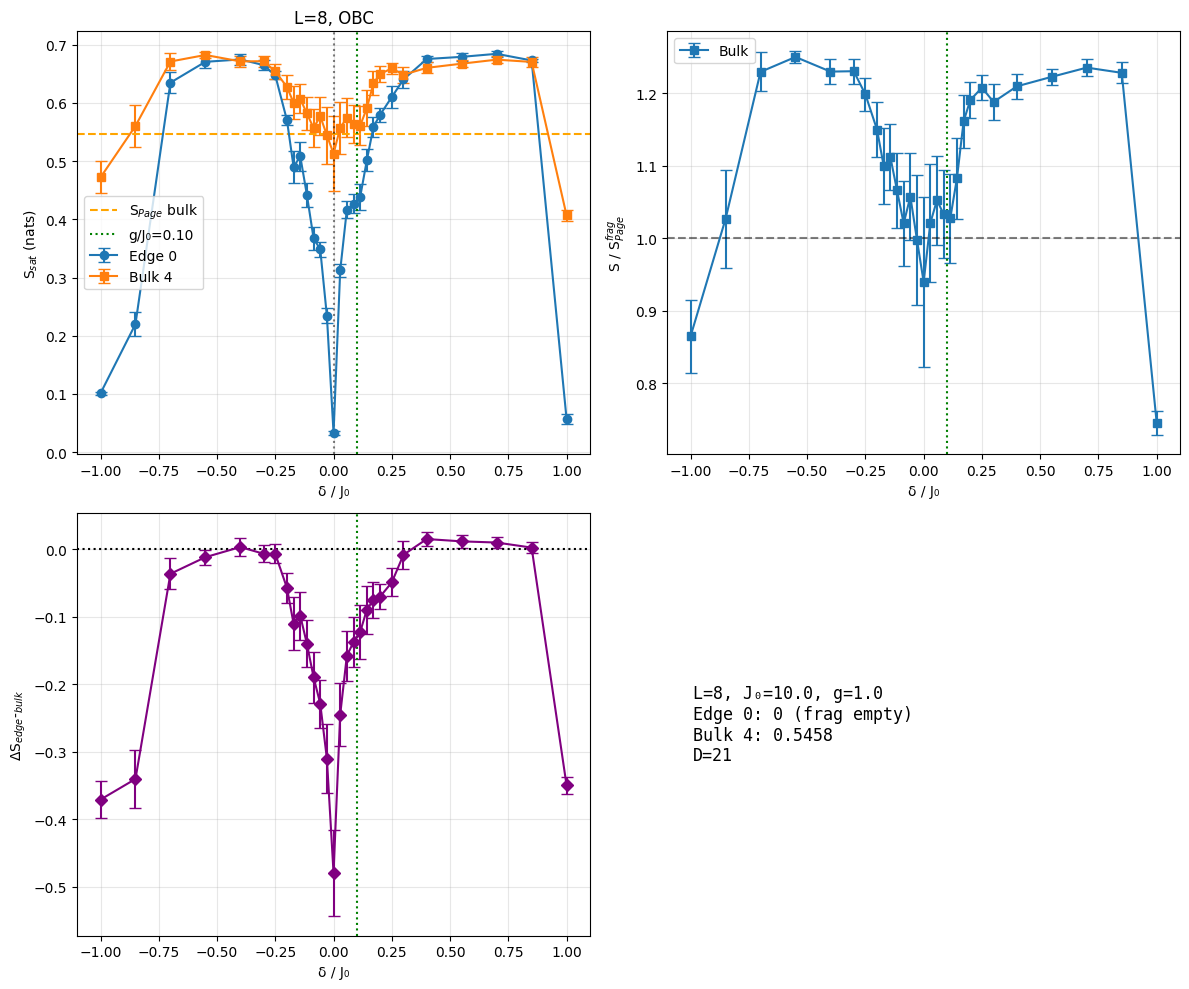

In [ ]:
def save_and_plot_edge_detuning(results, L=None, J0=None, g=None, edge_site=None, bulk_site=None):
    """
    Fixed version: Handles zero/near-zero Page values to avoid div-by-zero.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    %matplotlib inline

    # Auto-detect params
    L = L or results.get('L', 5)
    J0 = J0 or results.get('J0', 10.0)
    g = g or results.get('g', 1.0)
    edge_site = edge_site or results['edge_site']
    bulk_site = bulk_site or results['bulk_site']

    delta = results['delta_over_J0']

    # Safe normalization (avoid div-by-zero)
    S_page_edge = results['S_page_frag_edge']
    S_page_bulk = results['S_page_frag_bulk']
    norm_edge = np.divide(results['S_sat_edge'], S_page_edge,
                         out=np.full_like(results['S_sat_edge'], np.nan),
                         where=S_page_edge != 0)
    norm_edge_std = np.divide(results['S_sat_edge_std'], S_page_edge,
                             out=np.full_like(results['S_sat_edge_std'], np.nan),
                             where=S_page_edge != 0)
    norm_bulk = np.divide(results['S_sat_bulk'], S_page_bulk,
                         out=np.full_like(results['S_sat_bulk'], np.nan),
                         where=S_page_bulk != 0)
    norm_bulk_std = np.divide(results['S_sat_bulk_std'], S_page_bulk,
                             out=np.full_like(results['S_sat_bulk_std'], np.nan),
                             where=S_page_bulk != 0)

    # SAVE (unchanged)
    filename = f'edge_detuning_scan_L{L}_J0{J0}_g{g}.npz'
    np.savez_compressed(filename, **{k: v for k, v in results.items()
                                   if isinstance(v, (np.ndarray, float, int, dict, bool))})
    print(f"Saved to {filename}")

    # PLOTS
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

    # Top-left: Absolute (safe)
    ax1.errorbar(delta, results['S_sat_edge'], results['S_sat_edge_std'],
                 fmt='o-', capsize=4, label=f'Edge {edge_site}')
    ax1.errorbar(delta, results['S_sat_bulk'], results['S_sat_bulk_std'],
                 fmt='s-', capsize=4, label=f'Bulk {bulk_site}')
    if S_page_edge > 0: ax1.axhline(S_page_edge, color='r', ls='--', label='S$_{Page}$ edge')
    if S_page_bulk > 0: ax1.axhline(S_page_bulk, color='orange', ls='--', label='S$_{Page}$ bulk')
    ax1.axvline(0, color='k', ls=':', alpha=0.5)
    ax1.axvline(g/J0, color='g', ls=':', label=f'g/J₀={g/J0:.2f}')
    ax1.set_xlabel('δ / J₀'); ax1.set_ylabel('S$_{sat}$ (nats)')
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title(f'L={L}, OBC')

    # Top-right: Normalized (now NaN where invalid → no plot points)
    mask_edge = ~np.isnan(norm_edge)
    if np.any(mask_edge):
        ax2.errorbar(delta[mask_edge], norm_edge[mask_edge], norm_edge_std[mask_edge],
                     fmt='o-', capsize=4, label='Edge')
    mask_bulk = ~np.isnan(norm_bulk)
    if np.any(mask_bulk):
        ax2.errorbar(delta[mask_bulk], norm_bulk[mask_bulk], norm_bulk_std[mask_bulk],
                     fmt='s-', capsize=4, label='Bulk')
    ax2.axhline(1, color='k', ls='--', alpha=0.5)
    ax2.axvline(g/J0, color='g', ls=':')
    ax2.set_xlabel('δ / J₀'); ax2.set_ylabel('S / S$_{Page}^{frag}$')
    ax2.legend(); ax2.grid(alpha=0.3)

    # Bottom-left: Difference (safe)
    diff = results['S_sat_edge'] - results['S_sat_bulk']
    diff_std = np.sqrt(results['S_sat_edge_std']**2 + results['S_sat_bulk_std']**2)
    ax3.errorbar(delta, diff, diff_std, fmt='D-', capsize=4, color='purple')
    ax3.axhline(0, color='k', ls=':'); ax3.axvline(g/J0, color='g', ls=':')
    ax3.set_xlabel('δ / J₀'); ax3.set_ylabel('ΔS$_{edge}$-$_{bulk}$')
    ax3.grid(alpha=0.3)

    # Bottom-right: Summary (handle zero Page values)
    ax4.axis('off')
    page_edge_str = f"{S_page_edge:.4f}" if S_page_edge > 0 else "0 (frag empty)"
    page_bulk_str = f"{S_page_bulk:.4f}" if S_page_bulk > 0 else "0 (frag empty)"
    summary = f"L={L}, J₀={J0}, g={g}\nEdge {edge_site}: {page_edge_str}\nBulk {bulk_site}: {page_bulk_str}\nD={results['D_largest']}"
    ax4.text(0.05, 0.5, summary, transform=ax4.transAxes, fontsize=12,
             va='center', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f'edge_detuning_L{L}_J0{J0}_g{g}.png', dpi=300, bbox_inches='tight')
    plt.show()

# RECALL with fixed function
save_and_plot_edge_detuning(results, L=L, J0=J0, g=g)
